# Capítulo 6: 6 ImbalancedLearning

Este cuaderno unificado contiene todos los ejemplos y ejercicios del capítulo.
Puede ejecutarse de forma independiente en Google Colab.

**Nota:** Este cuaderno incluye automáticamente todas las funciones compartidas necesarias.

## Funciones Compartidas

Esta sección contiene todas las funciones compartidas necesarias para ejecutar los ejemplos.
Puedes colapsar esta sección haciendo clic en el encabezado.

**Nota:** Estas funciones se cargan automáticamente al inicio del cuaderno.

(shared_functions)=
# Funciones compartidas

Este cuaderno contiene funciones que se reutilizan comúnmente en el libro, para cargar y guardar datos, ajustar y evaluar modelos de predicción, o graficar resultados. 

El cuaderno se puede descargar de GitHub con

```
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.ipynb

```

El cuaderno se puede incluir en otros cuadernos usando

```
%run shared_functions
```



##  General imports

In [ ]:
# General
import os
import pandas as pd
import numpy as np
import math
import sys
import time
import pickle
import json
import datetime
import random

#import sklearn
import sklearn
from sklearn import *

%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid', {'axes.facecolor': '0.9'})

import graphviz
import xgboost

# For imbalanced learning
import imblearn

import warnings
warnings.filterwarnings('ignore')



## Loading and saving data

### read_from_files

Primer uso en [Capítulo 3, Transformación de Características Baseline](Baseline_Feature_Transformation).

In [ ]:
# Load a set of pickle files, put them together in a single DataFrame, and order them by time
# It takes as input the folder DIR_INPUT where the files are stored, and the BEGIN_DATE and END_DATE
def read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE):
    
    files = [os.path.join(DIR_INPUT, f) for f in os.listdir(DIR_INPUT) if f>=BEGIN_DATE+'.pkl' and f<=END_DATE+'.pkl']

    frames = []
    for f in files:
        df = pd.read_pickle(f)
        frames.append(df)
        del df
    df_final = pd.concat(frames)
    
    df_final=df_final.sort_values('TRANSACTION_ID')
    df_final.reset_index(drop=True,inplace=True)
    #  Note: -1 are missing values for real world data 
    df_final=df_final.replace([-1],0)
    
    return df_final


### save_object


In [ ]:
#Save oject as pickle file
def save_object(obj, filename):
    with open(filename, 'wb') as output:
        pickle.dump(obj, output, pickle.HIGHEST_PROTOCOL)


## Data preprocessing

### scaleData

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def scaleData(train,test,features):
    scaler = sklearn.preprocessing.StandardScaler()
    scaler.fit(train[features])
    train[features]=scaler.transform(train[features])
    test[features]=scaler.transform(test[features])
    
    return (train,test)

## Train/Test splitting strategies

### get_train_test_set

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Ratio de muestreo agregado en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
def get_train_test_set(transactions_df,
                       start_date_training,
                       delta_train=7,delta_delay=7,delta_test=7,
                       sampling_ratio=1.0,
                       random_state=0):
    
    # Get the training set data
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]
    
    # Get the test set data
    test_df = []
    
    # Note: Cards known to be compromised after the delay period are removed from the test set
    # That is, for each test day, all frauds known at (test_day-delay_period) are removed
    
    # First, get known defrauded customers from the training set
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)
    
    # Get the relative starting day of training set (easier than TX_DATETIME to collect test data)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()
    
    # Then, for each day of the test set
    for day in range(delta_test):
    
        # Get test data for that day
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]
        
        # Compromised cards from that test day, minus the delay period, are added to the pool of known defrauded customers
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]
        
        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)
        
        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]
        
        test_df.append(test_df_day)
        
    test_df = pd.concat(test_df)
    
    # If subsample
    if sampling_ratio<1:
        
        train_df_frauds=train_df[train_df.TX_FRAUD==1].sample(frac=sampling_ratio, random_state=random_state)
        train_df_genuine=train_df[train_df.TX_FRAUD==0].sample(frac=sampling_ratio, random_state=random_state)
        train_df=pd.concat([train_df_frauds,train_df_genuine])
        
    # Sort data sets by ascending order of transaction ID
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')
    
    return (train_df, test_df)
                               


In [ ]:
def get_train_delay_test_set(transactions_df,
                             start_date_training,
                             delta_train=7,delta_delay=7,delta_test=7,
                             sampling_ratio=1.0,
                             random_state=0):
    
    # Get the training set data
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]
    
    # Get the delay set data
    delay_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training+datetime.timedelta(days=delta_train)) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train)+
                                                                               +datetime.timedelta(days=delta_delay))]
    
    # Get the test set data
    test_df = []
    
    # Note: Cards known to be compromised after the delay period are removed from the test set
    # That is, for each test day, all frauds known at (test_day-delay_period) are removed
    
    # First, get known defrauded customers from the training set
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)
    
    # Get the relative starting day of training set (easier than TX_DATETIME to collect test data)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()
    
    # Then, for each day of the test set
    for day in range(delta_test):
    
        # Get test data for that day
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]
        
        # Compromised cards from that test day, minus the delay period, are added to the pool of known defrauded customers
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]
        
        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)
        
        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]
        
        test_df.append(test_df_day)
        
    test_df = pd.concat(test_df)
    
    # If subsample
    if sampling_ratio<1:
        
        train_df_frauds=train_df[train_df.TX_FRAUD==1].sample(frac=sampling_ratio, random_state=random_state)
        train_df_genuine=train_df[train_df.TX_FRAUD==0].sample(frac=sampling_ratio, random_state=random_state)
        train_df=pd.concat([train_df_frauds,train_df_genuine])
        
    # Sort data sets by ascending order of transaction ID
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')
    
    return (train_df, delay_df, test_df)

### prequentialSplit

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
def prequentialSplit(transactions_df,
                     start_date_training, 
                     n_folds=4, 
                     delta_train=7,
                     delta_delay=7,
                     delta_assessment=7):
    
    prequential_split_indices=[]
        
    # For each fold
    for fold in range(n_folds):
        
        # Shift back start date for training by the fold index times the assessment period (delta_assessment)
        # (See Fig. 5)
        start_date_training_fold = start_date_training-datetime.timedelta(days=fold*delta_assessment)
        
        # Get the training and test (assessment) sets
        (train_df, test_df)=get_train_test_set(transactions_df,
                                               start_date_training=start_date_training_fold,
                                               delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_assessment)
    
        # Get the indices from the two sets, and add them to the list of prequential splits
        indices_train=list(train_df.index)
        indices_test=list(test_df.index)
        
        prequential_split_indices.append((indices_train,indices_test))
    
    return prequential_split_indices


## Predictions functions

### fit_model_and_get_predictions

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def fit_model_and_get_predictions(classifier, train_df, test_df, 
                                  input_features, output_feature="TX_FRAUD",scale=True):

    # By default, scales input data
    if scale:
        (train_df, test_df)=scaleData(train_df,test_df,input_features)
    
    # We first train the classifier using the `fit` method, and pass as arguments the input and output features
    start_time=time.time()
    classifier.fit(train_df[input_features], train_df[output_feature])
    training_execution_time=time.time()-start_time

    # We then get the predictions on the training and test data using the `predict_proba` method
    # The predictions are returned as a numpy array, that provides the probability of fraud for each transaction 
    start_time=time.time()
    predictions_test=classifier.predict_proba(test_df[input_features])[:,1]
    prediction_execution_time=time.time()-start_time
    
    predictions_train=classifier.predict_proba(train_df[input_features])[:,1]

    # The result is returned as a dictionary containing the fitted models, 
    # and the predictions on the training and test sets
    model_and_predictions_dictionary = {'classifier': classifier,
                                        'predictions_test': predictions_test,
                                        'predictions_train': predictions_train,
                                        'training_execution_time': training_execution_time,
                                        'prediction_execution_time': prediction_execution_time
                                       }
    
    return model_and_predictions_dictionary

## Performance assessment

### card_precision_top_k_day

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Detallado en [Capítulo 4, Métricas de Precisión Top-K](Precision_Top_K_Metrics).

In [ ]:
def card_precision_top_k_day(df_day,top_k):
    
    # This takes the max of the predictions AND the max of label TX_FRAUD for each CUSTOMER_ID, 
    # and sorts by decreasing order of fraudulent prediction
    df_day = df_day.groupby('CUSTOMER_ID').max().sort_values(by="predictions", ascending=False).reset_index(drop=False)
            
    # Get the top k most suspicious cards
    df_day_top_k=df_day.head(top_k)
    list_detected_compromised_cards=list(df_day_top_k[df_day_top_k.TX_FRAUD==1].CUSTOMER_ID)
    
    # Compute precision top k
    card_precision_top_k = len(list_detected_compromised_cards) / top_k
    
    return list_detected_compromised_cards, card_precision_top_k



### card_precision_top_k

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Detallado en [Capítulo 4, Métricas de Precisión Top-K](Precision_Top_K_Metrics).

In [ ]:
def card_precision_top_k(predictions_df, top_k, remove_detected_compromised_cards=True):

    # Sort days by increasing order
    list_days=list(predictions_df['TX_TIME_DAYS'].unique())
    list_days.sort()
    
    # At first, the list of detected compromised cards is empty
    list_detected_compromised_cards = []
    
    card_precision_top_k_per_day_list = []
    nb_compromised_cards_per_day = []
    
    # For each day, compute precision top k
    for day in list_days:
        
        df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
        df_day = df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]
        
        # Let us remove detected compromised cards from the set of daily transactions
        df_day = df_day[df_day.CUSTOMER_ID.isin(list_detected_compromised_cards)==False]
        
        nb_compromised_cards_per_day.append(len(df_day[df_day.TX_FRAUD==1].CUSTOMER_ID.unique()))
        
        detected_compromised_cards, card_precision_top_k = card_precision_top_k_day(df_day,top_k)
        
        card_precision_top_k_per_day_list.append(card_precision_top_k)
        
        # Let us update the list of detected compromised cards
        if remove_detected_compromised_cards:
            list_detected_compromised_cards.extend(detected_compromised_cards)
        
    # Compute the mean
    mean_card_precision_top_k = np.array(card_precision_top_k_per_day_list).mean()
    
    # Returns precision top k per day as a list, and resulting mean
    return nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k



### card_precision_top_k_custom

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
def card_precision_top_k_custom(y_true, y_pred, top_k, transactions_df):
    
    # Let us create a predictions_df DataFrame, that contains all transactions matching the indices of the current fold
    # (indices of the y_true vector)
    predictions_df=transactions_df.iloc[y_true.index.values].copy()
    predictions_df['predictions']=y_pred
    
    # Compute the CP@k using the function implemented in Chapter 4, Section 4.2
    nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k=\
        card_precision_top_k(predictions_df, top_k)
    
    # Return the mean_card_precision_top_k
    return mean_card_precision_top_k


### performance_assessment

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                           prediction_feature='predictions', top_k_list=[100],
                           rounded=True):
    
    AUC_ROC = metrics.roc_auc_score(predictions_df[output_feature], predictions_df[prediction_feature])
    AP = metrics.average_precision_score(predictions_df[output_feature], predictions_df[prediction_feature])
    
    performances = pd.DataFrame([[AUC_ROC, AP]], 
                           columns=['AUC ROC','Average precision'])
    
    for top_k in top_k_list:
    
        _, _, mean_card_precision_top_k = card_precision_top_k(predictions_df, top_k)
        performances['Card Precision@'+str(top_k)]=mean_card_precision_top_k
        
    if rounded:
        performances = performances.round(3)
    
    return performances


### performance_assessment_model_collection

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def performance_assessment_model_collection(fitted_models_and_predictions_dictionary, 
                                            transactions_df, 
                                            type_set='test',
                                            top_k_list=[100]):

    performances=pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        predictions_df=transactions_df
            
        predictions_df['predictions']=model_and_predictions['predictions_'+type_set]
        
        performances_model=performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                                                   prediction_feature='predictions', top_k_list=top_k_list)
        performances_model.index=[classifier_name]
        
        performances=performances.append(performances_model)
        
    return performances

### execution_times_model_collection

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def execution_times_model_collection(fitted_models_and_predictions_dictionary):

    execution_times=pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        execution_times_model=pd.DataFrame() 
        execution_times_model['Training execution time']=[model_and_predictions['training_execution_time']]
        execution_times_model['Prediction execution time']=[model_and_predictions['prediction_execution_time']]
        execution_times_model.index=[classifier_name]
        
        execution_times=execution_times.append(execution_times_model)
        
    return execution_times

### get_class_from_fraud_probability

Primer uso en [Capítulo 4, Métricas Basadas en Umbral](Threshold_Based_Metrics).

In [ ]:
# Getting classes from a vector of fraud probabilities and a threshold
def get_class_from_fraud_probability(fraud_probabilities, threshold=0.5):
    
    predicted_classes = [0 if fraud_probability<threshold else 1 
                         for fraud_probability in fraud_probabilities]

    return predicted_classes


### threshold_based_metrics

Primer uso en [Capítulo 4, Métricas Basadas en Umbral](Threshold_Based_Metrics).

In [ ]:
def threshold_based_metrics(fraud_probabilities, true_label, thresholds_list):
    
    results = []
    
    for threshold in thresholds_list:
    
        predicted_classes = get_class_from_fraud_probability(fraud_probabilities, threshold=threshold)
    
        (TN, FP, FN, TP) = metrics.confusion_matrix(true_label, predicted_classes).ravel()
    
        MME = (FP+FN)/(TN+FP+FN+TP)
    
        TPR = TP/(TP+FN)
        TNR = TN/(TN+FP)
    
        FPR = FP/(TN+FP)
        FNR = FN/(TP+FN)
        
        BER = 1/2*(FPR+FNR)
        
        Gmean = np.sqrt(TPR*TNR)
    
        precision = 1 # 1 if TP+FP=0
        FDR = 1 # 1 if TP+FP=0
        
        if TP+FP>0:
            precision = TP/(TP+FP)
            FDR=FP/(TP+FP)
        
        NPV = 1 # 1 if TN+FN=0
        FOR = 1 # 1 if TN+FN=0
        
        if TN+FN>0:
            NPV = TN/(TN+FN)
            FOR = FN/(TN+FN)
            
        
        F1_score = 2*(precision*TPR)/(precision+TPR)
    
        results.append([threshold, MME, TPR, TNR, FPR, FNR, BER, Gmean, precision, NPV, FDR, FOR, F1_score])
        
    results_df = pd.DataFrame(results,columns=['Threshold' ,'MME', 'TPR', 'TNR', 'FPR', 'FNR', 'BER', 'G-mean', 'Precision', 'NPV', 'FDR', 'FOR', 'F1 Score'])
    
    return results_df

### get_summary_performances

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
def get_summary_performances(performances_df, parameter_column_name="Parameters summary"):

    metrics = ['AUC ROC','Average precision','Card Precision@100']
    performances_results=pd.DataFrame(columns=metrics)
    
    performances_df.reset_index(drop=True,inplace=True)

    best_estimated_parameters = []
    validation_performance = []
    test_performance = []
    
    for metric in metrics:
    
        index_best_validation_performance = performances_df.index[np.argmax(performances_df[metric+' Validation'].values)]
    
        best_estimated_parameters.append(performances_df[parameter_column_name].iloc[index_best_validation_performance])
        
        validation_performance.append(
                str(round(performances_df[metric+' Validation'].iloc[index_best_validation_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Validation'+' Std'].iloc[index_best_validation_performance],2))
        )
        
        test_performance.append(
                str(round(performances_df[metric+' Test'].iloc[index_best_validation_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Test'+' Std'].iloc[index_best_validation_performance],2))
        )
    
    performances_results.loc["Best estimated parameters"]=best_estimated_parameters
    performances_results.loc["Validation performance"]=validation_performance
    performances_results.loc["Test performance"]=test_performance

    optimal_test_performance = []
    optimal_parameters = []

    for metric in ['AUC ROC Test','Average precision Test','Card Precision@100 Test']:
    
        index_optimal_test_performance = performances_df.index[np.argmax(performances_df[metric].values)]
    
        optimal_parameters.append(performances_df[parameter_column_name].iloc[index_optimal_test_performance])
    
        optimal_test_performance.append(
                str(round(performances_df[metric].iloc[index_optimal_test_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Std'].iloc[index_optimal_test_performance],2))
        )

    performances_results.loc["Optimal parameter(s)"]=optimal_parameters
    performances_results.loc["Optimal test performance"]=optimal_test_performance
    
    return performances_results

### model_selection_performances

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
def model_selection_performances(performances_df_dictionary,
                                 performance_metric='AUC ROC'):
    
    # Note: max_depth of 50 is similar to None
    default_parameters_dictionary={
        "Decision Tree": 50,
        "Logstic Regression": 1,
        "Random Forest": "100/50",
        "XGBoost": "100/0.1/2"
    }
    
    mean_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    std_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    # For each model class
    for model_class, performances_df in performances_df_dictionary.items():
        
        # Get the performances for the default paramaters
        default_performances=performances_df[performances_df['Parameters summary']==default_parameters_dictionary[model_class]]
        default_performances=default_performances.round(decimals=3)
        
        mean_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test"].values[0])
        std_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test Std"].values[0])
        
        # Get the performances for the best estimated parameters
        performances_summary=get_summary_performances(performances_df, parameter_column_name="Parameters summary")
        mean_std_performances=performances_summary.loc[["Test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[1]))
        
        # Get the performances for the boptimal parameters
        mean_std_performances=performances_summary.loc[["Optimal test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[1]))
        
    # Return the mean performances and their standard deviations    
    return (mean_performances_dictionary,std_performances_dictionary)

In [ ]:
def model_selection_performances(performances_df_dictionary,
                                 performance_metric='AUC ROC',
                                 model_classes=['Decision Tree', 
                                                'Logistic Regression', 
                                                'Random Forest', 
                                                'XGBoost'],
                                 default_parameters_dictionary={
                                                "Decision Tree": 50,
                                                "Logistic Regression": 1,
                                                "Random Forest": "100/50",
                                                "XGBoost": "100/0.1/3"
                                            }):
    
    mean_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    std_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    # For each model class
    for model_class in model_classes:
        
        performances_df=performances_df_dictionary[model_class]
        
        # Get the performances for the default paramaters
        default_performances=performances_df[performances_df['Parameters summary']==default_parameters_dictionary[model_class]]
        default_performances=default_performances.round(decimals=3)
        
        mean_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test"].values[0])
        std_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test Std"].values[0])
        
        # Get the performances for the best estimated parameters
        performances_summary=get_summary_performances(performances_df, parameter_column_name="Parameters summary")
        mean_std_performances=performances_summary.loc[["Test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[1]))
        
        # Get the performances for the boptimal parameters
        mean_std_performances=performances_summary.loc[["Optimal test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[1]))
        
    # Return the mean performances and their standard deviations    
    return (mean_performances_dictionary,std_performances_dictionary)

## Model selection

### prequential_grid_search

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
def prequential_grid_search(transactions_df, 
                            classifier, 
                            input_features, output_feature, 
                            parameters, scoring, 
                            start_date_training, 
                            n_folds=4,
                            expe_type='Test',
                            delta_train=7, 
                            delta_delay=7, 
                            delta_assessment=7,
                            performance_metrics_list_grid=['roc_auc'],
                            performance_metrics_list=['AUC ROC'],
                            n_jobs=-1):
    
    estimators = [('scaler', sklearn.preprocessing.StandardScaler()), ('clf', classifier)]
    pipe = sklearn.pipeline.Pipeline(estimators)
    
    prequential_split_indices=prequentialSplit(transactions_df,
                                               start_date_training=start_date_training, 
                                               n_folds=n_folds, 
                                               delta_train=delta_train, 
                                               delta_delay=delta_delay, 
                                               delta_assessment=delta_assessment)
    
    grid_search = sklearn.model_selection.GridSearchCV(pipe, parameters, scoring=scoring, cv=prequential_split_indices, refit=False, n_jobs=n_jobs)
    
    X=transactions_df[input_features]
    y=transactions_df[output_feature]

    grid_search.fit(X, y)
    
    performances_df=pd.DataFrame()
    
    for i in range(len(performance_metrics_list_grid)):
        performances_df[performance_metrics_list[i]+' '+expe_type]=grid_search.cv_results_['mean_test_'+performance_metrics_list_grid[i]]
        performances_df[performance_metrics_list[i]+' '+expe_type+' Std']=grid_search.cv_results_['std_test_'+performance_metrics_list_grid[i]]

    performances_df['Parameters']=grid_search.cv_results_['params']
    performances_df['Execution time']=grid_search.cv_results_['mean_fit_time']
    
    return performances_df



### model_selection_wrapper

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
def model_selection_wrapper(transactions_df, 
                            classifier, 
                            input_features, output_feature,
                            parameters, 
                            scoring, 
                            start_date_training_for_valid,
                            start_date_training_for_test,
                            n_folds=4,
                            delta_train=7, 
                            delta_delay=7, 
                            delta_assessment=7,
                            performance_metrics_list_grid=['roc_auc'],
                            performance_metrics_list=['AUC ROC'],
                            n_jobs=-1):

    # Get performances on the validation set using prequential validation
    performances_df_validation=prequential_grid_search(transactions_df, classifier, 
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_valid,
                            n_folds=n_folds,
                            expe_type='Validation',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            n_jobs=n_jobs)
    
    # Get performances on the test set using prequential validation
    performances_df_test=prequential_grid_search(transactions_df, classifier, 
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_test,
                            n_folds=n_folds,
                            expe_type='Test',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            n_jobs=n_jobs)
    
    # Bind the two resulting DataFrames
    performances_df_validation.drop(columns=['Parameters','Execution time'], inplace=True)
    performances_df=pd.concat([performances_df_test,performances_df_validation],axis=1)

    # And return as a single DataFrame
    return performances_df


### kfold_cv_with_classifier

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [ ]:
def kfold_cv_with_classifier(classifier,
                             X,
                             y,
                             n_splits=5,
                             strategy_name="Basline classifier"):
    
    cv = sklearn.model_selection.StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    
    cv_results_=sklearn.model_selection.cross_validate(classifier,X,y,cv=cv,
                                                       scoring=['roc_auc',
                                                                'average_precision',
                                                                'balanced_accuracy'],
                                                       return_estimator=True)
    
    results=round(pd.DataFrame(cv_results_),3)
    results_mean=list(results.mean().values)
    results_std=list(results.std().values)
    results_df=pd.DataFrame([[str(round(results_mean[i],3))+'+/-'+
                              str(round(results_std[i],3)) for i in range(len(results))]],
                            columns=['Fit time (s)','Score time (s)',
                                     'AUC ROC','Average Precision','Balanced accuracy'])
    results_df.rename(index={0:strategy_name}, inplace=True)
    
    classifier_0=cv_results_['estimator'][0]
    
    (train_index, test_index) = next(cv.split(X, y))
    train_df=pd.DataFrame({'X1':X[train_index,0],'X2':X[train_index,1], 'Y':y[train_index]})
    test_df=pd.DataFrame({'X1':X[test_index,0],'X2':X[test_index,1], 'Y':y[test_index]})
    
    return (results_df, classifier_0, train_df, test_df)

## Plotting

### get_tx_stats

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
# Compute the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

def get_tx_stats(transactions_df, start_date_df="2018-04-01"):
    
    #Number of transactions per day
    nb_tx_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
    #Number of fraudulent transactions per day
    nb_fraudulent_transactions_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
    #Number of fraudulent cards per day
    nb_compromised_card_per_day=transactions_df[transactions_df['TX_FRAUD']==1].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()
    
    tx_stats=pd.DataFrame({"nb_tx_per_day":nb_tx_per_day,
                           "nb_fraudulent_transactions_per_day":nb_fraudulent_transactions_per_day,
                           "nb_compromised_cards_per_day":nb_compromised_card_per_day})

    tx_stats=tx_stats.reset_index()
    
    start_date = datetime.datetime.strptime(start_date_df, "%Y-%m-%d")
    tx_date=start_date+tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)
    
    tx_stats['tx_date']=tx_date
    
    return tx_stats



### get_template_tx_stats

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
# Plot the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

def get_template_tx_stats(ax ,fs,
                          start_date_training,
                          title='',
                          delta_train=7,
                          delta_delay=7,
                          delta_test=7,
                          ylim=300):
    
    ax.set_title(title, fontsize=fs*1.5)
    ax.set_ylim([0, ylim])
    
    ax.set_xlabel('Date', fontsize=fs)
    ax.set_ylabel('Number', fontsize=fs)
    
    plt.yticks(fontsize=fs*0.7) 
    plt.xticks(fontsize=fs*0.7)    

    ax.axvline(start_date_training+datetime.timedelta(days=delta_train), 0,ylim, color="black")
    ax.axvline(start_date_training+datetime.timedelta(days=delta_train+delta_delay), 0, ylim, color="black")
    
    ax.text(start_date_training+datetime.timedelta(days=2), ylim-20,'Training period', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+2), ylim-20,'Delay period', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+delta_delay+2), ylim-20,'Test period', fontsize=fs)


### get_template_roc_curve

Primer uso en [Capítulo 4, Métricas Libres de Umbral](Threshold_Free_Metrics).

In [ ]:
def get_template_roc_curve(ax, title,fs,random=True):
    
    ax.set_title(title, fontsize=fs)
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    
    ax.set_xlabel('False Positive Rate', fontsize=fs)
    ax.set_ylabel('True Positive Rate', fontsize=fs)
    
    if random:
        ax.plot([0, 1], [0, 1],'r--',label="AUC ROC Random = 0.5")



### get_template_pr_curve

Primer uso en [Capítulo 4, Métricas Libres de Umbral](Threshold_Free_Metrics).

In [ ]:
def get_template_pr_curve(ax, title,fs, baseline=0.5):
    ax.set_title(title, fontsize=fs)
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    
    ax.set_xlabel('Recall (True Positive Rate)', fontsize=fs)
    ax.set_ylabel('Precision', fontsize=fs)
    
    ax.plot([0, 1], [baseline, baseline],'r--',label='AP Random = {0:0.3f}'.format(baseline))


### get_performance_plot

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
# Get the performance plot for a single performance metric
def get_performance_plot(performances_df, 
                         ax, 
                         performance_metric, 
                         expe_type_list=['Test','Train'], 
                         expe_type_color_list=['#008000','#2F4D7E'],
                         parameter_name="Tree maximum depth",
                         summary_performances=None):
    
    # expe_type_list is the list of type of experiments, typically containing 'Test', 'Train', or 'Valid'
    # For all types of experiments
    for i in range(len(expe_type_list)):
    
        # Column in performances_df for which to retrieve the data 
        performance_metric_expe_type=performance_metric+' '+expe_type_list[i]
    
        # Plot data on graph
        ax.plot(performances_df['Parameters summary'], performances_df[performance_metric_expe_type], 
                color=expe_type_color_list[i], label = expe_type_list[i])
        
        # If performances_df contains confidence intervals, add them to the graph
        if performance_metric_expe_type+' Std' in performances_df.columns:
        
            conf_min = performances_df[performance_metric_expe_type]\
                        -2*performances_df[performance_metric_expe_type+' Std']
            conf_max = performances_df[performance_metric_expe_type]\
                        +2*performances_df[performance_metric_expe_type+' Std']
    
            ax.fill_between(performances_df['Parameters summary'], conf_min, conf_max, color=expe_type_color_list[i], alpha=.1)

    # If summary_performances table is present, adds vertical dashed bar for best estimated parameter 
    if summary_performances is not None:
        best_estimated_parameter=summary_performances[performance_metric][['Best estimated parameters']].values[0]
        best_estimated_performance=float(summary_performances[performance_metric][['Validation performance']].values[0].split("+/-")[0])
        ymin, ymax = ax.get_ylim()
        ax.vlines(best_estimated_parameter, ymin, best_estimated_performance,
                  linestyles="dashed")
    
    # Set title, and x and y axes labels
    ax.set_title(performance_metric+'\n', fontsize=14)
    ax.set(xlabel = parameter_name, ylabel=performance_metric)
    

### get_performances_plots

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
# Get the performance plots for a set of performance metric
def get_performances_plots(performances_df, 
                           performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                           expe_type_list=['Test','Train'], expe_type_color_list=['#008000','#2F4D7E'],
                           parameter_name="Tree maximum depth",
                           summary_performances=None):
    
    # Create as many graphs as there are performance metrics to display
    n_performance_metrics = len(performance_metrics_list)
    fig, ax = plt.subplots(1, n_performance_metrics, figsize=(5*n_performance_metrics,4))
    
    # Plot performance metric for each metric in performance_metrics_list
    for i in range(n_performance_metrics):
    
        get_performance_plot(performances_df, ax[i], performance_metric=performance_metrics_list[i], 
                             expe_type_list=expe_type_list, 
                             expe_type_color_list=expe_type_color_list,
                             parameter_name=parameter_name,
                             summary_performances=summary_performances)
    
    ax[n_performance_metrics-1].legend(loc='upper left', 
                                       labels=expe_type_list, 
                                       bbox_to_anchor=(1.05, 1),
                                       title="Type set")

    plt.subplots_adjust(wspace=0.5, 
                        hspace=0.8)

### get_execution_times_plot

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
# Get the performance plot for a single performance metric
def get_execution_times_plot(performances_df,
                             title="",
                             parameter_name="Tree maximum depth"):
    
    fig, ax = plt.subplots(1,1, figsize=(5,4))
    
    # Plot data on graph
    ax.plot(performances_df['Parameters summary'], performances_df["Execution time"], 
            color="black")
        
    # Set title, and x and y axes labels
    ax.set_title(title, fontsize=14)
    ax.set(xlabel = parameter_name, ylabel="Execution time (seconds)")

### get_model_selection_performances_plots

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
# Get the performance plot for a single performance metric
def get_model_selection_performance_plot(performances_df_dictionary, 
                                         ax, 
                                         performance_metric,
                                         ylim=[0,1],
                                         model_classes=['Decision Tree', 
                                                        'Logistic Regression', 
                                                        'Random Forest', 
                                                        'XGBoost']):
    
    
    (mean_performances_dictionary,std_performances_dictionary) = \
        model_selection_performances(performances_df_dictionary=performances_df_dictionary,
                                     performance_metric=performance_metric)
    
    
    # width of the bars
    barWidth = 0.3
    # The x position of bars
    r1 = np.arange(len(model_classes))
    r2 = r1+barWidth
    r3 = r1+2*barWidth
    
    # Create Default parameters bars (Orange)
    ax.bar(r1, mean_performances_dictionary['Default parameters'], 
           width = barWidth, color = '#CA8035', edgecolor = 'black', 
           yerr=std_performances_dictionary['Default parameters'], capsize=7, label='Default parameters')
 
    # Create Best validation parameters bars (Red)
    ax.bar(r2, mean_performances_dictionary['Best validation parameters'], 
           width = barWidth, color = '#008000', edgecolor = 'black', 
           yerr=std_performances_dictionary['Best validation parameters'], capsize=7, label='Best validation parameters')

    # Create Optimal parameters bars (Green)
    ax.bar(r3, mean_performances_dictionary['Optimal parameters'], 
           width = barWidth, color = '#2F4D7E', edgecolor = 'black', 
           yerr=std_performances_dictionary['Optimal parameters'], capsize=7, label='Optimal parameters')
 

    # Set title, and x and y axes labels
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_xticks(r2+barWidth/2)
    ax.set_xticklabels(model_classes, rotation = 45, ha="right", fontsize=12)
    ax.set_title(performance_metric+'\n', fontsize=18)
    ax.set_xlabel("Model class", fontsize=16)
    ax.set_ylabel(performance_metric, fontsize=15)

### get_model_selection_performances_plots

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
def get_model_selection_performances_plots(performances_df_dictionary, 
                                           performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'],
                                           ylim_list=[[0.6,0.9],[0.2,0.8],[0.2,0.35]],
                                           model_classes=['Decision Tree', 
                                                          'Logistic Regression', 
                                                          'Random Forest', 
                                                          'XGBoost']):
    
    # Create as many graphs as there are performance metrics to display
    n_performance_metrics = len(performance_metrics_list)
    fig, ax = plt.subplots(1, n_performance_metrics, figsize=(5*n_performance_metrics,4))
    
    parameter_types=['Default parameters','Best validation parameters','Optimal parameters']
    
    # Plot performance metric for each metric in performance_metrics_list
    for i in range(n_performance_metrics):
    
        get_model_selection_performance_plot(performances_df_dictionary, 
                                             ax[i], 
                                             performance_metrics_list[i],
                                             ylim=ylim_list[i],
                                             model_classes=model_classes
                                            )
    
    ax[n_performance_metrics-1].legend(loc='upper left', 
                                       labels=parameter_types, 
                                       bbox_to_anchor=(1.05, 1),
                                       title="Parameter type",
                                       prop={'size': 12},
                                       title_fontsize=12)

    plt.subplots_adjust(wspace=0.5, 
                        hspace=0.8)

### plot_decision_boundary_classifier

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [ ]:
def plot_decision_boundary_classifier(ax, 
                                      classifier,
                                      train_df,
                                      input_features=['X1','X2'],
                                      output_feature='Y',
                                      title="",
                                      fs=14,
                                      plot_training_data=True):

    plot_colors = ["tab:blue","tab:orange"]

    x1_min, x1_max = train_df[input_features[0]].min() - 1, train_df[input_features[0]].max() + 1
    x2_min, x2_max = train_df[input_features[1]].min() - 1, train_df[input_features[1]].max() + 1
    
    plot_step=0.1
    xx, yy = np.meshgrid(np.arange(x1_min, x1_max, plot_step),
                         np.arange(x2_min, x2_max, plot_step))

    Z = classifier.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu_r,alpha=0.3)

    if plot_training_data:
        # Plot the training points
        groups = train_df.groupby(output_feature)
        for name, group in groups:
            ax.scatter(group[input_features[0]], group[input_features[1]], edgecolors='black', label=name)
        
    ax.set_title(title, fontsize=fs)
    ax.set_xlabel(input_features[0], fontsize=fs)
    ax.set_ylabel(input_features[1], fontsize=fs)

### plot_decision_boundary

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [ ]:
def plot_decision_boundary(classifier_0,
                           train_df, 
                           test_df):
    
    fig_decision_boundary, ax = plt.subplots(1, 3, figsize=(5*3,5))

    plot_decision_boundary_classifier(ax[0], classifier_0,
                                  train_df,
                                  title="Decision surface of the decision tree\n With training data",
                                  plot_training_data=True)

    plot_decision_boundary_classifier(ax[1], classifier_0,
                                  train_df,
                                  title="Decision surface of the decision tree\n",
                                  plot_training_data=False)


    plot_decision_boundary_classifier(ax[2], classifier_0,
                                  test_df,
                                  title="Decision surface of the decision tree\n With test data",
                                  plot_training_data=True)

    ax[-1].legend(loc='upper left', 
              #labels=[0,1], 
              bbox_to_anchor=(1.05, 1),
              title="Class")

    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu_r, norm=plt.Normalize(vmin=0, vmax=1))
    cax = fig_decision_boundary.add_axes([0.93, 0.15, 0.02, 0.5])
    fig_decision_boundary.colorbar(sm, cax=cax, alpha=0.3, boundaries=np.linspace(0, 1, 11))
    
    return fig_decision_boundary

## Deep Learning functions



In [ ]:
import torch
import torch.nn.functional as F

### seed_everything

Primer uso en [Capítulo 7, Red neuronal de propagación hacia adelante](FeedForwardNeuralNetworks).

In [ ]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

### Utilidades para gestión de datos, entrenamiento y evaluación

Primer uso en [Capítulo 7, Red neuronal de propagación hacia adelante](FeedForwardNeuralNetworks).

In [ ]:
class FraudDataset(torch.utils.data.Dataset):
    
    def __init__(self, x, y):
        'Initialization'
        self.x = x
        self.y = y

    def __len__(self):
        'Denotes the total number of samples'
        return len(self.x)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample index
        if self.y is not None:
            return self.x[index], self.y[index]
        else:
            return self.x[index]

def prepare_generators(training_set,valid_set,batch_size=64):
    
    train_loader_params = {'batch_size': batch_size,
              'shuffle': True,
              'num_workers': 0}
    valid_loader_params = {'batch_size': batch_size,
              'num_workers': 0}
    
    training_generator = torch.utils.data.DataLoader(training_set, **train_loader_params)
    valid_generator = torch.utils.data.DataLoader(valid_set, **valid_loader_params)
    
    return training_generator,valid_generator

def evaluate_model(model,generator,criterion):
    model.eval()
    batch_losses = []
    for x_batch, y_batch in generator:
        # Forward pass
        y_pred = model(x_batch)
        # Compute Loss
        loss = criterion(y_pred.squeeze(), y_batch)
        batch_losses.append(loss.item())
    mean_loss = np.mean(batch_losses)    
    return mean_loss

class EarlyStopping:
    
    def __init__(self, patience=2, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = np.Inf
    
    def continue_training(self,current_score):
        if self.best_score > current_score:
            self.best_score = current_score
            self.counter = 0
            if self.verbose:
                print("New best score:", current_score)
        else:
            self.counter+=1
            if self.verbose:
                print(self.counter, " iterations since best score.")
                
        return self.counter <= self.patience  
    
def training_loop(model,training_generator,valid_generator,optimizer,criterion,max_epochs=100,apply_early_stopping=True,patience=2,verbose=False):
    #Setting the model in training mode
    model.train()

    if apply_early_stopping:
        early_stopping = EarlyStopping(verbose=verbose,patience=patience)
    
    all_train_losses = []
    all_valid_losses = []
    
    #Training loop
    start_time=time.time()
    for epoch in range(max_epochs):
        model.train()
        train_loss=[]
        for x_batch, y_batch in training_generator:
            optimizer.zero_grad()
            # Forward pass
            y_pred = model(x_batch)
            # Compute Loss
            loss = criterion(y_pred.squeeze(), y_batch)
            # Backward pass
            loss.backward()
            optimizer.step()   
            train_loss.append(loss.item())
        
        #showing last training loss after each epoch
        all_train_losses.append(np.mean(train_loss))
        if verbose:
            print('')
            print('Epoch {}: train loss: {}'.format(epoch, np.mean(train_loss)))
        #evaluating the model on the test set after each epoch    
        valid_loss = evaluate_model(model,valid_generator,criterion)
        all_valid_losses.append(valid_loss)
        if verbose:
            print('valid loss: {}'.format(valid_loss))
        if apply_early_stopping:
            if not early_stopping.continue_training(valid_loss):
                if verbose:
                    print("Early stopping")
                break
        
    training_execution_time=time.time()-start_time
    return model,training_execution_time,all_train_losses,all_valid_losses

def per_sample_mse(model,generator):
    model.eval()
    criterion = torch.nn.MSELoss(reduction="none")
    batch_losses = []
    for x_batch, y_batch in generator:
        # Forward pass
        y_pred = model(x_batch)
        # Compute Loss
        loss = criterion(y_pred.squeeze(), y_batch)
        loss_app = list(torch.mean(loss,axis=1).detach().numpy())
        batch_losses.extend(loss_app)
    return batch_losses

class FraudDatasetForPipe(torch.utils.data.Dataset):
    
    def __init__(self, x, y):
        'Initialization'
        self.x = torch.FloatTensor(x)
        self.y = None
        if y is not None:
            self.y = torch.LongTensor(y.values)
        

    def __len__(self):
        'Denotes the total number of samples'
        return len(self.x)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample index
        if self.y is not None:
            return self.x[index], self.y[index]
        else:
            return self.x[index], -1  
        
def rolling_window(array, window):
    a = np.concatenate([np.ones((window-1,))*-1,array])
    shape = a.shape[:-1] + (a.shape[-1] - window + 1, window)
    strides = a.strides + (a.strides[-1],)
    return np.lib.stride_tricks.as_strided(a, shape=shape, strides=strides).astype(int)

### FraudDatasetUnsupervised

Primer uso en [Capítulo 7, Autoencodificadores y detección de anomalías](Autoencoders).

In [ ]:
class FraudDatasetUnsupervised(torch.utils.data.Dataset):
    
    def __init__(self, x,output=True):
        'Initialization'
        self.x = x
        self.output = output

    def __len__(self):
        'Denotes the total number of samples'
        return len(self.x)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample index
        if self.output:
            return self.x[index], self.x[index]
        else:
            return self.x[index]

### Módulos SimpleFraudMLPWithDropout y FraudMLP

Primer uso en [Capítulo 7, Red neuronal de propagación hacia adelante](FeedForwardNeuralNetworks).

In [ ]:
class SimpleFraudMLPWithDropout(torch.nn.Module):
    
        def __init__(self, input_size, hidden_size,p):
            super(SimpleFraudMLPWithDropout, self).__init__()
            # parameters
            self.input_size = input_size
            self.hidden_size  = hidden_size
            self.p = p
            
            #input to hidden
            self.fc1 = torch.nn.Linear(self.input_size, self.hidden_size)
            self.relu = torch.nn.ReLU()
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 1)
            self.sigmoid = torch.nn.Sigmoid()
            
            self.dropout = torch.nn.Dropout(self.p)
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)
            
            hidden = self.dropout(hidden)
            
            output = self.fc2(hidden)
            output = self.sigmoid(output)
            
            return output
        
class FraudMLP(torch.nn.Module):
    
        def __init__(self, input_size,hidden_size=100,num_layers=1,p=0):
            super(FraudMLP, self).__init__()
            # parameters
            self.input_size = input_size
            self.hidden_size  = hidden_size
            self.p = p
            
            #input to hidden
            self.fc1 = torch.nn.Linear(self.input_size, self.hidden_size)
            self.relu = torch.nn.ReLU()
            
            self.fc_hidden=[]
            for i in range(num_layers-1):
                self.fc_hidden.append(torch.nn.Linear(self.hidden_size, self.hidden_size))
                self.fc_hidden.append(torch.nn.ReLU())
                
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 2)
            self.softmax = torch.nn.Softmax()
            
            self.dropout = torch.nn.Dropout(self.p)
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)             
            hidden = self.dropout(hidden)
            
            for layer in self.fc_hidden:
                hidden=layer(hidden)
                hidden = self.dropout(hidden)
            
            output = self.fc2(hidden)
            output = self.softmax(output)
            
            return output

### Módulo SimpleAutoencoder

Primer uso en [Capítulo 7, Autoencodificadores y detección de anomalías](Autoencoders).

In [ ]:
class SimpleAutoencoder(torch.nn.Module):
    
        def __init__(self, input_size, intermediate_size, code_size):
            super(SimpleAutoencoder, self).__init__()
            # parameters
            self.input_size = input_size
            self.intermediate_size = intermediate_size           
            self.code_size  = code_size
            
            self.relu = torch.nn.ReLU()   
            
            #encoder
            self.fc1 = torch.nn.Linear(self.input_size, self.intermediate_size)
            self.fc2 = torch.nn.Linear(self.intermediate_size, self.code_size)
            
            #decoder 
            self.fc3 = torch.nn.Linear(self.code_size, self.intermediate_size)            
            self.fc4 = torch.nn.Linear(self.intermediate_size, self.input_size)
            
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)
            
            code = self.fc2(hidden)
            code = self.relu(code)
 
            hidden = self.fc3(code)
            hidden = self.relu(hidden)
            
            output = self.fc4(hidden)
            #linear activation in final layer)            
            
            return output

### Módulo de Atención

Primer uso en [Capítulo 7, Modelos secuenciales y aprendizaje de representación](SequentialModeling).

In [ ]:
# source : https://github.com/IBM/pytorch-seq2seq/blob/master/seq2seq/models/attention.py

class Attention(torch.nn.Module):
    r"""
    Applies an attention mechanism on the output features from the decoder.
    .. math::
            \begin{array}{ll}
            x = context*output \\
            attn = exp(x_i) / sum_j exp(x_j) \\
            output = \tanh(w * (attn * context) + b * output)
            \end{array}
    Args:
        dim(int): The number of expected features in the output
    Inputs: output, context
        - **output** (batch, output_len, dimensions): tensor containing the output features from the decoder.
        - **context** (batch, input_len, dimensions): tensor containing features of the encoded input sequence.
    Outputs: output, attn
        - **output** (batch, output_len, dimensions): tensor containing the attended output features from the decoder.
        - **attn** (batch, output_len, input_len): tensor containing attention weights.
    Attributes:
        linear_out (torch.nn.Linear): applies a linear transformation to the incoming data: :math:`y = Ax + b`.
        mask (torch.Tensor, optional): applies a :math:`-inf` to the indices specified in the `Tensor`.
    Examples::
         >>> attention = seq2seq.models.Attention(256)
         >>> context = Variable(torch.randn(5, 3, 256))
         >>> output = Variable(torch.randn(5, 5, 256))
         >>> output, attn = attention(output, context)
    """
    def __init__(self, dim):
        super(Attention, self).__init__()
        self.linear_out = torch.nn.Linear(dim*2, dim)
        self.mask = None

    def set_mask(self, mask):
        """
        Sets indices to be masked
        Args:
            mask (torch.Tensor): tensor containing indices to be masked
        """
        self.mask = mask

    def forward(self, output, context):
        batch_size = output.size(0)
        hidden_size = output.size(2)
        input_size = context.size(1)
        # (batch, out_len, dim) * (batch, in_len, dim) -> (batch, out_len, in_len)
        attn = torch.bmm(output, context.transpose(1, 2))
        if self.mask is not None:
            attn.data.masked_fill_(self.mask, -float('inf'))
        attn = F.softmax(attn.view(-1, input_size), dim=1).view(batch_size, -1, input_size)

        # (batch, out_len, in_len) * (batch, in_len, dim) -> (batch, out_len, dim)
        mix = torch.bmm(attn, context)

        # concat -> (batch, out_len, 2*dim)
        combined = torch.cat((mix, output), dim=2)
        # output -> (batch, out_len, dim)
        output = F.tanh(self.linear_out(combined.view(-1, 2 * hidden_size))).view(batch_size, -1, hidden_size)

        return output, attn


---

**Fin de Funciones Compartidas**


---

## Resampling


(Resampling_Strategies)=
# Resampling strategies

Las estrategias de remuestreo abordan el desbalance de clases a nivel de datos, remuestreando el conjunto de datos para reducir el ratio de desbalance. El remuestreo de un conjunto de datos desbalanceado ocurre antes del entrenamiento del modelo de predicción y puede verse como un paso de preprocesamiento de datos. Se han propuesto numerosos métodos para remuestrear conjuntos de datos desbalanceados, que pueden categorizarse en tres estrategias principales: *oversampling*, *undersampling*, y estrategias *híbridas* {cite}`fernandez2018learning,JMLR:v18:16-365,chawla2009data`. 

El oversampling consiste en aumentar artificialmente la proporción de muestras de la clase minoritaria. El enfoque más simple es *random oversampling* (ROS), en el cual las muestras de la clase minoritaria se duplican aleatoriamente {cite}`fernandez2018learning`. Enfoques más sofisticados consisten en generar datos sintéticos interpolando muestras de la clase minoritaria. Dos métodos estándar basados en interpolación son *SMOTE* (Synthetic Minority Oversampling Technique) {cite}`chawla2002smote` y *ADASYN* (Adaptive Synthetic Sampling) {cite}`he2008adasyn`. 

El undersampling, por el contrario, consiste en reducir el ratio de desbalance eliminando muestras de la clase mayoritaria. Las muestras pueden simplemente eliminarse aleatoriamente, como en *random undersampling* (RUS) {cite}`fernandez2018learning`. RUS es una forma rápida y fácil de balancear un conjunto de datos y por lo tanto se usa ampliamente. Una desventaja significativa del método es que las muestras que son útiles para el proceso de aprendizaje pueden descartarse {cite}`ali2019review`. Estrategias más avanzadas apuntan a eliminar muestras de regiones superpuestas (como NearMiss {cite}`mani2003knn`, Tomek Links {cite}`tomek1976two` o Edited Nearest-Neighbors (ENN) {cite}`wilson1972asymptotic`), o reemplazando subconjuntos de muestras por sus centroides {cite}`yen2009cluster`.

La capacidad de las técnicas de oversampling o undersampling para mejorar los rendimientos de clasificación depende en gran medida de las características de un conjunto de datos. Como se resume en {cite}`haixiang2017learning`, las técnicas de oversampling tienden a ser particularmente efectivas cuando el número de muestras de la clase minoritaria es muy bajo. Las técnicas de undersampling, por otro lado, están bien adaptadas para conjuntos de datos grandes. En particular, permiten acelerar los tiempos de entrenamiento reduciendo el tamaño del conjunto de datos. 

Las técnicas de oversampling y undersampling también pueden combinarse, resultando en técnicas de remuestreo *híbridas*. La hibridación de undersampling y oversampling ha demostrado casi siempre aumentar los rendimientos de clasificación (Capítulo 5, Sección 6 en {cite}`fernandez2018learning`). Las combinaciones populares involucran SMOTE, junto con técnicas de undersampling basadas en vecinos más cercanos como Tomek Links {cite}`tomek1976two,batista2004study` o Edited Nearest-Neighbors (ENN) {cite}`wilson1972asymptotic,batista2003balancing`.

Esta sección explora el uso de algunas técnicas de remuestreo populares y discute sus beneficios y limitaciones. La implementación propuesta se basa en la biblioteca Python `imblearn`, que es la biblioteca Python más completa y actualizada para aprendizaje con datos desbalanceados. La biblioteca proporciona una amplia gama de técnicas de remuestreo que pueden integrarse fácilmente con la biblioteca `sklearn` {cite}`Imblearn`.


In [1]:
# Initialization: Load shared functions and simulated data 

# Load shared functions
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py
#%run ../Chapter_References/shared_functions.ipynb

# Get simulated data from Github repository
if not os.path.exists("simulated-data-transformed"):
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-transformed
        

## Illustrative example

For illustrative purposes, we reuse the same simple classification task as in the [cost-sensitive learning section](Imbalanced_Learning_Illustrative_Example). 

In [2]:
X, y = sklearn.datasets.make_classification(n_samples=5000, n_features=2, n_informative=2,
                                            n_redundant=0, n_repeated=0, n_classes=2,
                                            n_clusters_per_class=1,
                                            weights=[0.95, 0.05],
                                            class_sep=0.5, random_state=0)

dataset_df = pd.DataFrame({'X1':X[:,0],'X2':X[:,1], 'Y':y})


In [3]:
# %%capture
# fig_distribution, ax = plt.subplots(1, 1, figsize=(5,5))
# 
# groups = dataset_df.groupby('Y')
# for name, group in groups:
#     ax.scatter(group.X1, group.X2, edgecolors='k', label=name,alpha=1,marker='o')
#     
# ax.legend(loc='upper left', 
#           bbox_to_anchor=(1.05, 1),
#           title="Class")

The dataset contains 5000 samples with two classes, labeled 0 and 1. 95% of the samples are associated to the class 0, and 5% of the samples to the class 1.

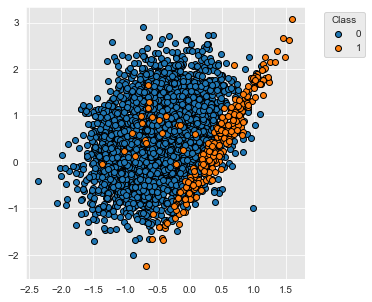

In [4]:
fig_distribution

Following the same methodology as in the [cost-sensitive learning section](Imbalanced_Learning_Illustrative_Example), the performances of a baseline classifier without resampling is obtained with the `kfold_cv_with_classifier` function. A decision tree of depth five and a 5-fold stratified cross-validation gives us the following baseline classification performances. 

In [5]:
# %%capture
# classifier = sklearn.tree.DecisionTreeClassifier(max_depth=5, random_state=0)
# 
# (results_df_dt_baseline, classifier_0, train_df, test_df) = kfold_cv_with_classifier(classifier, 
#                                                                                      X, y, 
#                                                                                      n_splits=5,
#                                                                                      strategy_name="Decision tree - Baseline")
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)


In [6]:
results_df_dt_baseline

,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Decision tree - Baseline,0.008+/-0.002,0.008+/-0.005,0.906+/-0.025,0.528+/-0.072,0.786+/-0.046


The decision boundary of the first classifier of the cross-validation is reported below. Due to class imbalance, the classifier tends to return equal probabilities for the two classes in the overlapping region. 

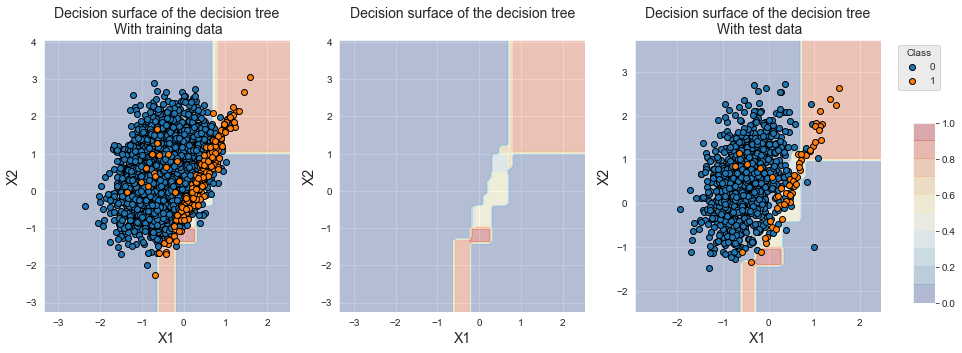

In [7]:
fig_decision_boundary

### Oversampling

Las técnicas de oversampling apuntan a rebalancear el conjunto de datos creando nuevas muestras para la clase minoritaria. Los dos métodos más ampliamente usados son *random oversampling* y *SMOTE* {cite}`fernandez2018learning,haixiang2017learning,chawla2002smote`. Las siguientes dos subsecciones muestran cómo se pueden implementar estos métodos, e ilustran su capacidad para mover las fronteras de decisión hacia la clase minoritaria. 

#### Oversampling aleatorio

Cubramos primero brevemente cómo la biblioteca `imblearn` permite remuestrear conjuntos de datos. Una introducción más completa se puede encontrar en el sitio web de la biblioteca, en https://imbalanced-learn.org/dev/introduction.html.

La biblioteca `imblearn` proporciona objetos llamados *samplers*, que toman como entrada un conjunto de datos y un conjunto de parámetros que son específicos del sampler, y devuelven un conjunto de datos remuestreado. 

Por ejemplo, el sampler de `imblearn` para oversampling aleatorio se llama [`RandomOverSampler`](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.RandomOverSampler.html). Su parámetro principal es `sampling_strategy`, que determina el ratio de desbalance deseado después del oversampling aleatorio.

Creemos por ejemplo un sampler para oversampling aleatorio, donde el conjunto de datos remuestreado debe tener un ratio de desbalance de 1 (es decir, donde las muestras de la clase minoritaria se duplican hasta que su número iguala el número de muestras en la clase mayoritaria).

In [8]:
# random_state is set to 0 for reproducibility
ROS = imblearn.over_sampling.RandomOverSampler(sampling_strategy=1, random_state=0)

Apliquemos este sampler en el DataFrame `train_df`, que es el conjunto de datos de entrenamiento en el primer fold de la validación cruzada realizada arriba. El DataFrame contiene 3784 muestras de clase 0 y 216 muestras de clase 1. 

In [9]:
train_df['Y'].value_counts()

0    3784
1     216
Name: Y, dtype: int64

The resampling of the dataset is performed by calling the `fit` method of the sampler object. Let `train_df_ROS` be the resampled DataFrame.

In [10]:
X_resampled, Y_resampled = ROS.fit_resample(train_df[['X1','X2']], train_df['Y'])
train_df_ROS = pd.DataFrame({'X1':X_resampled['X1'],'X2':X_resampled['X2'], 'Y':Y_resampled})

The resampled DataFrame now contains as many samples of class 1 as of class 0.

In [11]:
train_df_ROS['Y'].value_counts()

0    3784
1    3784
Name: Y, dtype: int64

Samplers can be combined with `sklearn` estimators using pipelines. The addition of a sampling step in the cross-validation procedure is therefore simple and consists in creating a pipeline made of a sampler, and an estimator. 

The implementation is provided below, in the `kfold_cv_with_sampler_and_classifier` function.

In [12]:
def kfold_cv_with_sampler_and_classifier(classifier,
                                         sampler_list,
                                         X,
                                         y,
                                         n_splits=5,
                                         strategy_name="Baseline classifier"):
    
    # Create a pipeline with the list of samplers, and the estimator
    estimators = sampler_list.copy()
    estimators.extend([('clf', classifier)])
    
    pipe = imblearn.pipeline.Pipeline(estimators)
    
    cv = sklearn.model_selection.StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    
    cv_results_ = sklearn.model_selection.cross_validate(pipe,X,y,cv=cv,
                                                         scoring=['roc_auc',
                                                                  'average_precision',
                                                                  'balanced_accuracy'],
                                                         return_estimator=True)
    
    results = round(pd.DataFrame(cv_results_),3)
    results_mean = list(results.mean().values)
    results_std = list(results.std().values)
    results_df = pd.DataFrame([[str(round(results_mean[i],3))+'+/-'+
                                str(round(results_std[i],3)) for i in range(len(results))]],
                              columns=['Fit time (s)','Score time (s)',
                                       'AUC ROC','Average Precision','Balanced accuracy'])
    results_df.rename(index={0:strategy_name}, inplace=True)
    
    classifier_0 = cv_results_['estimator'][0]
    
    (train_index, test_index) = next(cv.split(X, y))
    X_resampled, Y_resampled = X[train_index,:], y[train_index]
    for i in range(len(sampler_list)):
        X_resampled, Y_resampled = sampler_list[i][1].fit_resample(X_resampled, Y_resampled)
    
    test_df = pd.DataFrame({'X1':X[test_index,0],'X2':X[test_index,1], 'Y':y[test_index]})
    train_df = pd.DataFrame({'X1':X_resampled[:,0],'X2':X_resampled[:,1], 'Y':Y_resampled})
    
    return (results_df, classifier_0, train_df, test_df)

Let us assess the performances of the baseline classifier combined with random oversampling.

In [13]:
# %%capture
# 
# sampler_list = [('sampler',imblearn.over_sampling.RandomOverSampler(sampling_strategy=1, random_state=0))]
# classifier = sklearn.tree.DecisionTreeClassifier(max_depth=5, random_state=0)
# 
# (results_df_ROS, classifier_0, train_df, test_df) = kfold_cv_with_sampler_and_classifier(classifier, 
#                                                                                          sampler_list, 
#                                                                                          X, y, 
#                                                                                          n_splits=5,
#                                                                                          strategy_name="Decision tree - ROS")
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)

As a sanity check, we can verify that the training set size contains the same number of samples for the two classes.

In [14]:
train_df['Y'].value_counts()

0    3784
1    3784
Name: Y, dtype: int64

El remuestreo permitió desplazar la frontera de decisión hacia la clase minoritaria, como se puede ver en la figura a continuación. Note que los datos de entrenamiento para la clase minoritaria se ven iguales que el clasificador baseline. La mayoría de las instancias sin embargo han sido duplicadas muchas veces para alcanzar un ratio de desbalance de uno.

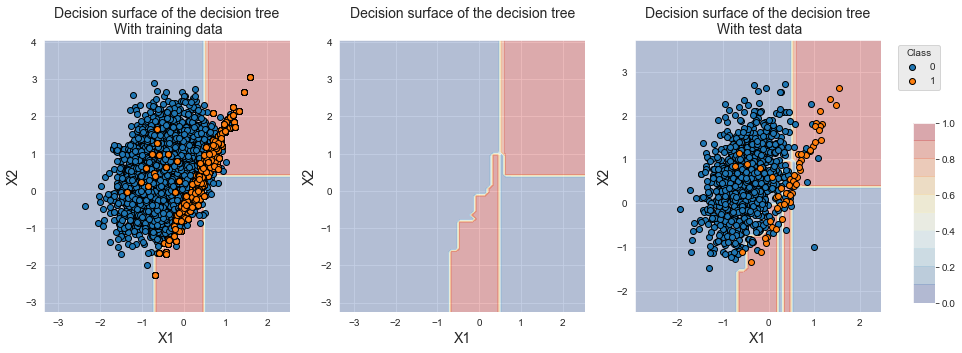

In [15]:
fig_decision_boundary

The classification performances show an increase in terms of balanced accuracy. We however note a decrease in terms of AUC ROC and Average Precision, due to the shift of the decision boundary which significantly increased the number of false positives. 

In [16]:
pd.concat([results_df_dt_baseline, 
           results_df_ROS])

,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Decision tree - Baseline,0.008+/-0.002,0.008+/-0.005,0.906+/-0.025,0.528+/-0.072,0.786+/-0.046
Decision tree - ROS,0.019+/-0.01,0.008+/-0.003,0.88+/-0.038,0.456+/-0.062,0.888+/-0.03


#### SMOTE

SMOTE {cite}`chawla2002smote` hace oversampling de la clase minoritaria generando ejemplos sintéticos en la vecindad de los observados. La idea es formar nuevos ejemplos minoritarios interpolando entre muestras de la misma clase. Esto tiene el efecto de crear clusters alrededor de cada observación minoritaria. Al crear observaciones sintéticas, el clasificador construye regiones de decisión más grandes que contienen instancias cercanas de la clase minoritaria. SMOTE ha demostrado mejorar los rendimientos de un clasificador base en muchas aplicaciones {cite}`dal2015adaptive,chawla2002smote`

El sampler de `imblearn` para SMOTE es [`imblearn.over_sampling.SMOTE`](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTE.html). Ilustremos el uso de SMOTE, y su impacto en la frontera de decisión del clasificador y los rendimientos de clasificación.

La implementación sigue la misma estructura que el oversampling aleatorio. La única diferencia es cambiar el sampler a SMOTE.


In [17]:
# %%capture
# 
# sampler_list = [('sampler', imblearn.over_sampling.SMOTE(sampling_strategy=1, random_state=0))]
# classifier = sklearn.tree.DecisionTreeClassifier(max_depth=5, random_state=0)
# 
# (results_df_SMOTE, classifier_0, train_df, test_df) = kfold_cv_with_sampler_and_classifier(classifier, 
#                                                                                            sampler_list, 
#                                                                                            X, y, 
#                                                                                            n_splits=5,
#                                                                                            strategy_name="Decision tree - SMOTE")
# 
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)

As with random oversampling, the number of samples in the minority class is increased to match the number of samples in the majority class (`sampling_strategy=1`).

In [18]:
train_df['Y'].value_counts()

0    3784
1    3784
Name: Y, dtype: int64

La frontera de decisión también se desplaza hacia la clase minoritaria. Notamos que, contrario al oversampling aleatorio, se han generado nuevos ejemplos para la clase minoritaria.

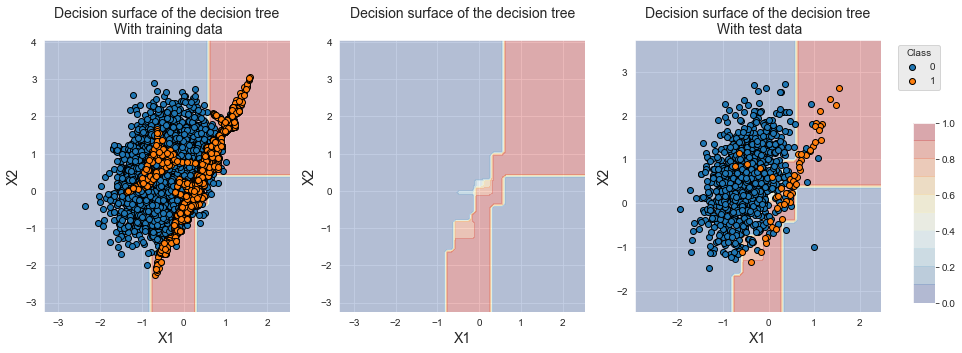

In [19]:
fig_decision_boundary

SMOTE provides higher performances than random oversampling for the three metrics. The Average Precision however remains lower than the baseline classifier.

In [20]:
pd.concat([results_df_dt_baseline, 
           results_df_ROS,
           results_df_SMOTE])

,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Decision tree - Baseline,0.008+/-0.002,0.008+/-0.005,0.906+/-0.025,0.528+/-0.072,0.786+/-0.046
Decision tree - ROS,0.019+/-0.01,0.008+/-0.003,0.88+/-0.038,0.456+/-0.062,0.888+/-0.03
Decision tree - SMOTE,0.022+/-0.012,0.008+/-0.003,0.913+/-0.032,0.499+/-0.056,0.91+/-0.019


#### Other oversampling strategies

There exists a range of more sophisticated strategies for oversampling, whose details go beyond the scope of this book. We refer the reader to {cite}`fernandez2018learning` for a review and to the [`imblearn` page on oversampling methods](https://imbalanced-learn.org/stable/references/over_sampling.html) for their implementations in Python. In particular the `imblearn` library provides the following additional oversampling methods: `SMOTENC` {cite}`chawla2002smote`, `SMOTEN` {cite}`chawla2002smote`, `ADASYN` {cite}`he2008adasyn`, `BorderlineSMOTE` {cite}`han2005borderline`, `KMeansSMOTE` {cite}`last2017oversampling`, and `SVMSMOTE` {cite}`nguyen2011borderline`. These methods can be used by simply replacing the sampler with the desired method in the code above. 



(Resampling_Strategies_Undersampling)=
### Undersampling

El undersampling se refiere al proceso de reducir el número de muestras en la clase mayoritaria. El enfoque simple, llamado *random undersampling* (RUS), consiste en eliminar aleatoriamente muestras de la clase mayoritaria hasta que se alcance el ratio de desbalance deseado. 

La principal desventaja de RUS es que el método puede descartar muestras que son importantes para identificar la frontera de decisión. Se han propuesto una gama de técnicas más avanzadas que apuntan a eliminar muestras de una manera más fundamentada {cite}`fernandez2018learning`. Además de RUS, el paquete `imblearn` propone no menos de diez métodos diferentes para undersampling {cite}`Imblearn`. La mayoría de estos métodos se basan en heurísticas de vecinos más cercanos que eliminan muestras cuando están cerca o lejos de otras muestras. Remitimos al lector a {cite}`fernandez2018learning,Imblearn` para los algoritmos detallados que subyacen a métodos de undersampling más avanzados.

Las siguientes dos subsecciones muestran cómo se pueden implementar dos de estos métodos, e ilustran su capacidad para mover la frontera de decisión hacia la clase minoritaria. Como ejemplos, nos basamos en RUS, y Edited Nearest Neighbor (ENN).


(Resampling_Strategies_RUS)=
#### Undersampling aleatorio

El sampler de `imblearn` para RUS es [`imblearn.under_sampling.RandomUnderSampler`](https://imbalanced-learn.org/dev/references/generated/imblearn.under_sampling.RandomUnderSampler.html). Ilustremos su uso y su impacto en la frontera de decisión del clasificador y los rendimientos de clasificación.

In [21]:
# %%capture
# 
# sampler_list = [('sampler', imblearn.under_sampling.RandomUnderSampler(sampling_strategy=1, random_state=0))]
# 
# classifier = sklearn.tree.DecisionTreeClassifier(max_depth=5, random_state=0)
# 
# (results_df_RUS, classifier_0, train_df, test_df) = kfold_cv_with_sampler_and_classifier(classifier, 
#                                                                                          sampler_list, 
#                                                                                          X, y, 
#                                                                                          n_splits=5,
#                                                                                          strategy_name="Decision tree - RUS")
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)

With a `sampling_strategy` set to one, RUS randomly removes samples from the majority class until their number reaches that of the minority class. After resampling, each class contains 216 samples.

In [22]:
train_df['Y'].value_counts()

0    216
1    216
Name: Y, dtype: int64

The plotting of training samples shows that the number of samples from the majority class was significantly reduced, allowing a shift of the decision boundary towards the minority class. Contrary to oversampling techniques, the region located at the bottom right is now associated with the minority class, since all samples of class 0 from this region have been removed.  

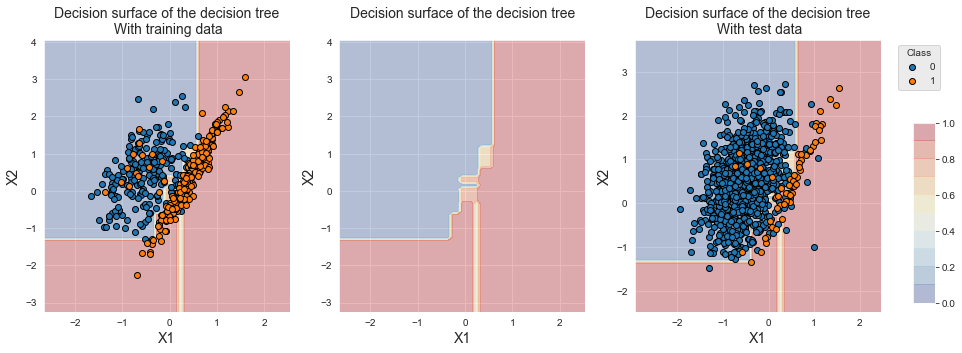

In [23]:
fig_decision_boundary

The performances in terms of AUC ROC and balanced accuracy are on par with oversampling techniques. We however note a loss of performance in terms of Average Precision. 

In [24]:
pd.concat([results_df_dt_baseline, 
           results_df_ROS,
           results_df_SMOTE,
           results_df_RUS])

,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Decision tree - Baseline,0.008+/-0.002,0.008+/-0.005,0.906+/-0.025,0.528+/-0.072,0.786+/-0.046
Decision tree - ROS,0.019+/-0.01,0.008+/-0.003,0.88+/-0.038,0.456+/-0.062,0.888+/-0.03
Decision tree - SMOTE,0.022+/-0.012,0.008+/-0.003,0.913+/-0.032,0.499+/-0.056,0.91+/-0.019
Decision tree - RUS,0.005+/-0.001,0.006+/-0.002,0.913+/-0.02,0.408+/-0.058,0.896+/-0.023


It is worth noting that the training time with RUS is faster. This results from the simple undersampling procedure and the smaller training set size. The method is therefore useful not only for reducing the imbalance ratio but also for speeding up the execution time of the modeling procedure.   

#### Vecino más cercano editado 

La regla de Edited Nearest Neighbor es una técnica de undersampling que elimina muestras de la clase mayoritaria en regiones superpuestas del conjunto de datos {cite}`laurikkala2001improving,wilson1972asymptotic`. Se basa en una regla de vecinos más cercanos, que elimina muestras de la clase mayoritaria de la siguiente manera {cite}`fernandez2018learning` (Capítulo 5, Página 84):

* Para cada muestra de la clase mayoritaria, se encuentran los k-vecinos más cercanos. Si la mayoría de estas muestras son de la clase minoritaria, se elimina la muestra de la clase mayoritaria.
* Para cada muestra de la clase minoritaria, se encuentran los k-vecinos más cercanos. Si la mayoría de estas muestras son de la clase mayoritaria, se elimina(n) la(s) muestra(s) de la clase mayoritaria.

El número de vecinos $k$ está por defecto establecido en $k=3$. Vale la pena notar que, contrario a RUS, el número de muestras de la clase mayoritaria que se eliminan depende del grado de superposición entre las dos clases. El método no permite especificar un ratio de desbalance. 

El sampler de `imblearn` para ENN es [`imblearn.under_sampling.EditedNearestNeighbours`](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.EditedNearestNeighbours.html). Ilustremos su uso y su impacto en la frontera de decisión del clasificador y los rendimientos de clasificación. 


In [25]:
# %%capture
# 
# sampler_list = [('sampler', imblearn.under_sampling.EditedNearestNeighbours(sampling_strategy='majority',n_neighbors=3))]
# 
# classifier = sklearn.tree.DecisionTreeClassifier(max_depth=5, random_state=0)
# 
# (results_df_ENN, classifier_0, train_df, test_df) = kfold_cv_with_sampler_and_classifier(classifier, 
#                                                                                          sampler_list, 
#                                                                                          X, y, 
#                                                                                          n_splits=5,
#                                                                                          strategy_name="Decision tree - ENN")
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)

With a number of neighbors `n_neighbors` set to three, ENN only removes around 200 samples out of the 3784 samples of the majority class. The number of samples from the minority class is unchanged. 

In [26]:
train_df['Y'].value_counts()

0    3572
1     216
Name: Y, dtype: int64

The plotting of training samples shows that the distributions of the two classes are similar to the original distributions. The samples that were removed lied in the overlapping region, and their removal is therefore not visible due to the large amount of remaining samples. We however observe a shift in the decicision boundary, since the decision tree now classifies samples from the overlapping region into the minority class. 

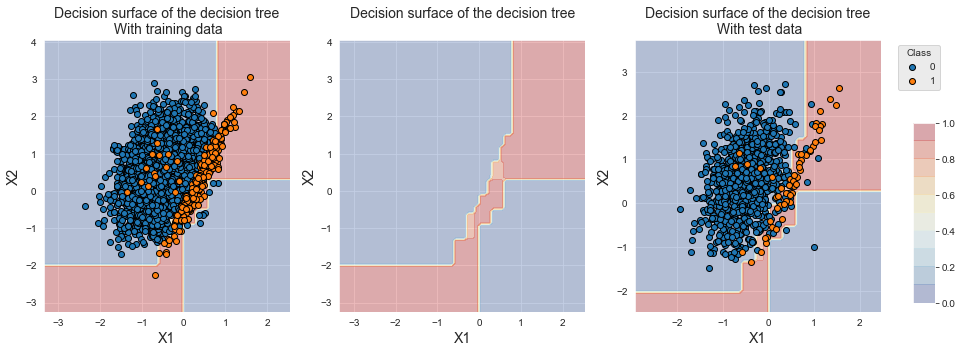

In [27]:
fig_decision_boundary

En este conjunto de datos, los rendimientos de ENN son pobres comparados con las técnicas probadas previamente. La precisión balanceada se mejoró ligeramente comparada con el clasificador baseline. El rendimiento en términos de AP es sin embargo más bajo que el baseline, y el AUC ROC es el peor de todas las técnicas probadas (y similar a ROS). 

In [28]:
pd.concat([results_df_dt_baseline, 
           results_df_ROS,
           results_df_SMOTE,
           results_df_RUS,
           results_df_ENN])

,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Decision tree - Baseline,0.008+/-0.002,0.008+/-0.005,0.906+/-0.025,0.528+/-0.072,0.786+/-0.046
Decision tree - ROS,0.019+/-0.01,0.008+/-0.003,0.88+/-0.038,0.456+/-0.062,0.888+/-0.03
Decision tree - SMOTE,0.022+/-0.012,0.008+/-0.003,0.913+/-0.032,0.499+/-0.056,0.91+/-0.019
Decision tree - RUS,0.005+/-0.001,0.006+/-0.002,0.913+/-0.02,0.408+/-0.058,0.896+/-0.023
Decision tree - ENN,0.023+/-0.004,0.009+/-0.005,0.879+/-0.038,0.474+/-0.08,0.857+/-0.041


#### Other undersampling strategies

As for ovesampling techniques, we refer the reader to {cite}`fernandez2018learning` for a review of more sophisticated undersampling techniques and to the [`imblearn` page on undersampling methods](https://imbalanced-learn.org/stable/references/under_sampling.html) for their implementations in Python. In particular the `imblearn` library provides ten other undersampling methods, which can be tested by simply replacing the sampler with the desired method in the code above. 


### Combining over and undersampling

Oversampling and undersampling are often complementary. On the one hand, oversampling techniques allow to generate synthetic samples from the minority class, and help a classifier in identifying more precisely the decision boundary between the two classes. On the other hand, undersampling techniques reduce the size of the training set, and allow to speed-up the classifier training time.  Combining over and undersampling techniques has often been reported to successfully improve the classifier performances (Chapter 5, Section 6 in {cite}fernandez2018learning).

In terms of implementation, the combination of samplers is obtained by chaining the samplers in a `pipeline`. The samplers can then be chained to a classifer. We illustrate below the chaining of an SMOTE oversampling to a random undersampling to a decision tree classifier. 

```
sampler_list = [('sampler1', imblearn.over_sampling.SMOTE(sampling_strategy=0.5,random_state=0)),
                ('sampler2', imblearn.under_sampling.RandomUnderSampler(sampling_strategy=1.0,random_state=0))
               ]

classifier = sklearn.tree.DecisionTreeClassifier(max_depth=5, random_state=0)

estimators = sampler_list.extend([('clf', classifier)])
    
pipe = imblearn.pipeline.Pipeline(estimators)
```

The `kfold_cv_with_sampler_and_classifier` takes the `sampler_list` and the `classifier` as two separate arguments, and takes care of chaining the samplers and classifier together. We can therefore follow the same template as before for assessing the performances of a classifier based on a chain of resampling techniques. The samplers are provided as a list with the `sampler_list` variable.  

In [29]:
# %%capture
# sampler_list = [('sampler1', imblearn.over_sampling.SMOTE(sampling_strategy=0.5,random_state=0)),
#                 ('sampler2', imblearn.under_sampling.RandomUnderSampler(sampling_strategy=1.0,random_state=0))
#                ]
# 
# classifier = sklearn.tree.DecisionTreeClassifier(max_depth=5, random_state=0)
# 
# (results_df_combined, classifier_0, train_df, test_df) = kfold_cv_with_sampler_and_classifier(classifier, 
#                                                                                               sampler_list, 
#                                                                                               X, y, 
#                                                                                               n_splits=5,
#                                                                                               strategy_name='Decision tree - Combined SMOTE and RUS')
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)

The SMOTE oversampling aimed at an imbalance ratio of 0.5. Since the original dataset contains 3784 sample of the majority class, SMOTE create new samples until the number of minority class samples reached $3784/2=1892$ samples. The random undersampling aimed at an imbalance ratio of 1. Since the SMOTE resampled dataset contains 1892 samples of the minority class, samples of the majority class are removed until their number reached 1892 samples. 

In [30]:
train_df['Y'].value_counts()

0    1892
1    1892
Name: Y, dtype: int64

The resulting decision boundary is close to that obtained with SMOTE, except that a slightly larger region is now considered to be of class 1 by the classifier. This is coherent since less samples of the minority class were created. 

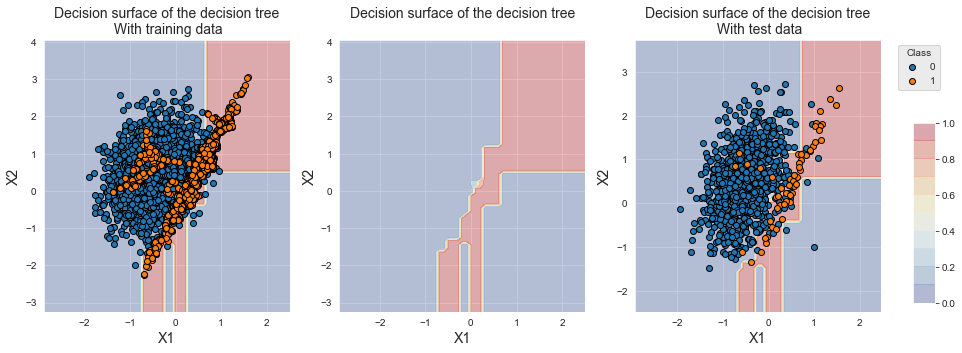

In [31]:
fig_decision_boundary

The resulting performances are on par with those of SMOTE. For larger dataset, one should however expect faster training times than SMOTE, since the training set size is decreased thanks to undersampling. 

In [32]:
pd.concat([results_df_dt_baseline, 
           results_df_ROS,
           results_df_SMOTE,
           results_df_RUS,
           results_df_ENN,
           results_df_combined])

,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Decision tree - Baseline,0.008+/-0.002,0.008+/-0.005,0.906+/-0.025,0.528+/-0.072,0.786+/-0.046
Decision tree - ROS,0.019+/-0.01,0.008+/-0.003,0.88+/-0.038,0.456+/-0.062,0.888+/-0.03
Decision tree - SMOTE,0.022+/-0.012,0.008+/-0.003,0.913+/-0.032,0.499+/-0.056,0.91+/-0.019
Decision tree - RUS,0.005+/-0.001,0.006+/-0.002,0.913+/-0.02,0.408+/-0.058,0.896+/-0.023
Decision tree - ENN,0.023+/-0.004,0.009+/-0.005,0.879+/-0.038,0.474+/-0.08,0.857+/-0.041
Decision tree - Combined SMOTE and RUS,0.019+/-0.005,0.008+/-0.001,0.915+/-0.012,0.494+/-0.062,0.912+/-0.005


(Resampling_Strategies_Transaction_Data)=
## Datos de transacciones

Apliquemos ahora técnicas de remuestreo al conjunto de datos simulado de datos de transacciones. Reutilizamos la metodología del [Capítulo 5, Selección de Modelos](Model_Selection), usando validación prequencial como estrategia de validación.

### Load data

The loading of data and initialization of the parameters follow the same template as in [Chapter 5, Model Selection](Model_Selection).

In [33]:
# Load data from the 2018-07-11 to the 2018-09-14

DIR_INPUT = 'simulated-data-transformed/data/' 

BEGIN_DATE = "2018-06-11"
END_DATE = "2018-09-14"

print("Load  files")
%time transactions_df = read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))


# Number of folds for the prequential validation
n_folds = 4

# Set the starting day for the training period, and the deltas
start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train = delta_delay = delta_test = delta_valid = delta_assessment = 7

start_date_training_for_valid = start_date_training+datetime.timedelta(days=-(delta_delay+delta_valid))
start_date_training_for_test = start_date_training+datetime.timedelta(days=(n_folds-1)*delta_test)

output_feature = "TX_FRAUD"

input_features = ['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']


# Only keep columns that are needed as argument to the custom scoring function
# (in order to reduce the serialization time of transaction dataset)
transactions_df_scorer = transactions_df[['CUSTOMER_ID', 'TX_FRAUD','TX_TIME_DAYS']]

card_precision_top_100 = sklearn.metrics.make_scorer(card_precision_top_k_custom, 
                                                     needs_proba=True, 
                                                     top_k=100, 
                                                     transactions_df=transactions_df_scorer)

performance_metrics_list_grid = ['roc_auc', 'average_precision', 'card_precision@100']
performance_metrics_list = ['AUC ROC', 'Average precision', 'Card Precision@100']

scoring = {'roc_auc':'roc_auc',
           'average_precision': 'average_precision',
           'card_precision@100': card_precision_top_100,
           }


Load  files
CPU times: user 812 ms, sys: 580 ms, total: 1.39 s
Wall time: 1.63 s
919767 transactions loaded, containing 8195 fraudulent transactions


As a baseline, let us compute the fraud detection performances with a decision tree of depth 5 without any resampling. 

In [34]:
# Define classifier
classifier = sklearn.tree.DecisionTreeClassifier()

# Set of parameters for which to assess model performances
parameters = {'clf__max_depth':[5], 'clf__random_state':[0]}

start_time = time.time()

# Fit models and assess performances for all parameters
performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=1)

execution_time_dt = time.time()-start_time

# Select parameter of interest (max_depth)
parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[parameters_dict[i]['clf__max_depth'] for i in range(len(parameters_dict))]

# Rename to performances_df_dt for model performance comparison at the end of this notebook
performances_df_dt=performances_df


In [35]:
summary_performances_dt=get_summary_performances(performances_df_dt, parameter_column_name="Parameters summary")
summary_performances_dt

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,5,5,5
Validation performance,0.804+/-0.02,0.546+/-0.04,0.268+/-0.01
Test performance,0.81+/-0.01,0.6+/-0.02,0.284+/-0.0
Optimal parameter(s),5,5,5
Optimal test performance,0.81+/-0.01,0.6+/-0.02,0.284+/-0.0


This baseline will be used at the end of the notebook to assess the benefits of different resampling techniques.  

### Prequential validation with resampling

The addition of resampling to the prequential validation simply consists in extending the pipeline defined in [Chapter 5, Validation Strategies](Sklearn_Validation_Pipeline) with the sampler objects. We add this step at the beginning of the `prequential_grid_search` function and rename it as `prequential_grid_search_with_sampler`. Note that the pipeline is created with the `Pipeline` object from the `imblearn` module so that samplers are properly processed.

In [36]:
def prequential_grid_search_with_sampler(transactions_df, 
                                         classifier, sampler_list,
                                         input_features, output_feature, 
                                         parameters, scoring, 
                                         start_date_training, 
                                         n_folds=4,
                                         expe_type='Test',
                                         delta_train=7, 
                                         delta_delay=7, 
                                         delta_assessment=7,
                                         performance_metrics_list_grid=['roc_auc'],
                                         performance_metrics_list=['AUC ROC'],
                                         n_jobs=-1):
    
    estimators = sampler_list.copy()
    estimators.extend([('clf', classifier)])
    
    pipe = imblearn.pipeline.Pipeline(estimators)
    
    prequential_split_indices = prequentialSplit(transactions_df,
                                                 start_date_training=start_date_training, 
                                                 n_folds=n_folds, 
                                                 delta_train=delta_train, 
                                                 delta_delay=delta_delay, 
                                                 delta_assessment=delta_assessment)
    
    grid_search = sklearn.model_selection.GridSearchCV(pipe, parameters, scoring=scoring, cv=prequential_split_indices, refit=False, n_jobs=n_jobs)
    
    X = transactions_df[input_features]
    y = transactions_df[output_feature]

    grid_search.fit(X, y)
    
    performances_df = pd.DataFrame()
    
    for i in range(len(performance_metrics_list_grid)):
        performances_df[performance_metrics_list[i]+' '+expe_type]=grid_search.cv_results_['mean_test_'+performance_metrics_list_grid[i]]
        performances_df[performance_metrics_list[i]+' '+expe_type+' Std']=grid_search.cv_results_['std_test_'+performance_metrics_list_grid[i]]

    performances_df['Parameters'] = grid_search.cv_results_['params']
    performances_df['Execution time'] = grid_search.cv_results_['mean_fit_time']
    
    return performances_df

The `model_selection_wrapper` function is also modified into a `model_selection_wrapper_with_sampler` function, which calls the `prequential_grid_search_with_sampler` function for prequential grid search. 

In [37]:
def model_selection_wrapper_with_sampler(transactions_df, 
                                         classifier, 
                                         sampler_list,
                                         input_features, output_feature,
                                         parameters, 
                                         scoring, 
                                         start_date_training_for_valid,
                                         start_date_training_for_test,
                                         n_folds=4,
                                         delta_train=7, 
                                         delta_delay=7, 
                                         delta_assessment=7,
                                         performance_metrics_list_grid=['roc_auc'],
                                         performance_metrics_list=['AUC ROC'],
                                         n_jobs=-1):

    # Get performances on the validation set using prequential validation
    performances_df_validation = prequential_grid_search_with_sampler(transactions_df, classifier, sampler_list,
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_valid,
                            n_folds=n_folds,
                            expe_type='Validation',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            n_jobs=n_jobs)
    
    # Get performances on the test set using prequential validation
    performances_df_test = prequential_grid_search_with_sampler(transactions_df, classifier, sampler_list,
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_test,
                            n_folds=n_folds,
                            expe_type='Test',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            n_jobs=n_jobs)
    
    # Bind the two resulting DataFrames
    performances_df_validation.drop(columns=['Parameters','Execution time'], inplace=True)
    performances_df = pd.concat([performances_df_test,performances_df_validation],axis=1)

    # And return as a single DataFrame
    return performances_df

Model selection with resampling can now be performed by calling the `model_selection_wrapper_with_sampler` function, following the same methodology as in [Chapter 5](Model_Selection). 

(Resampling_Strategies_Transaction_Data_Oversampling)=
### Oversampling

Let us illustrate its use with SMOTE oversampling. We create a `SMOTE` object and store it in a `sampler_list` list. The list is passed as an argument to the `model_selection_wrapper_with_sampler` function. Additionally, the `sampling_strategy` parameter to the `SMOTE` object (imbalance ratio) is parametrized to take values in the set $[0.01, 0.05, 0.1, 0.5, 1]$ for the model selection procedure.  


In [38]:
# Define classifier
classifier = sklearn.tree.DecisionTreeClassifier()

# Define sampling strategy
sampler_list = [('sampler', imblearn.over_sampling.SMOTE(random_state=0))]

# Set of parameters for which to assess model performances
parameters = {'clf__max_depth':[5], 'clf__random_state':[0],
              'sampler__sampling_strategy':[0.01, 0.05, 0.1, 0.5, 1], 'sampler__random_state':[0]}

start_time = time.time()

# Fit models and assess performances for all parameters
performances_df=model_selection_wrapper_with_sampler(transactions_df, classifier, sampler_list, 
                                                     input_features, output_feature,
                                                     parameters, scoring, 
                                                     start_date_training_for_valid,
                                                     start_date_training_for_test,
                                                     n_folds=n_folds,
                                                     delta_train=delta_train, 
                                                     delta_delay=delta_delay, 
                                                     delta_assessment=delta_assessment,
                                                     performance_metrics_list_grid=performance_metrics_list_grid,
                                                     performance_metrics_list=performance_metrics_list,
                                                     n_jobs=1)

execution_time_dt_SMOTE = time.time()-start_time


We then retrieve the performances for each of the tested imbalance ratios (`sampling_strategy` value) and store the results in a `performances_df_SMOTE` DataFrame.

In [39]:
# Select parameter of interest (sampling_strategy)
parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[parameters_dict[i]['sampler__sampling_strategy'] for i in range(len(parameters_dict))]

# Rename to performances_df_SMOTE for model performance comparison at the end of this notebook
performances_df_SMOTE = performances_df

In [40]:
performances_df_SMOTE

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.805165,0.005955,0.587136,0.010773,0.282143,0.007389,"{'clf__max_depth': 5, 'clf__random_state': 0, ...",0.559659,0.803468,0.014269,0.554155,0.032957,0.267500,0.014120,0.01
1,0.823732,0.006235,0.572835,0.024824,0.285357,0.012753,"{'clf__max_depth': 5, 'clf__random_state': 0, ...",0.542496,0.809590,0.018765,0.558479,0.027820,0.271429,0.010785,0.05
2,0.827219,0.010190,0.544275,0.037686,0.290357,0.010070,"{'clf__max_depth': 5, 'clf__random_state': 0, ...",0.569432,0.807543,0.016324,0.537672,0.040918,0.268214,0.013224,0.10
3,0.842985,0.018418,0.558118,0.033607,0.289286,0.015860,"{'clf__max_depth': 5, 'clf__random_state': 0, ...",0.829486,0.849501,0.015830,0.495635,0.052593,0.279286,0.018028,0.50
4,0.845270,0.008136,0.545954,0.031952,0.294643,0.011401,"{'clf__max_depth': 5, 'clf__random_state': 0, ...",1.091997,0.857367,0.012183,0.493752,0.049094,0.278571,0.014463,1.00


Let us summarize the performances to highlight the optimal imbalance ratios.

In [41]:
summary_performances_SMOTE = get_summary_performances(performances_df_SMOTE, parameter_column_name="Parameters summary")
summary_performances_SMOTE

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,1.0,0.05,0.5
Validation performance,0.857+/-0.01,0.558+/-0.03,0.279+/-0.02
Test performance,0.845+/-0.01,0.573+/-0.02,0.289+/-0.02
Optimal parameter(s),1.0,0.01,1.0
Optimal test performance,0.845+/-0.01,0.587+/-0.01,0.295+/-0.01


We note conflicting results, as the optimal imbalance ratio depends on the performance metric. For better visualization, let us plot the performances as a function of the imbalance ratio for the three performance metrics.

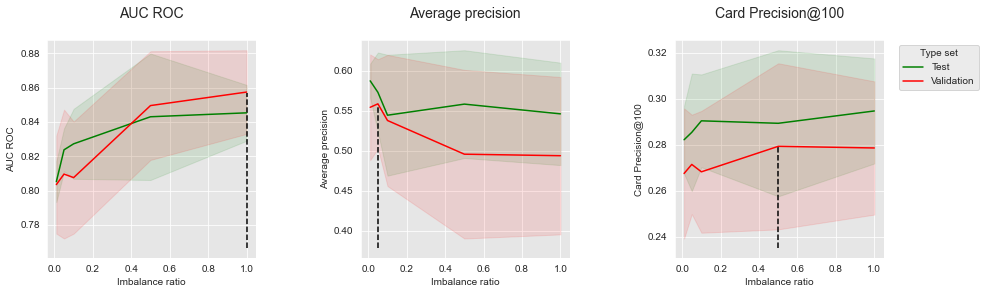

In [42]:
get_performances_plots(performances_df_SMOTE, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Imbalance ratio",
                       summary_performances=summary_performances_SMOTE)

The performances tend to increase with the imbalance ratio for AUC ROC and CP@100. The opposite is however observed for Average Precision. The creation of synthetic samples with SMOTE is therefore beneficial to AUC ROC and CP@100, but detrimental to the Average Precision.  

(Resampling_Strategies_Transaction_Data_RUS)=
### Undersampling

Let us follow the same methodology using random undersampling. The `RandomUnderSampler` object is used, and models are assessed for imbalance ratios taking values in the set $[0.01, 0.05, 0.1, 0.5, 1]$.

In [43]:
# Define classifier
classifier = sklearn.tree.DecisionTreeClassifier()

# Define sampling strategy
sampler_list = [('sampler', imblearn.under_sampling.RandomUnderSampler())]

# Set of parameters for which to assess model performances
parameters = {'clf__max_depth':[5], 'clf__random_state':[0],
              'sampler__sampling_strategy':[0.01, 0.05, 0.1, 0.5, 1], 'sampler__random_state':[0]}

start_time = time.time()

# Fit models and assess performances for all parameters
performances_df=model_selection_wrapper_with_sampler(transactions_df, classifier, sampler_list, 
                                                     input_features, output_feature,
                                                     parameters, scoring, 
                                                     start_date_training_for_valid,
                                                     start_date_training_for_test,
                                                     n_folds=n_folds,
                                                     delta_train=delta_train, 
                                                     delta_delay=delta_delay, 
                                                     delta_assessment=delta_assessment,
                                                     performance_metrics_list_grid=performance_metrics_list_grid,
                                                     performance_metrics_list=performance_metrics_list,
                                                     n_jobs=1)

execution_time_dt_RUS = time.time()-start_time

# Select parameter of interest (sampling_strategy)
parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[parameters_dict[i]['sampler__sampling_strategy'] for i in range(len(parameters_dict))]

# Rename to performances_df_RUS for model performance comparison at the end of this notebook
performances_df_RUS = performances_df


Let us summarize the performances to highlight the optimal imbalance ratios, and plot the performances as a function of the imbalance ratio. 

In [44]:
summary_performances_RUS=get_summary_performances(performances_df_RUS, parameter_column_name="Parameters summary")
summary_performances_RUS

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,1.0,0.01,0.1
Validation performance,0.845+/-0.01,0.535+/-0.04,0.269+/-0.01
Test performance,0.83+/-0.01,0.594+/-0.02,0.277+/-0.01
Optimal parameter(s),1.0,0.01,0.5
Optimal test performance,0.83+/-0.01,0.594+/-0.02,0.292+/-0.01


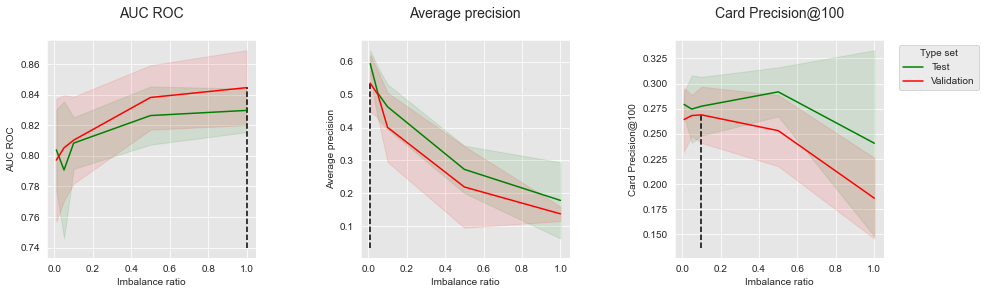

In [45]:
get_performances_plots(performances_df_RUS, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Imbalance ratio",
                       summary_performances=summary_performances_RUS)

As with oversampling, rebalancing the dataset leads to an increase in performance in terms of AUC ROC, but to a strong decrease of performance in terms of AP. The results in terms of CP@100 follow an intermediate trend: The performance first slightly increases with the imbalance ratio, and then decreases with more aggressive undersampling.  

(Resampling_Strategies_Transaction_Data_Combining)=
### Combining

We finally illustrate the combination of oversampling and undersampling with SMOTE and random undersampling. A `SMOTE` and `RandomUnderSampler` objects are instantiated and stored in the `sampler_list` list. We parametrize the `SMOTE` sampler with a target imbalance ratio of $0.1$, and the `RandomUnderSampler` to take values in the set $[0.1, 0.5, 1]$.

In [46]:
# Define classifier
classifier = sklearn.tree.DecisionTreeClassifier()

# Define sampling strategy
sampler_list = [('sampler1', imblearn.over_sampling.SMOTE()),
                ('sampler2', imblearn.under_sampling.RandomUnderSampler())
               ]

# Set of parameters for which to assess model performances
parameters = {'clf__max_depth':[5], 'clf__random_state':[0],
              'sampler1__sampling_strategy':[0.1], 
              'sampler2__sampling_strategy':[0.1, 0.5, 1], 
              'sampler1__random_state':[0], 'sampler2__random_state':[0]}

start_time = time.time()

# Fit models and assess performances for all parameters
performances_df = model_selection_wrapper_with_sampler(transactions_df, classifier, sampler_list, 
                                                     input_features, output_feature,
                                                     parameters, scoring, 
                                                     start_date_training_for_valid,
                                                     start_date_training_for_test,
                                                     n_folds=n_folds,
                                                     delta_train=delta_train, 
                                                     delta_delay=delta_delay, 
                                                     delta_assessment=delta_assessment,
                                                     performance_metrics_list_grid=performance_metrics_list_grid,
                                                     performance_metrics_list=performance_metrics_list,
                                                     n_jobs=1)

execution_time_dt_combined = time.time()-start_time

# Select parameter of interest (max_depth)
parameters_dict = dict(performances_df['Parameters'])
performances_df['Parameters summary']=[parameters_dict[i]['sampler2__sampling_strategy'] for i in range(len(parameters_dict))]

# Rename to performances_df_combined for model performance comparison at the end of this notebook
performances_df_combined = performances_df


In [47]:
performances_df_combined

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.827219,0.010190,0.544275,0.037686,0.290357,0.010070,"{'clf__max_depth': 5, 'clf__random_state': 0, ...",0.608622,0.807543,0.016324,0.537672,0.040918,0.268214,0.013224,0.1
1,0.848464,0.008701,0.471467,0.010144,0.299643,0.011968,"{'clf__max_depth': 5, 'clf__random_state': 0, ...",0.395396,0.841237,0.015297,0.428576,0.050091,0.279286,0.010903,0.5
2,0.847110,0.010754,0.385133,0.064916,0.287857,0.018364,"{'clf__max_depth': 5, 'clf__random_state': 0, ...",0.384152,0.856399,0.012189,0.342964,0.020342,0.280357,0.017420,1.0


Let us summarize the performances to highlight the optimal imbalance ratios, and plot the performances as a function of the imbalance ratio. 

In [48]:
summary_performances_combined = get_summary_performances(performances_df=performances_df_combined, 
                                                         parameter_column_name="Parameters summary")
summary_performances_combined

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,1.0,0.1,1.0
Validation performance,0.856+/-0.01,0.538+/-0.04,0.28+/-0.02
Test performance,0.847+/-0.01,0.544+/-0.04,0.288+/-0.02
Optimal parameter(s),0.5,0.1,0.5
Optimal test performance,0.848+/-0.01,0.544+/-0.04,0.3+/-0.01


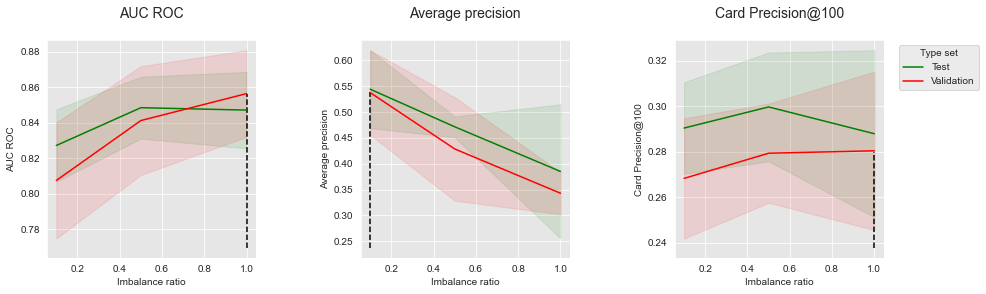

In [49]:
get_performances_plots(performances_df_combined, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Imbalance ratio",
                       summary_performances=summary_performances_combined)

The results follow the same trends as with oversampling and undersampling: Rebalancing improves the performances in terms of AUC ROC, but decreases the performances in terms of Average Precision. The impact of rebalancing on CP@100 is mitigated.

Let us finally compare the test performances obtained with the oversampling, undersampling, and combined resampling, and compare them to the baseline classifier.  

In [50]:
summary_test_performances = pd.concat([summary_performances_dt.iloc[2,:],
                                       summary_performances_SMOTE.iloc[2,:],
                                       summary_performances_RUS.iloc[2,:],
                                       summary_performances_combined.iloc[2,:],
                                      ],axis=1)
summary_test_performances.columns=['Baseline', 'SMOTE', 'RUS', 'Combined']
summary_test_performances

,Baseline,SMOTE,RUS,Combined
AUC ROC,0.81+/-0.01,0.845+/-0.01,0.83+/-0.01,0.847+/-0.01
Average precision,0.6+/-0.02,0.573+/-0.02,0.594+/-0.02,0.544+/-0.04
Card Precision@100,0.284+/-0.0,0.289+/-0.02,0.277+/-0.01,0.288+/-0.02


Compared to the baseline classifier, all resampling techniques managed to improve the performances in terms of AUC ROC. All of them however led to a decrease in Average Precision. Slight improvements in terms of CP@100 could be achieved with SMOTE and the combined approach, but not with undersampling. 

## Summary

The experiments carried out in this section illustrated that the benefits of resampling techniques depend on the performance metric that is used. While resampling can generally be beneficial to AUC ROC, we observed that they led in almost all cases to a decrease of performances in terms of Average Precision. It is worth noting that the results are coherent with those obtained using cost-sensitive techniques in [the previous section](Cost_Sensitive_Learning). 

## Saving of results

Let us finally save the performance results and execution times.

In [51]:
performances_df_dictionary={
    "SMOTE": performances_df_SMOTE,
    "RUS": performances_df_RUS,
    "Combined": performances_df_combined
}

execution_times=[execution_time_dt_SMOTE,
                 execution_time_dt_RUS,
                 execution_time_dt_combined,
                ]


In [52]:
filehandler = open('performances_resampling.pkl', 'wb') 
pickle.dump((performances_df_dictionary, execution_times), filehandler)
filehandler.close()


---

## CostSensitive


(Cost_Sensitive_Learning)=
# Cost-sensitive learning


Cost-sensitive learning is a subfield of machine learning that addresses classification problems where the misclassification costs are not equal {cite}`fernandez2018learning,elkan2001foundations,ling2008cost`. Cost-sensitive problems occur in many disciplines such as medicine (e.g., disease detection), engineering (e.g., machine failure detection), transport (e.g., traffic-jam detection), finance (e.g., fraud detection), and so forth. They are often related to the class-imbalance problem since in most of these problems, the goal is to detect events that are rare. The training datasets therefore typically contain fewer examples of the event of interest.  

We already addressed fraud detection as a cost-sensitive problem in [Chapter 4, Cost Matrix](Performance_CostMatrix). The section pointed out the cost matrix as the standard way to quantify the misclassification costs. Denoting by $C$ the *cost matrix*, its entries $c(i,j)$ quantify the cost of predicting class $i$ when the true class is $j$ {cite}`elkan2001foundations`. For a binary classification problem, the cost matrix is a $2*2$ matrix, as illustrated in Fig. 1. 

![](images/cost_matrix.png)
<div align="center">Fig. 1. Example of cost matrix.</div>    

Correct classifications have a cost of zero, that is, $c_{00}=c_{11}=0$. Misclassification costs are however in practice difficult to estimate. As discussed in [Chapter 4, Cost Matrix](Performance_CostMatrix), missing a fraudulent transaction (false negative) involves a loss directly related to the amount of the transaction, but also on further fraudulent uses of the card, and on the company reputation. At the same time, the blocking of transactions that are legitimate (false positive) causes inconvenience to customers, generates useless investigation costs, and also impacts the company reputation.  

In cost-sensitive imbalanced problems, the most popular heuristic approach to estimate the costs lies in utilizing the imbalance ratio (IR). Let us denote by $\mathcal{X}$ the imbalanced dataset, with $\mathcal{X}_0$ and $\mathcal{X}_1$ being the subsets of samples belonging to the majority and minority class, respectively. The IR of the dataset $\mathcal{X}$ is defined as {cite}`JMLR:v18:16-365`:

$$
IR=\frac{|\mathcal{X}_1|}{|\mathcal{X}_0|}
$$

where $|·|$ denotes the cardinality of a set. In this setting, $C(i,j) = IR$ and $C(j,i) = 1$, where the minority class is the i-th class, and the majority class is the j-th class. It is worth noting that using the IR as the cost for the majority class balances the overall cost of the two classes, that is, $|\mathcal{X}_1|=IR*|\mathcal{X}_0|$. The resulting cost matrix for a 2-class problem is given in Fig. 2.

![](images/cost_matrix_IR.png)
<div align="center">Fig. 2. Cost matrix for imbalanced data. The cost of a false negative is 1, and the cost of a false positive is the imbalance ratio (IR).</div>      

Using the IR to set the misclassification costs is usually a good heuristic. It however has some limitations, in particular related to small sample size, class overlapping, and noisy or borderline instances {cite}`fernandez2018learning`. A common complementary practice consists in considering the misclassification costs as a hyperparameter to be identified through model selection. 

Python sklearn provides support for cost-sensitive learning for most baseline classifiers thanks to the `class_weight` parameter. The parameter allows to specify costs in three different ways:

* `None`: The misclassification costs are set to 1 (default)
* `balanced`: The costs are set according to the imbalance ratio (as in Fig. 2)
* `{0:c10, 1:c01}`: The misclassification costs are explicitly set for the two classes by means of a dictionary.

The use of class weights usually implies a modification in the loss function of the learning algorithm. The modification depends on the type of algorithm. By strongly penalizing mistakes on the minority class, cost-sensitive learning improves their importance during the classifier training step. This pushes the decision boundary away from these instances, allowing to improve generalization on the minority class {cite}`fernandez2018learning,gupta2020class`.

This section presents how cost-sensitive learning can be used with the Python sklearn library. For better visualization, we first rely on a simple imbalanced dataset with two variables to illustrate how different misclassification costs change the decision boundaries. We then apply the approach to the larger simulated dataset of transaction data.  


In [1]:
# Initialization: Load shared functions and simulated data 

# Load shared functions
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py
#%run ../Chapter_References/shared_functions.ipynb

# Get simulated data from Github repository
if not os.path.exists("simulated-data-transformed"):
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-transformed
        

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 63060  100 63060    0     0   221k      0 --:--:-- --:--:-- --:--:--  220k


(Imbalanced_Learning_Illustrative_Example)=
## Illustrative example

For illustrative purposes, let us first consider a simple classification task. We use the `make_classification` function of the sklearn library to generate a two-class imbalanced dataset with 5000 examples. The dataset contains 95% of examples of class 0 and 5% of examples of class 1.  

In [2]:
X, y = sklearn.datasets.make_classification(n_samples=5000, n_features=2, n_informative=2,
                                            n_redundant=0, n_repeated=0, n_classes=2,
                                            n_clusters_per_class=1,
                                            weights=[0.95, 0.05],
                                            class_sep=0.5, random_state=0)

dataset_df = pd.DataFrame({'X1':X[:,0],'X2':X[:,1], 'Y':y})


The distribution of the two classes slighly overlap, as illustrated below.

In [3]:
# %%capture
# fig_distribution, ax = plt.subplots(1, 1, figsize=(5,5))
# 
# groups = dataset_df.groupby('Y')
# for name, group in groups:
#     ax.scatter(group.X1, group.X2, edgecolors='k', label=name,alpha=1,marker='o')
#     
# ax.legend(loc='upper left', 
#           bbox_to_anchor=(1.05, 1),
#           title="Class")

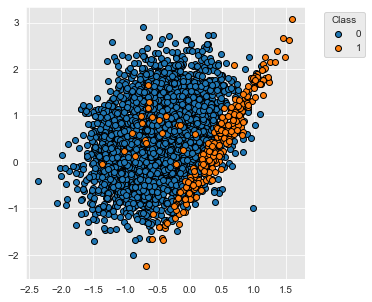

In [4]:
fig_distribution

### Decision tree

Let us now train a decision tree to separate the two classes. We use a decision tree of depth 5, and a stratified 5-fold cross-validation to assess the performances of the classifier. The performances are assessed in terms of AUC ROC, Average precision, and balanced accuracy. The class weights are set to 1 for both classes.

In [5]:
classifier = sklearn.tree.DecisionTreeClassifier(max_depth=5,class_weight={0:1,1:1},random_state=0)
cv = sklearn.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [6]:
cv_results_ = sklearn.model_selection.cross_validate(classifier, X, y, cv=cv,
                                                     scoring=['roc_auc',
                                                              'average_precision',
                                                              'balanced_accuracy'],
                                                     return_estimator=True)

The performances for each fold are returned in the `cv_results_` dictionary, which is better visualized as a DataFrame. 

In [7]:
results = round(pd.DataFrame(cv_results_),3)
results

,fit_time,score_time,estimator,test_roc_auc,test_average_precision,test_balanced_accuracy
0,0.006,0.004,"DecisionTreeClassifier(class_weight={0: 1, 1: ...",0.933,0.616,0.842
1,0.006,0.004,"DecisionTreeClassifier(class_weight={0: 1, 1: ...",0.871,0.493,0.739
2,0.006,0.011,"DecisionTreeClassifier(class_weight={0: 1, 1: ...",0.897,0.493,0.799
3,0.009,0.005,"DecisionTreeClassifier(class_weight={0: 1, 1: ...",0.928,0.591,0.812
4,0.007,0.004,"DecisionTreeClassifier(class_weight={0: 1, 1: ...",0.901,0.447,0.738


Let us take the mean and standard deviation of the performances across all folds.

In [8]:
results_mean = list(results.mean().values)
results_std = list(results.std().values)

pd.DataFrame([[str(round(results_mean[i],3))+'+/-'+str(round(results_std[i],3)) for i in range(len(results))]],
            columns=['Fit time (s)','Score time (s)','AUC ROC','Average Precision','Balanced accuracy'])

,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
0,0.007+/-0.001,0.006+/-0.003,0.906+/-0.025,0.528+/-0.072,0.786+/-0.046


The performances are rather good since the AUC ROC is well beyond $0.5$ and the average precision over $0.05$. The balanced accuracy is however not so high, suggesting that the decision boundary misclassifies many of the samples from the minority class. 

Let us finally plot the decision boundary provided by one of the decision trees. We use the decision tree obtained from the first fold of the cross-validation.

In [9]:
def plot_decision_boundary_classifier(ax, 
                                      classifier,
                                      train_df,
                                      input_features=['X1','X2'],
                                      output_feature='Y',
                                      title="",
                                      fs=14,
                                      plot_training_data=True):

    plot_colors = ["tab:blue","tab:orange"]

    x1_min, x1_max = train_df[input_features[0]].min() - 1, train_df[input_features[0]].max() + 1
    x2_min, x2_max = train_df[input_features[1]].min() - 1, train_df[input_features[1]].max() + 1
    
    plot_step=0.1
    xx, yy = np.meshgrid(np.arange(x1_min, x1_max, plot_step),
                         np.arange(x2_min, x2_max, plot_step))

    Z = classifier.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu_r,alpha=0.3)

    if plot_training_data:
        # Plot the training points
        groups = train_df.groupby(output_feature)
        for name, group in groups:
            ax.scatter(group[input_features[0]], group[input_features[1]], edgecolors='black', label=name)
        
    ax.set_title(title, fontsize=fs)
    ax.set_xlabel(input_features[0], fontsize=fs)
    ax.set_ylabel(input_features[1], fontsize=fs)
    

In [10]:
# Retrieve the decision tree from the first fold of the cross-validation
classifier_0 = cv_results_['estimator'][0]

In [11]:
# Retrieve the indices used for the training and testing of the first fold of the cross-validation
(train_index, test_index) = next(cv.split(X, y))

# Recreate the train and test DafaFrames from these indices
train_df = pd.DataFrame({'X1':X[train_index,0], 'X2':X[train_index,1], 'Y':y[train_index]})
test_df = pd.DataFrame({'X1':X[test_index,0], 'X2':X[test_index,1], 'Y':y[test_index]})
input_features = ['X1','X2']
output_feature = 'Y'

In [12]:
# %%capture
# fig_decision_boundary, ax = plt.subplots(1, 3, figsize=(5*3,5))
# 
# plot_decision_boundary_classifier(ax[0], classifier_0,
#                                   train_df,
#                                   title="Decision surface of the decision tree\n With training data",
#                                   plot_training_data=True)
# 
# plot_decision_boundary_classifier(ax[1], classifier_0,
#                                   train_df,
#                                   title="Decision surface of the decision tree\n",
#                                   plot_training_data=False)
# 
# 
# plot_decision_boundary_classifier(ax[2], classifier_0,
#                                   test_df,
#                                   title="Decision surface of the decision tree\n With test data",
#                                   plot_training_data=True)
# 
# ax[-1].legend(loc='upper left', 
#               bbox_to_anchor=(1.05, 1),
#               title="Class")
# 
# sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu_r, norm=plt.Normalize(vmin=0, vmax=1))
# cax = fig_decision_boundary.add_axes([0.93, 0.15, 0.02, 0.5])
# fig_decision_boundary.colorbar(sm, cax=cax, alpha=0.3, boundaries=np.linspace(0, 1, 11))

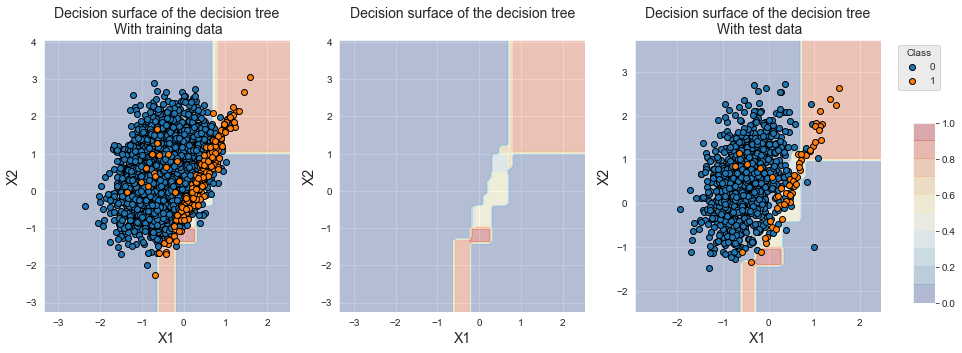

In [13]:
fig_decision_boundary

For better visualization, we report the decision boundaries alone (middle), with the training data (left), and with the test data (right). The plots show that the decision tree correctly identifies the region where the minority class samples lie. The decision tree however mostly classifies samples from the overlapping region into the majority class (yellow/blue color gradient).


We will reuse the functions above for computing the performances and for plotting the decision boundaries. For the sake of code conciseness, we implement two functions for computing the cross-validation results (`kfold_cv_with_classifier`) and for plotting the decision boundaries (`plot_decision_boundary`).

In [14]:
def kfold_cv_with_classifier(classifier,
                             X,
                             y,
                             n_splits=5,
                             strategy_name="Basline classifier"):
    
    cv = sklearn.model_selection.StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    
    cv_results_ = sklearn.model_selection.cross_validate(classifier,X,y,cv=cv,
                                                         scoring=['roc_auc',
                                                                  'average_precision',
                                                                  'balanced_accuracy'],
                                                         return_estimator=True)
    
    results = round(pd.DataFrame(cv_results_),3)
    results_mean = list(results.mean().values)
    results_std = list(results.std().values)
    results_df = pd.DataFrame([[str(round(results_mean[i],3))+'+/-'+
                                str(round(results_std[i],3)) for i in range(len(results))]],
                              columns=['Fit time (s)','Score time (s)',
                                       'AUC ROC','Average Precision','Balanced accuracy'])
    results_df.rename(index={0:strategy_name}, inplace=True)
    
    classifier_0 = cv_results_['estimator'][0]
    
    (train_index, test_index) = next(cv.split(X, y))
    train_df = pd.DataFrame({'X1':X[train_index,0], 'X2':X[train_index,1], 'Y':y[train_index]})
    test_df = pd.DataFrame({'X1':X[test_index,0], 'X2':X[test_index,1], 'Y':y[test_index]})
    
    return (results_df, classifier_0, train_df, test_df)

In [15]:
def plot_decision_boundary(classifier_0,
                           train_df, 
                           test_df):
    
    fig_decision_boundary, ax = plt.subplots(1, 3, figsize=(5*3,5))

    plot_decision_boundary_classifier(ax[0], classifier_0,
                                  train_df,
                                  title="Decision surface of the decision tree\n With training data",
                                  plot_training_data=True)

    plot_decision_boundary_classifier(ax[1], classifier_0,
                                  train_df,
                                  title="Decision surface of the decision tree\n",
                                  plot_training_data=False)


    plot_decision_boundary_classifier(ax[2], classifier_0,
                                  test_df,
                                  title="Decision surface of the decision tree\n With test data",
                                  plot_training_data=True)

    ax[-1].legend(loc='upper left', 
                  bbox_to_anchor=(1.05, 1),
                  title="Class")

    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu_r, norm=plt.Normalize(vmin=0, vmax=1))
    cax = fig_decision_boundary.add_axes([0.93, 0.15, 0.02, 0.5])
    fig_decision_boundary.colorbar(sm, cax=cax, alpha=0.3, boundaries=np.linspace(0, 1, 11))
    
    return fig_decision_boundary

Let us recompute the performances and decision boundaries with these two functions.

In [16]:
# %%capture
# classifier = sklearn.tree.DecisionTreeClassifier(max_depth=5,class_weight={0:1,1:1},random_state=0)
# 
# 
# (results_df_dt_baseline, classifier_0, train_df, test_df) = kfold_cv_with_classifier(classifier, 
#                                                                                      X, y, 
#                                                                                      n_splits=5,
#                                                                                      strategy_name="Decision tree - Baseline")
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)


In [17]:
results_df_dt_baseline

,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Decision tree - Baseline,0.007+/-0.003,0.006+/-0.002,0.906+/-0.025,0.528+/-0.072,0.786+/-0.046


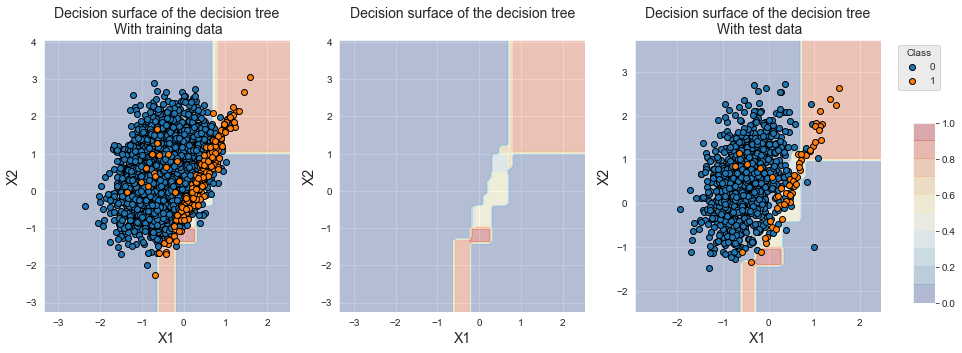

In [18]:
fig_decision_boundary

Let us now set the class weights so that false positives have a weight equal to the imbalance ratio.

In [19]:
IR=0.05/0.95

In [20]:
class_weight={0:IR,1:1}

In [21]:
# %%capture
# classifier = sklearn.tree.DecisionTreeClassifier(max_depth=5,class_weight=class_weight,random_state=0)
# 
# (results_df_dt_cost_sensitive, classifier_0, train_df, test_df) = kfold_cv_with_classifier(classifier, 
#                                                                          X, y, 
#                                                                          n_splits=5,
#                                                                          strategy_name="Decision tree - Cost-sensitive")
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)


In [22]:
pd.concat([results_df_dt_baseline, 
           results_df_dt_cost_sensitive])

,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Decision tree - Baseline,0.007+/-0.003,0.006+/-0.002,0.906+/-0.025,0.528+/-0.072,0.786+/-0.046
Decision tree - Cost-sensitive,0.007+/-0.002,0.006+/-0.001,0.887+/-0.034,0.471+/-0.059,0.898+/-0.021


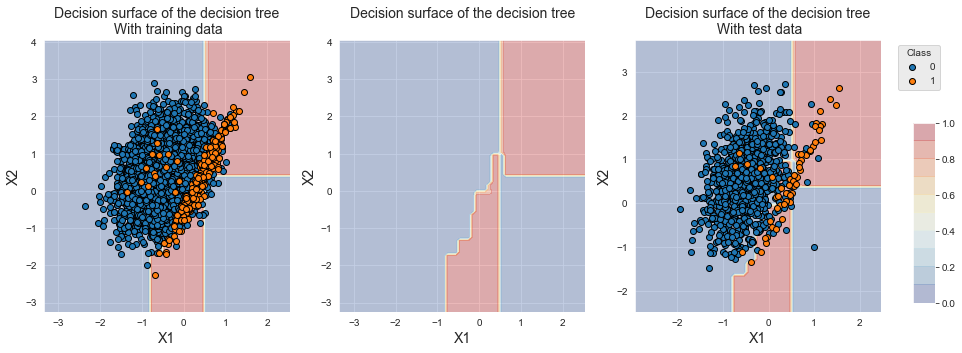

In [23]:
fig_decision_boundary

We observe that the decision boundary was shifted towards samples from the minority class. This shift allowed to increase the performance in terms of balanced accuracy, which increased from 0.786+/-0.046 to 0.898+/-0.021. We note however that the performances in terms of AUC ROC and Average Precision both decreased. 

### Logistic regression

Let us now apply the same methodology with a logistic regression classifier. We first build a classifier with equal weights for the two classes and run a stratified 5-fold cross-validation.

In [24]:
# %%capture
# classifier = sklearn.linear_model.LogisticRegression(C=1,class_weight={0:1,1:1},random_state=0)
# 
# (results_df_lr_baseline, classifier_0, train_df, test_df) = kfold_cv_with_classifier(classifier, 
#                                                                           X, y, 
#                                                                           n_splits=5,
#                                                                           strategy_name="Logistic regression - Baseline")
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)


In [25]:
results_df_lr_baseline

,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Logistic regression - Baseline,0.01+/-0.002,0.005+/-0.002,0.937+/-0.012,0.535+/-0.065,0.641+/-0.048


The performances in terms of AUC ROC and Average Precision are higher than with a decision tree, but lower in terms of balanced accuracy. 

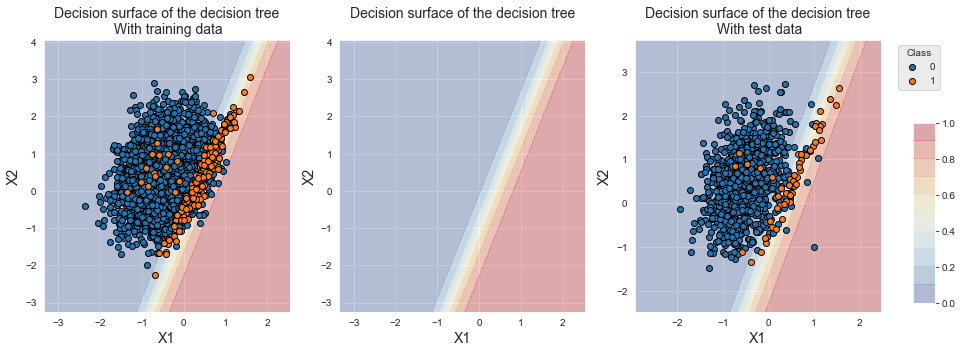

In [26]:
fig_decision_boundary

The decision boundary illustrates the linear separation that results from logistic regression. Due to the class imbalance, we observe that the decision boundary slightly favors the majority class. 

As for the decision tree, let us change the class weights, using the imbalance ratio as the weight for the majority class. 

In [27]:
# %%capture
# classifier = sklearn.linear_model.LogisticRegression(C=1,class_weight={0:IR,1:1},random_state=0)
# 
# (results_df_lr_cost_sensitive, classifier_0, train_df, test_df) = kfold_cv_with_classifier(classifier, 
#                                                                          X, y, 
#                                                                          n_splits=5,
#                                                                          strategy_name="Logistic regression - Cost-sensitive")
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)


In [28]:
pd.concat([results_df_lr_baseline, results_df_lr_cost_sensitive])

,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Logistic regression - Baseline,0.01+/-0.002,0.005+/-0.002,0.937+/-0.012,0.535+/-0.065,0.641+/-0.048
Logistic regression - Cost-sensitive,0.008+/-0.002,0.004+/-0.001,0.937+/-0.012,0.536+/-0.064,0.899+/-0.01


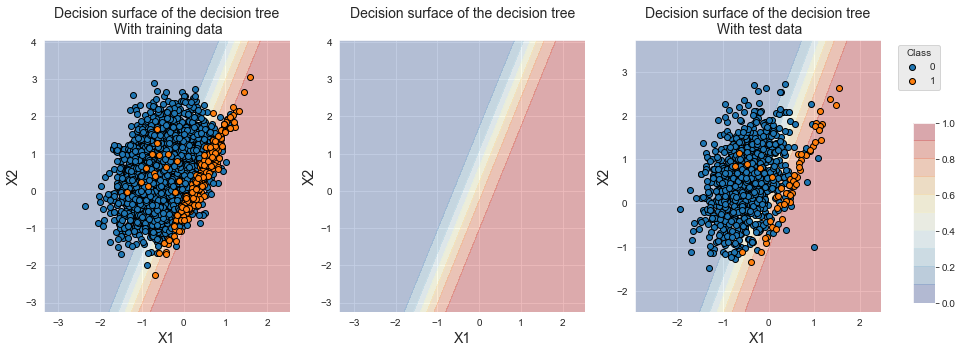

In [29]:
fig_decision_boundary

We observe that the decision boundary moved to the left, favoring the classification of the minority class. We note a strong increase of the balanced accuracy, from 0.641+/-0.048 to 0.899+/-0.01. The AUC ROC and Average Precision remain as good as the classifier with equal weights. 

The examples above show that tuning the class weights can improve classification performances. It is however worth noting that the performance improvements depend on the performance metric. For both classifiers, reducing the class weight of the majority class allowed to increase the balanced accuracy. The accuracy in terms of AUC ROC and Average Precision however remained unchanged for logistic regression and decreased for decision trees. 

In [30]:
results_df = pd.concat([results_df_dt_baseline,
                        results_df_dt_cost_sensitive,
                        results_df_lr_baseline,
                        results_df_lr_cost_sensitive])
results_df

,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Decision tree - Baseline,0.007+/-0.003,0.006+/-0.002,0.906+/-0.025,0.528+/-0.072,0.786+/-0.046
Decision tree - Cost-sensitive,0.007+/-0.002,0.006+/-0.001,0.887+/-0.034,0.471+/-0.059,0.898+/-0.021
Logistic regression - Baseline,0.01+/-0.002,0.005+/-0.002,0.937+/-0.012,0.535+/-0.065,0.641+/-0.048
Logistic regression - Cost-sensitive,0.008+/-0.002,0.004+/-0.001,0.937+/-0.012,0.536+/-0.064,0.899+/-0.01


(Cost_Sensitive_Learning_Transaction_Data)=
## Transaction data

Let us now explore whether changing the class weights can improve the classification performances on the simulated dataset of transaction data. We reuse the methodology of [Chapter 5, Model Selection](Model_Selection), using prequential validation as the validation strategy. 


### Load data

The loading of data and initialization of the parameters follow the same template as in [Chapter 5, Model Selection](Model_Selection).

In [31]:
# Load data from the 2018-07-11 to the 2018-09-14

DIR_INPUT = 'simulated-data-transformed/data/' 

BEGIN_DATE = "2018-06-11"
END_DATE = "2018-09-14"

print("Load  files")
%time transactions_df = read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))


# Number of folds for the prequential validation
n_folds = 4

# Set the starting day for the training period, and the deltas
start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train = delta_delay = delta_test = delta_valid = delta_assessment = 7

start_date_training_for_valid = start_date_training+datetime.timedelta(days=-(delta_delay+delta_valid))
start_date_training_for_test = start_date_training+datetime.timedelta(days=(n_folds-1)*delta_test)

output_feature = "TX_FRAUD"

input_features = ['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']


# Only keep columns that are needed as argument to the custom scoring function
# (in order to reduce the serialization time of transaction dataset)
transactions_df_scorer = transactions_df[['CUSTOMER_ID', 'TX_FRAUD','TX_TIME_DAYS']]

card_precision_top_100 = sklearn.metrics.make_scorer(card_precision_top_k_custom, 
                                                     needs_proba=True, 
                                                     top_k=100, 
                                                     transactions_df=transactions_df_scorer)

performance_metrics_list_grid = ['roc_auc', 'average_precision', 'card_precision@100']
performance_metrics_list = ['AUC ROC', 'Average precision', 'Card Precision@100']

scoring = {'roc_auc':'roc_auc',
           'average_precision': 'average_precision',
           'card_precision@100': card_precision_top_100,
           }


Load  files
CPU times: user 724 ms, sys: 569 ms, total: 1.29 s
Wall time: 1.41 s
919767 transactions loaded, containing 8195 fraudulent transactions


### Decision tree

The transaction dataset contains around 0.7% of fraudulent transactions. The imbalance ratio is therefore around 1/100. In order to assess the impact of the class weight parameter on the classification performance, we vary the class weight in the range 0.01 to 1, with the following set of possible values: $[0.01, 0.05, 0.1, 0.5, 1]$. 

The implementation is the same as in [Chapter 5](Model_Selection_Decision_Tree). The only modification consists in varying the class weight parameter (`clf__class_weight`) instead of the decision tree depth. We use a decision tree depth of 5 (`clf__max_depth`). 


In [32]:
# Define classifier
classifier = sklearn.tree.DecisionTreeClassifier()

# Set of parameters for which to assess model performances
parameters = {'clf__max_depth':[5], 'clf__random_state':[0],
              'clf__class_weight':[{0: w} for w in [0.01, 0.05, 0.1, 0.5, 1]]}

start_time = time.time()

# Fit models and assess performances for all parameters
performances_df = model_selection_wrapper(transactions_df, classifier, 
                                          input_features, output_feature,
                                          parameters, scoring, 
                                          start_date_training_for_valid,
                                          start_date_training_for_test,
                                          n_folds=n_folds,
                                          delta_train=delta_train, 
                                          delta_delay=delta_delay, 
                                          delta_assessment=delta_assessment,
                                          performance_metrics_list_grid=performance_metrics_list_grid,
                                          performance_metrics_list=performance_metrics_list,
                                          n_jobs=1)

execution_time_dt = time.time()-start_time



Let us use the class weight as the varying parameter, and summarize the performances as a function of the class weight.

In [33]:
# Select parameter of interest (class_weight)
parameters_dict = dict(performances_df['Parameters'])
performances_df['Parameters summary'] = [parameters_dict[i]['clf__class_weight'][0] for i in range(len(parameters_dict))]

# Rename to performances_df_dt for model performance comparison at the end of this notebook
performances_df_dt = performances_df


In [34]:
performances_df_dt

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.825500,0.009464,0.537440,0.033668,0.289286,0.010903,"{'clf__class_weight': {0: 0.01}, 'clf__max_dep...",0.555497,0.837454,0.014356,0.532924,0.025252,0.277500,0.010944,0.01
1,0.792912,0.029734,0.561153,0.046031,0.273571,0.019418,"{'clf__class_weight': {0: 0.05}, 'clf__max_dep...",0.505740,0.808213,0.022140,0.565880,0.027737,0.266071,0.013716,0.05
2,0.784486,0.031698,0.556320,0.031025,0.272143,0.019548,"{'clf__class_weight': {0: 0.1}, 'clf__max_dept...",0.718678,0.814153,0.023492,0.572758,0.029783,0.269643,0.015791,0.10
3,0.798043,0.020988,0.579394,0.016007,0.278214,0.003093,"{'clf__class_weight': {0: 0.5}, 'clf__max_dept...",0.622862,0.799682,0.013524,0.568408,0.018631,0.265000,0.013420,0.50
4,0.810138,0.008586,0.600306,0.016797,0.284286,0.004286,"{'clf__class_weight': {0: 1}, 'clf__max_depth'...",0.626287,0.804218,0.016505,0.546094,0.042197,0.267857,0.013869,1.00


In [35]:
summary_performances_dt = get_summary_performances(performances_df_dt, parameter_column_name="Parameters summary")
summary_performances_dt

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,0.01,0.1,0.01
Validation performance,0.837+/-0.01,0.573+/-0.03,0.278+/-0.01
Test performance,0.825+/-0.01,0.556+/-0.03,0.289+/-0.01
Optimal parameter(s),0.01,1.0,0.01
Optimal test performance,0.825+/-0.01,0.6+/-0.02,0.289+/-0.01


We observe that the optimal class weight for the majority class depends on the performance metric. For better visualization, let us plot the performances as a function of the class weight for the three performance metrics. 

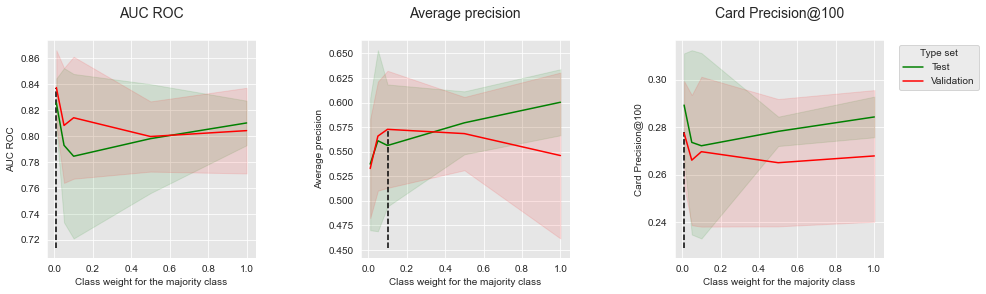

In [36]:
get_performances_plots(performances_df_dt, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Class weight for the majority class",
                       summary_performances=summary_performances_dt)

The results are mitigated, showing conflicting trends between the class weight of the majority class and the performance gains. For AUC ROC and CP@100, a class weight close to the imbalance ratio (0.01) provides the highest performance for both the test set and validation set, but the lowest performance in terms of Average Precision. 

### Logistic regression

Let us follow the same methodology as above, using logistic regression as the classification algorithm.

In [37]:
# Define classifier
classifier = sklearn.linear_model.LogisticRegression()

# Set of parameters for which to assess model performances
parameters = {'clf__C':[1], 'clf__random_state':[0],
              'clf__class_weight':[{0: w} for w in [0.01, 0.05, 0.1, 0.5, 1]]}

start_time = time.time()

# Fit models and assess performances for all parameters
performances_df = model_selection_wrapper(transactions_df, classifier, 
                                          input_features, output_feature,
                                          parameters, scoring, 
                                          start_date_training_for_valid,
                                          start_date_training_for_test,
                                          n_folds=n_folds,
                                          delta_train=delta_train, 
                                          delta_delay=delta_delay, 
                                          delta_assessment=delta_assessment,
                                          performance_metrics_list_grid=performance_metrics_list_grid,
                                          performance_metrics_list=performance_metrics_list,
                                          n_jobs=1)

execution_time_lr = time.time()-start_time



In [38]:
# Select parameter of interest (class_weight)
parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[parameters_dict[i]['clf__class_weight'][0] for i in range(len(parameters_dict))]

# Rename to performances_df_dt for model performance comparison at the end of this notebook
performances_df_lr=performances_df


In [39]:
performances_df_lr

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.871396,0.017137,0.571129,0.028027,0.293929,0.010120,"{'clf__C': 1, 'clf__class_weight': {0: 0.01}, ...",0.587376,0.871069,0.009955,0.497808,0.039734,0.276429,0.013190,0.01
1,0.870711,0.016332,0.604805,0.015834,0.296786,0.009813,"{'clf__C': 1, 'clf__class_weight': {0: 0.05}, ...",0.609912,0.870584,0.008772,0.550617,0.029466,0.278571,0.015085,0.05
2,0.870083,0.016028,0.613923,0.014765,0.296429,0.008950,"{'clf__C': 1, 'clf__class_weight': {0: 0.1}, '...",0.515544,0.869906,0.008720,0.579392,0.019886,0.278214,0.014156,0.10
3,0.868234,0.015572,0.621852,0.015687,0.297500,0.008770,"{'clf__C': 1, 'clf__class_weight': {0: 0.5}, '...",0.712305,0.867853,0.008948,0.608950,0.023132,0.277143,0.015286,0.50
4,0.867643,0.015404,0.623081,0.016204,0.297143,0.008806,"{'clf__C': 1, 'clf__class_weight': {0: 1}, 'cl...",0.576240,0.866861,0.008988,0.612264,0.023474,0.278214,0.016914,1.00


In [40]:
summary_performances_lr = get_summary_performances(performances_df_lr, parameter_column_name="Parameters summary")
summary_performances_lr

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,0.01,1.0,0.05
Validation performance,0.871+/-0.01,0.612+/-0.02,0.279+/-0.02
Test performance,0.871+/-0.02,0.623+/-0.02,0.297+/-0.01
Optimal parameter(s),0.01,1.0,0.5
Optimal test performance,0.871+/-0.02,0.623+/-0.02,0.298+/-0.01


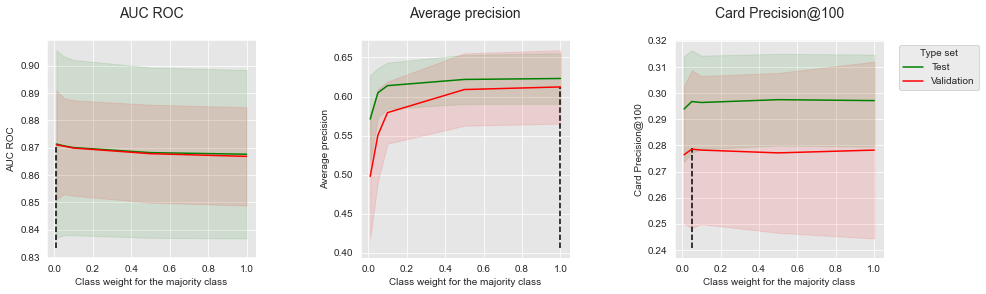

In [41]:
get_performances_plots(performances_df_lr, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Class weight for the majority class",
                       summary_performances=summary_performances_lr)

Similar to decision trees, the results are mitigated. Slightly higher performances are obtained for AUC ROC with a low class weight for the majority class. The performances in terms Average Precision and CP@100 however follow the opposite trend. 

## Summary

The benefits of relying on misclassification costs in the training procedure therefore appear to be strongly dependent on the characteristics of a dataset and on the performance metric to optimize. The experiments provided in this section showed that cost-sensitive learning effectively allows to shift the decision boundary of a classifier and to favor the classification of the minority class. Its benefits in terms of AUC ROC and Average Precision seem however conflicting. In particular, the shift of the decision boundary seems to lead to many false positives, that negatively impact the precision, and therefore, the performance in terms of Average Precision.   


## Saving of results

Let us finally save the performance results and execution times.

In [42]:
performances_df_dictionary = {
    "Decision Tree": performances_df_dt,
    "Logistic Regression": performances_df_lr
}

execution_times = [execution_time_dt,
                   execution_time_lr
                  ]


Both data structures are saved as a Pickle file.

In [ ]:
filehandler = open('performances_cost_sensitive.pkl', 'wb') 
pickle.dump((performances_df_dictionary, execution_times), filehandler)
filehandler.close()


---

## Ensembling


(Ensembling_Strategies)=
# Ensemble methods

Ensemble methods consist in training multiple prediction models for the same prediction task, and in combining their outputs to make the final prediction {cite}`fernandez2018learning,haixiang2017learning,bontempi2021statistical`. Ensembles of models very often allow to provide better prediction performances than single models, since combining the predictions from multiple models usually allows to reduce the overfitting phenomenon. The prediction models making up an ensemble are referred to as *baseline learners*. Both the way with which the baseline learners are constructed and how their predictions are combined are key factors in the design of an ensemble {cite}`fernandez2018learning,bontempi2021statistical,friedman2001elements`.

Ensemble methods can be broadly divided into *parallel-based* and *iterative-based* ensembles {cite}`haixiang2017learning`. In parallel-based ensembles, each baseline learner is trained in parallel, using either a subset of the training data, a subset of the training features, or a combination of both. The two most popular techniques for parallel-based ensembles are *bagging* {cite}`breiman1996bagging` and *random forest* {cite}`breiman2001random`. In iterative-based ensembles, also referred to as *boosting* {cite}`friedman2001elements,freund1997decision`, the baseline classifiers are trained in sequence, with each learner in the sequence aiming at minimizing the prediction errors of the previous learner. The currently most widely-used implementations for boosting are XGBoost {cite}`chen2016xgboost`, CatBoost {cite}`dorogush2018catboost` and LightGBM {cite}`ke2017lightgbm`. 

The ability of ensemble methods to improve prediction performances was illustrated in the previous chapter (see Sections [](Model_Selection_Comparison_Performances) and [](Model_Selection_RWD_Comparison)). In particular, our experimental comparison showed that random forests and XGBoost allowed to significantly improve the AUC ROC and Average Precision compared to decision trees and logistic regression.

This section takes a more specific look at ensemble methods in the context of imbalanced data. A common strategy when dealing with ensembles and imbalanced data is to use a different sampling of the training set for the training of the baseline learners. The procedure is illustrated in Fig. 1 for parallel-based ensembles. A first stage of resampling may aim at rebalancing samples by either oversampling the minority class, undersampling the majority class, or both. In a second stage, the number of features may also be sampled before proceeding to the training of baseline learners {cite}`haixiang2017learning,fernandez2018learning`.  

![alt text](images/parallel_based_framework.png)
```{div} caption-figure 
Fig. 1. Parallel-based framework in the context of imbalanced data. Sampling strategies may be applied at the level of samples or features (or both) before training the baseline classifiers {cite}`haixiang2017learning`. 
```

[Cost-sensitive learning techniques](Cost_Sensitive_Learning) may also be used together with resampling techniques by weighting the classes during the training of the baseline learners. Ensemble methods therefore provide a very flexible framework, where all of the techniques presented in the two previous sections can be used, but also combined with different types of baseline learners. 

The diversity of possible approaches is illustrated in this section by discussing three different ensemble methods for imbalanced learning: Balanced bagging {cite}`maclin1997empirical`, balanced random forest {cite}`chen2004using`, and weighted XGBoost {cite}`chen2016xgboost`.  


In [1]:
# Initialization: Load shared functions and simulated data 

# Load shared functions
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py
#%run ../Chapter_References/shared_functions.ipynb

# Get simulated data from Github repository
if not os.path.exists("simulated-data-transformed"):
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-transformed
   

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 63060  100 63060    0     0   144k      0 --:--:-- --:--:-- --:--:--  145k


## Illustrative example

Let us first consider the simple classification task presented in [the previous section](Imbalanced_Learning_Illustrative_Example).

In [2]:
X, y = sklearn.datasets.make_classification(n_samples=5000, n_features=2, n_informative=2,
                                            n_redundant=0, n_repeated=0, n_classes=2,
                                            n_clusters_per_class=1,
                                            weights=[0.95, 0.05],
                                            class_sep=0.5, random_state=0)

dataset_df = pd.DataFrame({'X1':X[:,0],'X2':X[:,1], 'Y':y})


In [3]:
# %%capture
# fig_distribution, ax = plt.subplots(1, 1, figsize=(5,5))
# 
# groups = dataset_df.groupby('Y')
# for name, group in groups:
#     ax.scatter(group.X1, group.X2, edgecolors='k', label=name,alpha=1,marker='o')
#     
# ax.legend(loc='upper left', 
#           bbox_to_anchor=(1.05, 1),
#           title="Class")

The dataset contains 5000 samples with two classes, labeled 0 and 1. 95% of the samples are associated to the class 0, and 5% of the samples to the class 1. 

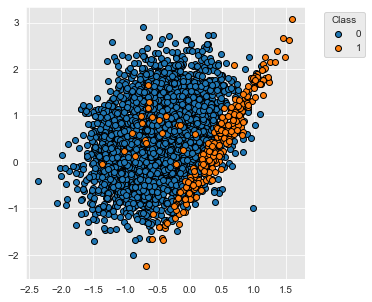

In [4]:
fig_distribution


### Bagging

Bagging relies on the concept of *bootstrap aggregating*, which consists of training several baseline learners with different replicas of the original training set {cite}`breiman1996bagging`. The most usual practice is to randomly draw, with replacement, instances from the original dataset. The dataset size is maintained, meaning that approximately 63.2% of the instances are present in each sample (and some instances appear more than once) {cite}`fernandez2018learning`.

The standard Python implementation for bagging is provided as part of the `sklearn` library, with the [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html#sklearn.ensemble.BaggingClassifier) object. Following the same methodology as in the previous sections, let us train a bagging classifier, assess its performances, and plot the resulting decision boundary. We use for this example decision trees of depth 5 as the baseline learners, and build an ensemble of 100 trees.  

In [5]:
# %%capture
# classifier = sklearn.ensemble.BaggingClassifier(base_estimator=sklearn.tree.DecisionTreeClassifier(max_depth=5,random_state=0),
#                                                 n_estimators=100,
#                                                 bootstrap=True,
#                                                 random_state=0)
# 
# 
# (results_df_bagging, classifier_0, train_df, test_df) = kfold_cv_with_classifier(classifier, 
#                                                                                  X, y, 
#                                                                                  n_splits=5,
#                                                                                  strategy_name="Bagging")
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)


In [6]:
results_df_bagging

,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Bagging,0.287+/-0.002,0.018+/-0.001,0.943+/-0.01,0.597+/-0.07,0.748+/-0.041


The classification performances of this bagging classifier are better than those of a single decision tree (see [baseline results in cost-sensitive larning](Imbalanced_Learning_Illustrative_Example)) for AUC ROC and Average Precision but lower in terms of balanced accuracy. 

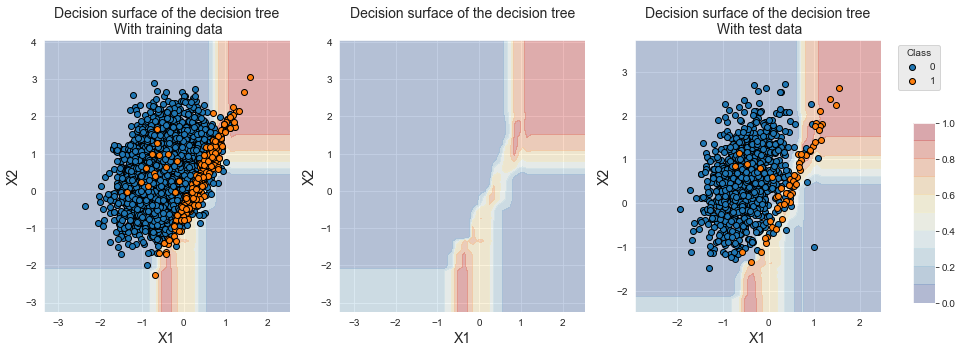

In [7]:
fig_decision_boundary

Compared to a single decision tree, the decision boundary is more refined. Most of the samples lying on the overlapping region are however classified into the majority class due to the imbalanced nature of the dataset.

#### Balanced Bagging

Balanced bagging {cite}`maclin1997empirical` follows the same strategy as bagging, except that the training data is resampled using imbalanced learning techniques. An implementation of balanced bagging is provided by the [`BalancedBaggingClassifier`](https://imbalanced-learn.org/dev/references/generated/imblearn.ensemble.BalancedBaggingClassifier.html) object of the `imblearn` library. The type of sampler and desired imbalance ratio are set with the `sampler` and `sampling_strategy` parameters, respectively. The default parameters consist of using a random undersampler and an imbalance ratio of 1, which means that samples from the majority class are randomly removed until their number equals that of the minority class (see Section [](Resampling_Strategies_Undersampling)). 

Let us train an ensemble of decision trees using a `BalancedBaggingClassifier` with its default parameters, and assess its performances and decision boundary. 

In [11]:
# %%capture
# classifier = imblearn.ensemble.BalancedBaggingClassifier(base_estimator=sklearn.tree.DecisionTreeClassifier(max_depth=5,random_state=0),
#                                                          n_estimators=100,
#                                                          sampling_strategy=1,
#                                                          bootstrap=True,
#                                                          sampler=imblearn.under_sampling.RandomUnderSampler(),
#                                                          random_state=0)
# 
# 
# (results_df_balanced_bagging, classifier_0, train_df, test_df) = kfold_cv_with_classifier(classifier, 
#                                                                                           X, y, 
#                                                                                           n_splits=5,
#                                                                                           strategy_name="Balanced bagging")
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)


In [13]:
pd.concat([results_df_bagging, 
           results_df_balanced_bagging])


,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Bagging,0.287+/-0.002,0.018+/-0.001,0.943+/-0.01,0.597+/-0.07,0.748+/-0.041
Balanced bagging,0.225+/-0.014,0.02+/-0.0,0.947+/-0.01,0.586+/-0.058,0.92+/-0.013


The resulting performances are similar to bagging in terms of AUC ROC and Average Precision. The balanced accuracy is however much higher with balanced bagging. This results from the shift of the decision boundary towards the region that contains the minority class, as is illustrated below. 

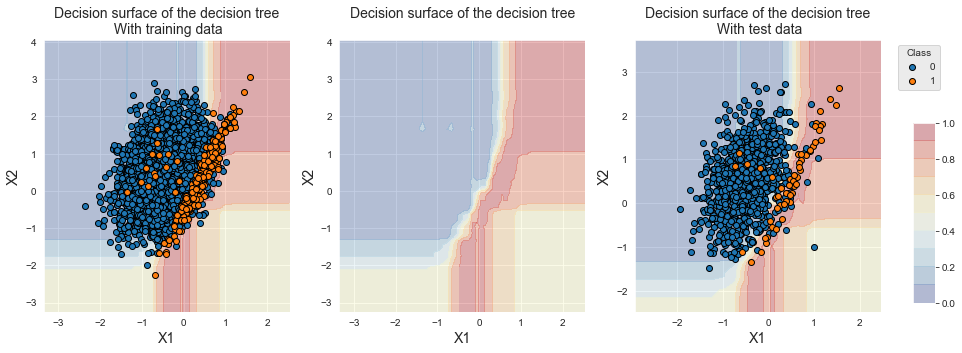

In [14]:
fig_decision_boundary

It is worth noting that the bottom right region is now associated with the minority class. This is due to the random undersampling, as was already observed in the [previous section](Resampling_Strategies_RUS) with a single decision tree.  

###  Random forest

Random forests were introduced by Breiman in 2001 {cite}`breiman2001random`. They have become one of the most popular ML technique for a wide range of prediction tasks among which fraud detection {cite}`priscilla2019credit,haixiang2017learning`. 

A random forest is an ensemble of decision trees, where each tree is built using a random subset of the training data. The method is therefore closely related to bagging. The main difference lies in the building of the decision trees, where splitting is done using only a random subset of the features. This additional random variation has beneficial consequences. First, it usually leads to better predictive performances thanks to a higher diversity in the tree structures, lower overfitting, and higher robustness to noise and outliers. Second, it also speeds up the computation times since fewer features are considered in the construction of the trees {cite}`breiman2001random`. 

The random forest procedure is provided in Python `sklearn` by the [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) object. The main parameters are the maximum tree depth and the number of trees, which are set with the `max_depth` and `n_estimators` parameters, respectively. 

Let us train a random forest classifier with 100 trees and a maximum depth of 5, and assess its performances and decision boundary. 

In [15]:
# %%capture
# classifier = sklearn.ensemble.RandomForestClassifier(n_estimators=100, 
#                                                      max_depth=5,
#                                                      random_state=0)
# 
# (results_df_rf, classifier_0, train_df, test_df) = kfold_cv_with_classifier(classifier, 
#                                                                             X, y, 
#                                                                             n_splits=5,
#                                                                             strategy_name="Random forest")
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)


In [16]:
pd.concat([results_df_bagging, 
           results_df_balanced_bagging,
           results_df_rf])


,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Bagging,0.287+/-0.002,0.018+/-0.001,0.943+/-0.01,0.597+/-0.07,0.748+/-0.041
Balanced bagging,0.225+/-0.014,0.02+/-0.0,0.947+/-0.01,0.586+/-0.058,0.92+/-0.013
Random forest,0.186+/-0.015,0.017+/-0.0,0.933+/-0.016,0.593+/-0.087,0.672+/-0.022


Performances in terms of AUC ROC and Average Precision are similar to bagging, and balanced accuracy slightly lower. The training time is significantly reduced.   

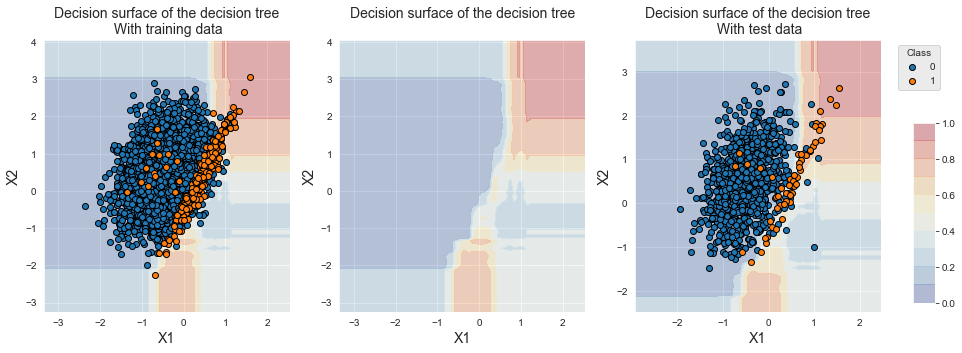

In [17]:
fig_decision_boundary

The decision boundary is also similar to what was obtained with bagging, which reflects the similarity between the two procedures. 

#### Balanced random forest

Balanced random forest was introduced in {cite}`chen2004using` in order to deal with imbalanced data. The procedure follows the same rationale as balanced bagging, and consists in building the baseline learners with balanced training sets. The procedure is implemented with the [`BalancedRandomForestClassifier`](https://imbalanced-learn.org/dev/references/generated/imblearn.ensemble.BalancedRandomForestClassifier.html) object of the Python `imblearn` library.

The `sampling_strategy` parameter determines the imbalance ratio of the training sets used to build the decision trees. Let us train a balanced random forest classifier with 100 trees, a maximum depth of 5, and an imbalance ratio of 1, and assess its performances and decision boundary. 

In [18]:
# %%capture
# classifier = imblearn.ensemble.BalancedRandomForestClassifier(n_estimators=100, 
#                                                               sampling_strategy=1,
#                                                               max_depth=5,
#                                                               random_state=0)
# 
# (results_df_rf_balanced, classifier_0, train_df, test_df) = kfold_cv_with_classifier(classifier, 
#                                                                                      X, y, 
#                                                                                      n_splits=5,
#                                                                                      strategy_name="Balanced random forest")
# 
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)


The resulting performances are on par with balanced bagging. 

In [19]:
pd.concat([results_df_bagging, 
           results_df_balanced_bagging,
           results_df_rf,
           results_df_rf_balanced])


,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Bagging,0.287+/-0.002,0.018+/-0.001,0.943+/-0.01,0.597+/-0.07,0.748+/-0.041
Balanced bagging,0.225+/-0.014,0.02+/-0.0,0.947+/-0.01,0.586+/-0.058,0.92+/-0.013
Random forest,0.186+/-0.015,0.017+/-0.0,0.933+/-0.016,0.593+/-0.087,0.672+/-0.022
Balanced random forest,0.19+/-0.014,0.018+/-0.0,0.946+/-0.01,0.58+/-0.083,0.916+/-0.014


We note that the training procedure is faster than balanced bagging.

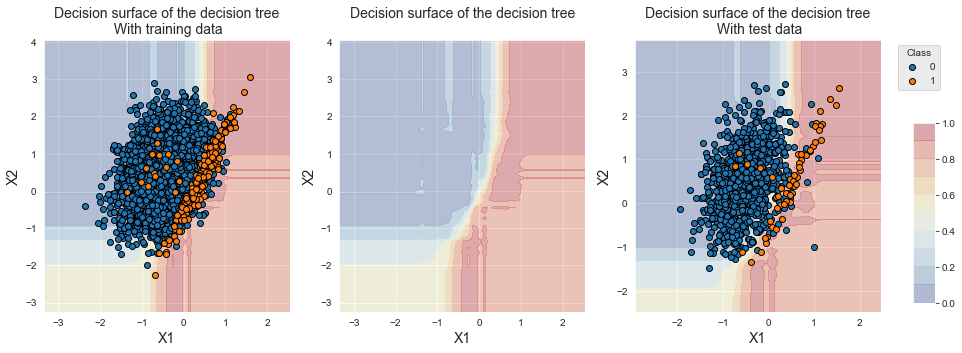

In [20]:
fig_decision_boundary

Similar to balanced bagging, we also note that the decision boundary is shifted towards the minority class and that the bottom right region is associated with the minority class.

### XGBoost

XGBoost stands for *extreme gradient boosting* and is one of the most efficient ensemble techniques in machine learning. It was shown to provide state-of-the-art results in a range of machine learning benchmarks as well as in Kaggle competitions {cite}`bentejac2021comparative,chen2016xgboost`. 

XGBoost provides a scalable implementation of gradient tree boosting {cite}`friedman2001greedy`. The implementation details go beyond the scope of this book, and we refer the reader to {cite}`chen2016xgboost` for the description of the algorithm and its optimization. 

The Python implementation is provided by the [`XGBClassifier`](https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.sklearn) object of the `XGBoost` library. XGBoost features many tuning parameters, the most important ones being the number of boosting rounds `n_estimators`, the maximum tree depth of the base learners `max_depth`, and the learning rate `learning rate`. 

Let us train an XGBoost classifier and assess its performances and decision boundary. We use in the following the default parameters, which consist of 100 boosting rounds, a maximum tree depth of 6, and a learning rate of 0.3.

In [21]:
# %%capture
# classifier = xgboost.XGBClassifier(n_estimators=100,
#                                    max_depth=6,
#                                    learning_rate=0.3,
#                                    random_state=0)
# 
# (results_df_xgboost, classifier_0, train_df, test_df) = kfold_cv_with_classifier(classifier, 
#                                                                                  X, y, 
#                                                                                  n_splits=5,
#                                                                                  strategy_name="XGBoost")
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)


The resulting classifier provides performances that are competitive with those obtained with bagging and random forest. 

In [22]:
pd.concat([results_df_bagging, 
           results_df_balanced_bagging,
           results_df_rf,
           results_df_rf_balanced,
           results_df_xgboost])


,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Bagging,0.287+/-0.002,0.018+/-0.001,0.943+/-0.01,0.597+/-0.07,0.748+/-0.041
Balanced bagging,0.225+/-0.014,0.02+/-0.0,0.947+/-0.01,0.586+/-0.058,0.92+/-0.013
Random forest,0.186+/-0.015,0.017+/-0.0,0.933+/-0.016,0.593+/-0.087,0.672+/-0.022
Balanced random forest,0.19+/-0.014,0.018+/-0.0,0.946+/-0.01,0.58+/-0.083,0.916+/-0.014
XGBoost,0.142+/-0.004,0.007+/-0.0,0.95+/-0.008,0.59+/-0.066,0.772+/-0.04


Let us plot the resulting decision boundary. 

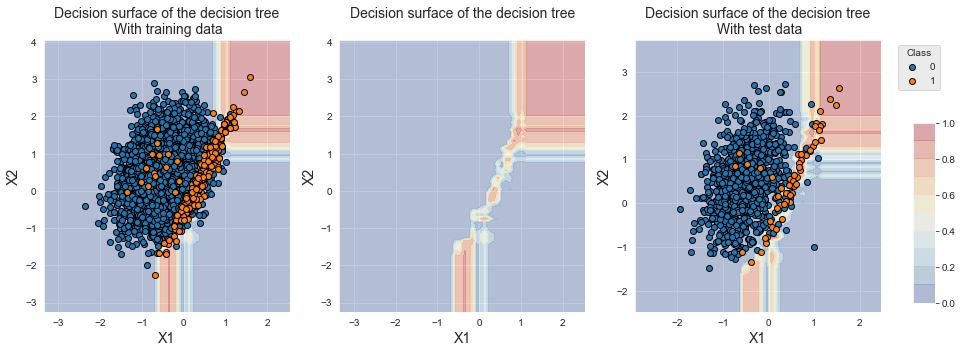

In [19]:
fig_decision_boundary

The decision boundary slightly differs from bagging and random forest. XGBoost more precisely isolates the region containing samples from the minority class.  

#### Weighted XGBoost

Cost-sensitive learning can be applied to XGBoost by means of the `scale_pos_weight` parameter. Assuming that the cost of a false positive is 1, the parameter determines the cost of a false negative. It is worth noting that this parameter is the only one to deal with imbalanced data using XGBoost: contrary to bagging and random forest, XGBoost cannot be combined with resampling techniques.   

Let us use the [imbalance ratio](IR=0.05/0.95 ) to set the class weight. Since there is 5% of samples from the minority class, and 95% of samples from the majority class, the imbalance ratio IR is:


In [20]:
IR=0.05/0.95 
IR

0.052631578947368425

Since `scale_pos_weight` quantifies the cost of a false negative, we set its value to the inverse of the imbalance ratio. 

In [21]:
# %%capture
# classifier = xgboost.XGBClassifier(n_estimators=100,
#                                    max_depth=6,
#                                    learning_rate=0.3,
#                                    scale_pos_weight=1/IR,
#                                    random_state=0)
# 
# (results_df_weighted_xgboost, classifier_0, train_df, test_df) = kfold_cv_with_classifier(classifier, 
#                                                                                           X, y, 
#                                                                                           n_splits=5,
#                                                                                           strategy_name="Weighted XGBoost")
# 
# fig_decision_boundary = plot_decision_boundary(classifier_0, train_df, test_df)


Compared to XGBoost, the weighing of false negative allows a slight increase in terms of Average Precision and balanced accuracy and a similar performance in terms of AUC ROC. We note that the balanced accuracy is lower than those obtained with balanced bagging and balanced random forest. 

In [22]:
pd.concat([results_df_bagging, 
           results_df_balanced_bagging,
           results_df_rf,
           results_df_rf_balanced,
           results_df_xgboost,
           results_df_weighted_xgboost])


,Fit time (s),Score time (s),AUC ROC,Average Precision,Balanced accuracy
Bagging,0.55+/-0.05,0.048+/-0.012,0.943+/-0.01,0.597+/-0.07,0.748+/-0.041
Balanced bagging,0.55+/-0.047,0.052+/-0.009,0.947+/-0.01,0.586+/-0.058,0.92+/-0.013
Random forest,0.334+/-0.045,0.04+/-0.002,0.933+/-0.016,0.593+/-0.087,0.672+/-0.022
Balanced random forest,0.445+/-0.081,0.043+/-0.012,0.946+/-0.01,0.58+/-0.083,0.916+/-0.014
XGBoost,0.343+/-0.038,0.013+/-0.002,0.95+/-0.008,0.59+/-0.066,0.772+/-0.04
Weighted XGBoost,0.363+/-0.052,0.01+/-0.001,0.946+/-0.012,0.598+/-0.061,0.855+/-0.021


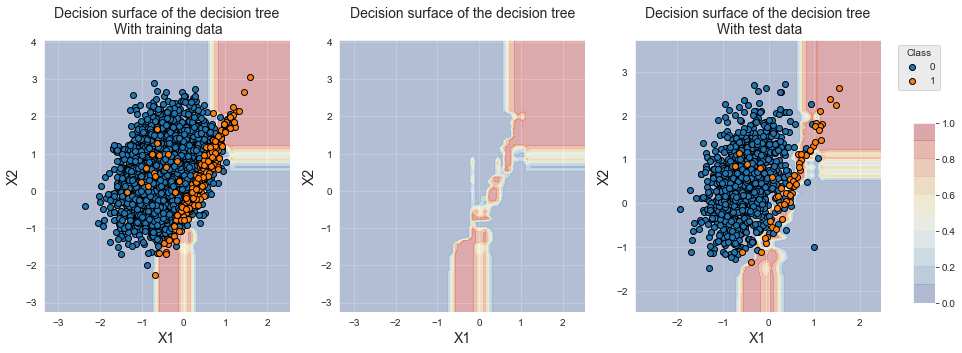

In [23]:
fig_decision_boundary

The decision boundary shows that a larger region is now associated with the minority class. Interestingly, XGBoost does not overfit as much as balanced bagging and balanced random forest. In particular, the bottom right region remains associated with the majority class. 

(Ensembling_Strategies_Transaction_Data)=
## Transaction data

Let us now apply these three ensemble techniques to the simulated dataset of transaction data. We reuse the methodology of [Chapter 5, Model Selection](Model_Selection), using prequential validation as the validation strategy.

### Load data

The loading of data and initialization of the parameters follow the same template as in [Chapter 5, Model Selection](Model_Selection).

In [24]:
# Load data from the 2018-07-11 to the 2018-09-14

DIR_INPUT = 'simulated-data-transformed/data/' 

BEGIN_DATE = "2018-06-11"
END_DATE = "2018-09-14"

print("Load  files")
%time transactions_df = read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))


# Number of folds for the prequential validation
n_folds = 4

# Set the starting day for the training period, and the deltas
start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train = delta_delay = delta_test = delta_valid = delta_assessment = 7

start_date_training_for_valid = start_date_training+datetime.timedelta(days=-(delta_delay+delta_valid))
start_date_training_for_test = start_date_training+datetime.timedelta(days=(n_folds-1)*delta_test)

output_feature = "TX_FRAUD"

input_features = ['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']


# Only keep columns that are needed as argument to the custom scoring function
# (in order to reduce the serialization time of transaction dataset)
transactions_df_scorer = transactions_df[['CUSTOMER_ID', 'TX_FRAUD','TX_TIME_DAYS']]

card_precision_top_100 = sklearn.metrics.make_scorer(card_precision_top_k_custom, 
                                                     needs_proba=True, 
                                                     top_k=100, 
                                                     transactions_df=transactions_df_scorer)

performance_metrics_list_grid = ['roc_auc', 'average_precision', 'card_precision@100']
performance_metrics_list = ['AUC ROC', 'Average precision', 'Card Precision@100']

scoring = {'roc_auc':'roc_auc',
           'average_precision': 'average_precision',
           'card_precision@100': card_precision_top_100,
           }



Load  files
CPU times: user 731 ms, sys: 526 ms, total: 1.26 s
Wall time: 1.31 s
919767 transactions loaded, containing 8195 fraudulent transactions


(Ensembling_Strategies_Transaction_Data_Baseline)=
### Baseline

Let us first assess the performances of bagging, random forest, and XGBoost without imbalanced learning techniques. We refer to these performances as *baseline* performances. 

The hyperparameters are chosen as follows:

* Bagging and random forest: 100 trees, with a maximum depth of 20. These were shown to provide the best performances for random forests in [Chapter 5, Model Selection - Random forest](Model_Selection_Random_Forest).
* XGBoost: 50 trees, with a maximum depth of 3, and a learning rate of 0.3. These were shown to provide the best trade-off in terms of performances in [Chapter 5, Model Selection - XGBoost](Model_Selection_XGBoost). 



In [25]:
#### Bagging
# Define classifier
classifier = sklearn.ensemble.BaggingClassifier()

# Set of parameters for which to assess model performances
parameters = {'clf__base_estimator':[sklearn.tree.DecisionTreeClassifier(max_depth=20,random_state=0)], 
              'clf__bootstrap':[True],
              'clf__n_estimators':[100],
              'clf__random_state':[0],
              'clf__n_jobs':[-1]}

start_time = time.time()

# Fit models and assess performances for all parameters
performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=-1)

execution_time_baseline_bagging = time.time()-start_time

# Select parameter of interest (n_estimators)
parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[parameters_dict[i]['clf__n_estimators'] for i in range(len(parameters_dict))]

# Rename to performances_df_baseline_bagging for model performance comparison later in this section
performances_df_baseline_bagging=performances_df

In [26]:
summary_performances_baseline_bagging=get_summary_performances(performances_df_baseline_bagging, parameter_column_name="Parameters summary")
summary_performances_baseline_bagging

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,100,100,100
Validation performance,0.872+/-0.01,0.704+/-0.01,0.284+/-0.01
Test performance,0.856+/-0.02,0.678+/-0.01,0.293+/-0.01
Optimal parameter(s),100,100,100
Optimal test performance,0.856+/-0.02,0.678+/-0.01,0.293+/-0.01


In [27]:
#### Random forest
# Define classifier
classifier = sklearn.ensemble.RandomForestClassifier()

parameters = {'clf__max_depth':[20], 
              'clf__n_estimators':[100],
              'clf__random_state':[0],
              'clf__n_jobs':[-1]}

start_time = time.time()

# Fit models and assess performances for all parameters
performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=-1)

execution_time_baseline_rf = time.time()-start_time

# Select parameter of interest (n_estimators)
parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[parameters_dict[i]['clf__n_estimators'] for i in range(len(parameters_dict))]

# Rename to performances_df_baseline_rf for model performance comparison later in this section
performances_df_baseline_rf=performances_df

In [28]:
summary_performances_baseline_rf=get_summary_performances(performances_df_baseline_rf, parameter_column_name="Parameters summary")
summary_performances_baseline_rf

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,100,100,100
Validation performance,0.88+/-0.01,0.694+/-0.02,0.289+/-0.02
Test performance,0.87+/-0.02,0.678+/-0.01,0.299+/-0.01
Optimal parameter(s),100,100,100
Optimal test performance,0.87+/-0.02,0.678+/-0.01,0.299+/-0.01


In [29]:
#### XGBoost
# Define classifier
classifier = xgboost.XGBClassifier()

parameters = {'clf__max_depth':[3], 
              'clf__n_estimators':[50],
              'clf__learning_rate':[0.3],
              'clf__random_state':[0],
              'clf__n_jobs':[-1]}

start_time = time.time()

# Fit models and assess performances for all parameters
performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=-1)

execution_time_baseline_xgboost = time.time()-start_time

# Select parameter of interest (n_estimators)
parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[parameters_dict[i]['clf__n_estimators'] for i in range(len(parameters_dict))]

# Rename to performances_df_baseline_xgboost for model performance comparison later in this section
performances_df_baseline_xgboost=performances_df

In [30]:
summary_performances_baseline_xgboost=get_summary_performances(performances_df_baseline_xgboost, parameter_column_name="Parameters summary")
summary_performances_baseline_xgboost

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,50,50,50
Validation performance,0.883+/-0.01,0.708+/-0.02,0.288+/-0.02
Test performance,0.872+/-0.01,0.687+/-0.01,0.302+/-0.01
Optimal parameter(s),50,50,50
Optimal test performance,0.872+/-0.01,0.687+/-0.01,0.302+/-0.01


The baseline performances are reported in the table below. It is worth noting that the performances for random forest and XGBoost are the same as those reported in [Chapter 5, Model Selection - Random forest](Model_Selection_Random_Forest) and [Chapter 5, Model Selection - XGBoost](Model_Selection_XGBoost), respectively.

In [31]:
summary_test_performances = pd.concat([summary_performances_baseline_bagging.iloc[2,:],
                                       summary_performances_baseline_rf.iloc[2,:],
                                       summary_performances_baseline_xgboost.iloc[2,:],
                                      ],axis=1)
summary_test_performances.columns=['Baseline Bagging', 'Baseline RF', 'Baseline XGBoost']
summary_test_performances

,Baseline Bagging,Baseline RF,Baseline XGBoost
AUC ROC,0.856+/-0.02,0.87+/-0.02,0.872+/-0.01
Average precision,0.678+/-0.01,0.678+/-0.01,0.687+/-0.01
Card Precision@100,0.293+/-0.01,0.299+/-0.01,0.302+/-0.01


XGBoost provides slightly higher Average Precision than random forest and bagging. Bagging provides slightly lower AUC ROC and CP@100 than random forest and XGBoost. Overall, the three ensemble strategies achieve similar performances.

(Ensembling_Strategies_Transaction_Data_Bagging)=
### Balanced bagging

Keeping the same hyperparameters as above (100 trees with a maximum depth of 20), let us assess the ability of balanced bagging to improve classification performances. We rely on random undersampling, which is the default sampler. The imbalance ratio (`sampling_strategy` parameter) is parametrized to take values in the set $[0.02, 0.05, 0.1, 0.5, 1]$ for the model selection procedure.    


In [32]:
# Define classifier
classifier = imblearn.ensemble.BalancedBaggingClassifier()

# Set of parameters for which to assess model performances
parameters = {'clf__base_estimator':[sklearn.tree.DecisionTreeClassifier(max_depth=20,random_state=0)], 
              'clf__n_estimators':[100],
              'clf__sampling_strategy':[0.02, 0.05, 0.1, 0.5, 1], 
              'clf__bootstrap':[True],
              'clf__sampler':[imblearn.under_sampling.RandomUnderSampler()],
              'clf__random_state':[0],
              'clf__n_jobs':[-1]}

start_time = time.time()

# Fit models and assess performances for all parameters
performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=1)

execution_time_balanced_bagging = time.time()-start_time



In [33]:
# Select parameter of interest (sampling_strategy)
parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[parameters_dict[i]['clf__sampling_strategy'] for i in range(len(parameters_dict))]

# Rename to performances_df_balanced_bagging for model performance comparison later in this section
performances_df_balanced_bagging=performances_df

In [34]:
performances_df_balanced_bagging

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.869210,0.020009,0.679963,0.011158,0.298571,0.010051,{'clf__base_estimator': DecisionTreeClassifier...,25.338472,0.875647,0.009589,0.704491,0.014563,0.287143,0.014604,0.02
1,0.875633,0.018670,0.679319,0.007153,0.301071,0.010369,{'clf__base_estimator': DecisionTreeClassifier...,9.595980,0.877413,0.008182,0.700732,0.017898,0.286786,0.015856,0.05
2,0.876615,0.016223,0.676736,0.008302,0.304643,0.010369,{'clf__base_estimator': DecisionTreeClassifier...,7.298806,0.878204,0.002966,0.699331,0.018432,0.289286,0.015698,0.10
3,0.878820,0.013479,0.652480,0.021308,0.305357,0.012387,{'clf__base_estimator': DecisionTreeClassifier...,3.528260,0.880359,0.004692,0.657772,0.022306,0.287857,0.017800,0.50
4,0.877182,0.013837,0.631045,0.029855,0.301786,0.012592,{'clf__base_estimator': DecisionTreeClassifier...,4.901024,0.877335,0.003365,0.643261,0.022129,0.289286,0.017098,1.00


Let us summarize the performances to highlight the optimal imbalance ratios.

In [35]:
summary_performances_balanced_bagging = get_summary_performances(performances_df_balanced_bagging, parameter_column_name="Parameters summary")
summary_performances_balanced_bagging

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,0.5,0.02,0.1
Validation performance,0.88+/-0.0,0.704+/-0.01,0.289+/-0.02
Test performance,0.879+/-0.01,0.68+/-0.01,0.305+/-0.01
Optimal parameter(s),0.5,0.02,0.5
Optimal test performance,0.879+/-0.01,0.68+/-0.01,0.305+/-0.01


We note conflicting results, as the optimal imbalance ratio depends on the performance metric. For better visualization, let us plot the performances as a function of the imbalance ratio for the three performance metrics.

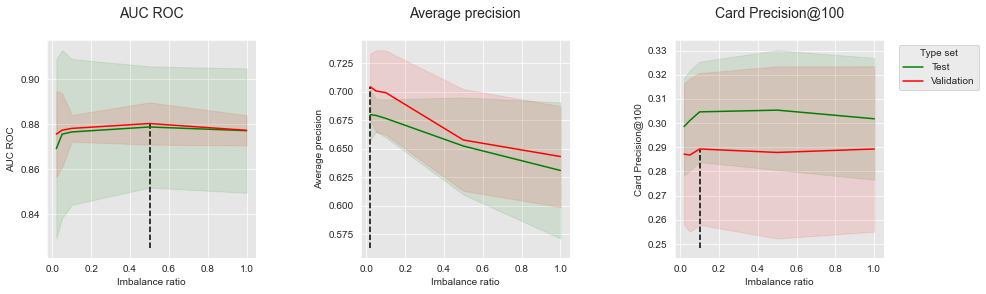

In [36]:
get_performances_plots(performances_df_balanced_bagging, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Imbalance ratio",
                       summary_performances=summary_performances_balanced_bagging)

Undersampling is clearly detrimental to the Average Precision, where increasing the imbalance ratio leads to a decrease in performance. The highest Average Precision is obtained for an imbalance ratio of 0.02 which is the imbalance ratio of the transaction dataset. A different trend is observed for AUC ROC and CP@100 where increasing the imbalance ratio first leads to better performances, before reaching some optimum after which performances decrease. In this experiment, an imbalance ratio of 0.5 is found to be optimal for AUC ROC, while an imbalance ratio of 0.1 provides the best result in terms of CP@100.

Let us finally compare the performances achieved with bagging and balanced bagging. 

In [37]:
summary_test_performances = pd.concat([summary_performances_baseline_bagging.iloc[2,:],
                                       summary_performances_balanced_bagging.iloc[2,:]
                                      ],axis=1)
summary_test_performances.columns=['Baseline Bagging', 'Balanced Bagging']
summary_test_performances

,Baseline Bagging,Balanced Bagging
AUC ROC,0.856+/-0.02,0.879+/-0.01
Average precision,0.678+/-0.01,0.68+/-0.01
Card Precision@100,0.293+/-0.01,0.305+/-0.01


As noted above, balanced bagging allows to improve both AUC ROC and CP@100, but does not appear to improve the Average Precision. 

(Ensembling_Strategies_Transaction_Data_RF)=
### Balanced Random Forest

The same methodology is applied with balanced random forest. The imbalance ratio (`sampling_strategy` parameter) is parametrized to take values in the set $[0.01, 0.05, 0.1, 0.5, 1]$ for the model selection procedure.    


In [38]:
# Define classifier
classifier = imblearn.ensemble.BalancedRandomForestClassifier()

parameters = {'clf__max_depth':[20], 
              'clf__n_estimators':[100],
              'clf__sampling_strategy':[0.01, 0.05, 0.1, 0.5, 1], 
              'clf__random_state':[0],
              'clf__n_jobs':[-1]}

start_time = time.time()

# Fit models and assess performances for all parameters
performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=-1)

execution_time_rf_balanced = time.time()-start_time



In [39]:
# Select parameter of interest (sampling_strategy)
parameters_dict = dict(performances_df['Parameters'])
performances_df['Parameters summary'] = [parameters_dict[i]['clf__sampling_strategy'] for i in range(len(parameters_dict))]

# Rename to performances_df_balanced_rf for model performance comparison later in this section
performances_df_balanced_rf=performances_df

In [40]:
performances_df_balanced_rf

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.870357,0.016188,0.676942,0.008811,0.303929,0.011534,"{'clf__max_depth': 20, 'clf__n_estimators': 10...",34.225113,0.880145,0.008573,0.694636,0.019742,0.287857,0.015600,0.01
1,0.872143,0.021075,0.658319,0.017522,0.302500,0.011797,"{'clf__max_depth': 20, 'clf__n_estimators': 10...",8.284223,0.881513,0.002490,0.672938,0.024907,0.290714,0.017971,0.05
2,0.874943,0.016199,0.639242,0.026416,0.302500,0.013716,"{'clf__max_depth': 20, 'clf__n_estimators': 10...",6.776770,0.878352,0.001225,0.659061,0.023005,0.290000,0.016382,0.10
3,0.875914,0.014254,0.601545,0.029253,0.302143,0.013609,"{'clf__max_depth': 20, 'clf__n_estimators': 10...",5.092815,0.879629,0.004810,0.602540,0.022916,0.288929,0.015952,0.50
4,0.871298,0.011698,0.571147,0.032975,0.299643,0.013147,"{'clf__max_depth': 20, 'clf__n_estimators': 10...",5.182013,0.872742,0.005465,0.566056,0.032686,0.279643,0.016732,1.00


Let us summarize the performances to highlight the optimal imbalance ratio, and plot the performances as a function of the imbalance ratio for the three performance metrics.

In [41]:
summary_performances_balanced_rf=get_summary_performances(performances_df=performances_df_balanced_rf, parameter_column_name="Parameters summary")
summary_performances_balanced_rf

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,0.05,0.01,0.05
Validation performance,0.882+/-0.0,0.695+/-0.02,0.291+/-0.02
Test performance,0.872+/-0.02,0.677+/-0.01,0.302+/-0.01
Optimal parameter(s),0.5,0.01,0.01
Optimal test performance,0.876+/-0.01,0.677+/-0.01,0.304+/-0.01


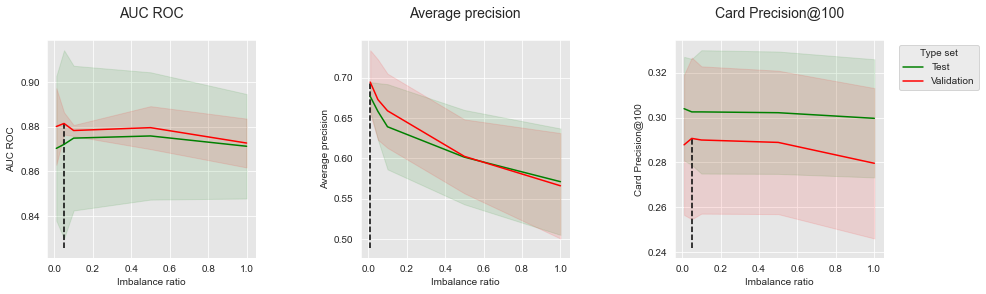

In [42]:
get_performances_plots(performances_df_balanced_rf, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Imbalance ratio",
                       summary_performances=summary_performances_balanced_rf)

The results are qualitatively similar to balanced bagging. Increasing the imbalance ratio is detrimental to Average Precision, but can lead to marginal performance improvements for AUC ROC and CP@100. The optimum is found for an imbalance ratio of 0.05. 

Let us finally compare the performances achieved with random forest and balanced random forest. 

In [43]:
summary_test_performances = pd.concat([summary_performances_baseline_rf.iloc[2,:],
                                       summary_performances_balanced_rf.iloc[2,:]
                                      ],axis=1)
summary_test_performances.columns=['Baseline RF', 'Balanced RF']
summary_test_performances

,Baseline RF,Balanced RF
AUC ROC,0.87+/-0.02,0.872+/-0.02
Average precision,0.678+/-0.01,0.677+/-0.01
Card Precision@100,0.299+/-0.01,0.302+/-0.01


The performance increase in terms of AUC ROC and CP@100 is only marginal. Overall, the balanced random forest did not allow to improve performances.

(Ensembling_Strategies_Transaction_Data_Weighted_XGBoost)=
### Weighted XGBoost

For weighted XGBoost, the class weight is set with the `scale_pos_weight` parameter. Keeping the same hyperparameters as the baseline XGBoost (50 trees with a maximum depth of 3, and a learning rate of 0.3), we vary the `scale_pos_weight` parameter to take values in the set $[1,5,10,50,100]$. 

In [44]:
classifier = xgboost.XGBClassifier()

parameters = {'clf__max_depth':[3], 
              'clf__n_estimators':[50],
              'clf__learning_rate':[0.3],
              'clf__scale_pos_weight':[1,5,10,50,100], 
              'clf__random_state':[0],
              'clf__n_jobs':[-1]}

start_time = time.time()

# Fit models and assess performances for all parameters
performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=-1)

execution_time_weighted_xgboost = time.time()-start_time


In [45]:
# Select parameter of interest (scale_pos_weight)
parameters_dict = dict(performances_df['Parameters'])
performances_df['Parameters summary'] = [parameters_dict[i]['clf__scale_pos_weight'] for i in range(len(parameters_dict))]

# Rename to performances_df_weighted_xgboost for model performance comparison later in this section
performances_df_weighted_xgboost=performances_df

In [46]:
performances_df_weighted_xgboost

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.871726,0.010990,0.686534,0.011086,0.302143,0.013458,"{'clf__learning_rate': 0.3, 'clf__max_depth': ...",6.617693,0.882839,0.008380,0.708226,0.020697,0.287500,0.016331,1
1,0.866154,0.008993,0.667997,0.004161,0.300000,0.010351,"{'clf__learning_rate': 0.3, 'clf__max_depth': ...",6.618995,0.882704,0.010765,0.697100,0.021795,0.288571,0.013477,5
2,0.865940,0.008009,0.667121,0.007867,0.298214,0.008534,"{'clf__learning_rate': 0.3, 'clf__max_depth': ...",7.350666,0.880610,0.005834,0.691400,0.018352,0.287500,0.014996,10
3,0.863178,0.007149,0.648028,0.012585,0.296429,0.011316,"{'clf__learning_rate': 0.3, 'clf__max_depth': ...",6.550463,0.882049,0.011948,0.677362,0.021367,0.284643,0.014406,50
4,0.858011,0.006991,0.630036,0.020288,0.292143,0.015403,"{'clf__learning_rate': 0.3, 'clf__max_depth': ...",6.716424,0.880666,0.012492,0.661458,0.020015,0.285000,0.016736,100


Let us summarize the performances to highlight the optimal class weights, and plot the performances as a function of the class weight for the three performance metrics.

In [47]:
summary_performances_weighted_xgboost=get_summary_performances(performances_df=performances_df_weighted_xgboost, parameter_column_name="Parameters summary")
summary_performances_weighted_xgboost

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,1,1,5
Validation performance,0.883+/-0.01,0.708+/-0.02,0.289+/-0.01
Test performance,0.872+/-0.01,0.687+/-0.01,0.3+/-0.01
Optimal parameter(s),1,1,1
Optimal test performance,0.872+/-0.01,0.687+/-0.01,0.302+/-0.01


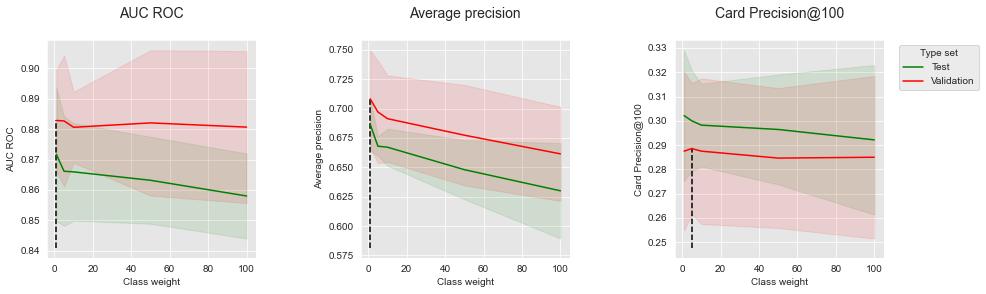

In [48]:
get_performances_plots(performances_df_weighted_xgboost, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Class weight",
                       summary_performances=summary_performances_weighted_xgboost)

The results show that for all metrics, increasing the class weight leads to a decrease in performances on the test set. The best class weight is therefore 1, that is, an equal weight for the minority and the majority class. 

In [49]:
summary_test_performances = pd.concat([summary_performances_baseline_xgboost.iloc[2,:],
                                       summary_performances_weighted_xgboost.iloc[2,:]
                                      ],axis=1)
summary_test_performances.columns=['Baseline XGBoost', 'Weighted XGBoost']
summary_test_performances

,Baseline XGBoost,Weighted XGBoost
AUC ROC,0.872+/-0.01,0.872+/-0.01
Average precision,0.687+/-0.01,0.687+/-0.01
Card Precision@100,0.302+/-0.01,0.3+/-0.01


The performances obtained with weighted XGBoost are therefore the same as those obtained with our baseline.   

(Ensembling_Strategies_Transaction_Data_Summary)=
## Summary 

Let us finally summarize in a single table the results on the dataset of simulated transactions. Performance metrics are reported row-wise, while ensemble methods are reported column-wise. 

In [50]:
summary_test_performances = pd.concat([summary_performances_baseline_bagging.iloc[2,:],
                                       summary_performances_balanced_bagging.iloc[2,:],
                                       summary_performances_baseline_rf.iloc[2,:],
                                       summary_performances_balanced_rf.iloc[2,:],
                                       summary_performances_baseline_xgboost.iloc[2,:],
                                       summary_performances_weighted_xgboost.iloc[2,:],
                                      ],axis=1)
summary_test_performances.columns=['Baseline Bagging', 'Balanced Bagging', 
                                   'Baseline RF', 'Balanced RF', 
                                   'Baseline XGBoost', 'Weighted XGBoost']


In [51]:
summary_test_performances

,Baseline Bagging,Balanced Bagging,Baseline RF,Balanced RF,Baseline XGBoost,Weighted XGBoost
AUC ROC,0.856+/-0.02,0.879+/-0.01,0.87+/-0.02,0.872+/-0.02,0.872+/-0.01,0.872+/-0.01
Average precision,0.678+/-0.01,0.68+/-0.01,0.678+/-0.01,0.677+/-0.01,0.687+/-0.01,0.687+/-0.01
Card Precision@100,0.293+/-0.01,0.305+/-0.01,0.299+/-0.01,0.302+/-0.01,0.302+/-0.01,0.3+/-0.01


The best improvements were obtained for balanced bagging, which allowed to improve the bagging performances both in terms of AUC ROC and CP@100. These improvements are likely due to a higher diversity of trees in balanced bagging, stemming from the random sampling of the training set, and leading to less overfitting in the resulting ensemble. 

Little or no improvements were however observed for balanced random forest and weighted XGBoost. These results illustrate that random forest and XGBoost are particularly robust to imbalanced data and overfitting. 

Overall, the experimental results reported in this section do not provide remarkable improvements over the baseline ensembles. These results should however not lead to the conclusion that combining ensemble methods with imbalanced learning techniques has little benefit. Rather, they show that (i) ensemble methods like random forest and XGBoost provide baselines that are difficult to improve, (ii) imbalanced learning techniques do change the decision boundary of the resulting classifier, and (iii) imbalanced learning techniques might improve the predictive performances depending on which performance metric is used.       

## Saving of results

Let us finally save the performance results and execution times.

In [52]:
performances_df_dictionary={
    "Baseline Bagging": performances_df_baseline_bagging,
    "Baseline RF": performances_df_baseline_rf,
    "Baseline XGBoost": performances_df_baseline_xgboost,
    "Balanced Bagging": performances_df_balanced_bagging,
    "Balanced RF": performances_df_balanced_rf,
    "Weighted XGBoost": performances_df_weighted_xgboost
}

execution_times=[execution_time_baseline_bagging,
                 execution_time_baseline_rf,
                 execution_time_baseline_xgboost,
                 execution_time_balanced_bagging,
                 execution_time_rf_balanced,
                 execution_time_weighted_xgboost
                 ]

In [53]:
filehandler = open('performances_ensembles.pkl', 'wb') 
pickle.dump((performances_df_dictionary, execution_times), filehandler)
filehandler.close()


---

## Imbalanced_RealWorldData


# Real-world data

The section reports the performances that are obtained on real-world data using imbalanced learning techniques. The dataset is the same as in [Chapter 3, Section 5](Baseline_FDS_RealWorldData). Results are reported following the methodology used in the previous sections with simulated data. 

We first report the performances for cost-sensitive techniques, varying the class weight for decision trees and logistic regression models. We then report the performances for resampling techniques using decision trees, and varying the imbalance ratio with SMOTE, RUS, and a combination of SMOTE and RUS. We finally report the results using ensemble techniques, varying the imbalance ratio with Bagging and Random Forests models, and varying the class weight with an XGBoost model.


In [1]:
# Initialization: Load shared functions

# Load shared functions
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py
#%run ../Chapter_References/shared_functions.ipynb

## Cost-sensitive

We followed the methodology reported in Section 6.2 ([](Cost_Sensitive_Learning_Transaction_Data)), saving the results in a `performances_cost_sensitive_real_world_data.pkl` pickle file. The performances and execution times can be retrieved by loading the pickle file.

In [2]:
filehandler = open('images/performances_cost_sensitive_real_world_data.pkl', 'rb') 
(performances_df_dictionary, execution_times) = pickle.load(filehandler)

### Decision tree

The results for decision tree models are reported below. The tree depth was set to 6 (providing the best performances as reported in [Chapter 5](Model_Selection_RWD_Decision_Trees)). We varied the class weight in the range 0.01 to 1, with the following set of possible values: $[0.01, 0.05, 0.1, 0.5, 1]$.


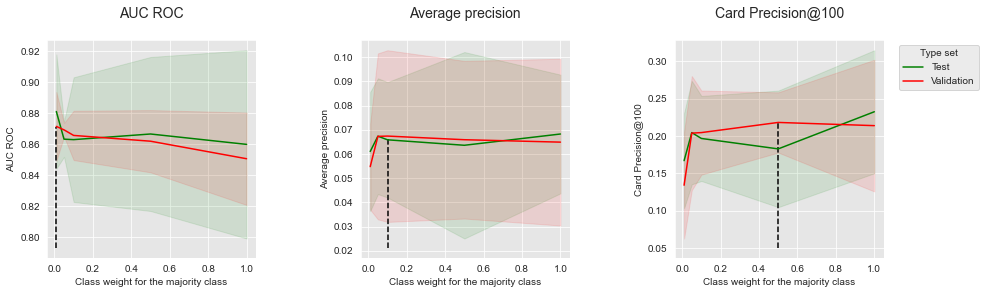

In [3]:
performances_df_dt=performances_df_dictionary['Decision Tree']
summary_performances_dt=get_summary_performances(performances_df_dt, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_dt, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Class weight for the majority class",
                       summary_performances=summary_performances_dt)

We recall that a class weight of 1 consists in giving the same weight to positive and negative classes, whereas a class weight of 0.01 consists in giving 100 times more weight to the positive class (thus favoring the detection of fraud instances). We also note that a class weight of 1 provides the same results as in [Chapter 5](Model_Selection_Decision_Tree). 

The results show that decreasing the class weight allows to increase the performances in terms of AUC ROC, but decreases the performances in terms of Average Precision and CP@100, particularly for very low values (close to 0.01).

The performances as a function of the best parameters are summarized below.

In [4]:
summary_performances_dt

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,0.01,0.1,0.5
Validation performance,0.871+/-0.01,0.067+/-0.02,0.218+/-0.02
Test performance,0.881+/-0.02,0.066+/-0.01,0.183+/-0.04
Optimal parameter(s),0.01,1.0,1.0
Optimal test performance,0.881+/-0.02,0.068+/-0.01,0.232+/-0.04


These results follow the same trends as those obtained with the [simulated data](Cost_Sensitive_Learning_Transaction_Data): Cost-sensitive learning is effective for improving AUC ROC performances, but detrimental to Average Precision. 

### Logistic regression

The results for logistic regression are reported below. The regularization parameter C was set to 0.1 (providing the best performances as was reported in [Chapter 5](Model_Selection_RWD_Logistic_Regression)). 

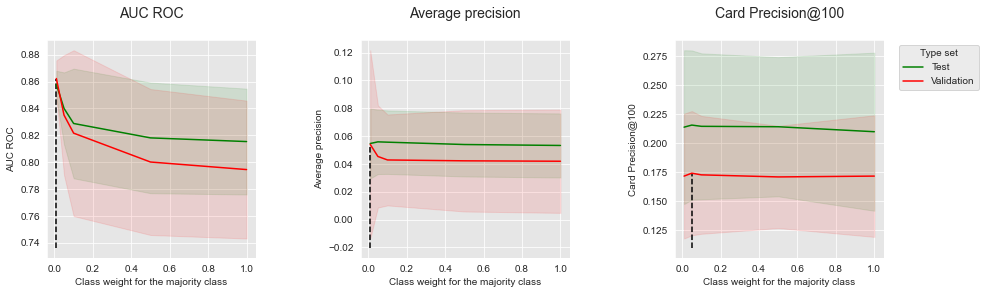

In [5]:
performances_df_lr=performances_df_dictionary['Logistic Regression']
summary_performances_lr=get_summary_performances(performances_df_lr, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_lr, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Class weight for the majority class",
                       summary_performances=summary_performances_lr)

In [6]:
summary_performances_lr

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,0.01,0.01,0.05
Validation performance,0.862+/-0.01,0.054+/-0.03,0.174+/-0.03
Test performance,0.858+/-0.01,0.055+/-0.01,0.216+/-0.03
Optimal parameter(s),0.01,0.05,0.05
Optimal test performance,0.858+/-0.01,0.056+/-0.01,0.216+/-0.03


Similar to decision trees, lowering the class weight of the majority class provides a boost of performances in terms of AUC ROC. The impact on Average Precision and CP@100 is however mitigated: the only noticeable impact is an improvement of the Average Precision on validation data, which however comes at the cost of a higher variance (as is visible from the large confidence interval).

## Resampling

We followed the methodology reported in Section 6.3 ([](Resampling_Strategies_Transaction_Data)), saving the results in the `performances_resampling_real_world_data.pkl` pickle file. The performances and execution times can be retrieved by loading the file. Performances were assessed for SMOTE, RUS, and a combined resampling with SMOTE and RUS. All the experiments relied on decision tree models, whose tree depth was set to 6 (providing the best performances as was reported in [Chapter 5](Model_Selection_RWD_Decision_Trees)). 


In [7]:
filehandler = open('images/performances_resampling_real_world_data.pkl', 'rb') 
(performances_df_dictionary, execution_times) = pickle.load(filehandler)

### SMOTE

The results for SMOTE are reported below. The imbalance ratio was varied in the range 0.01 to 1, with the following set of possible values: $[0.01, 0.05, 0.1, 0.5, 1]$. We recall that the higher the imbalance ratio, the stronger the resampling. An imbalance ratio of 0.01 yields a distribution close to the original one (where the percentage of frauds is close to 0.25%). An imbalance ratio of 1 yields a distribution that contains as many positive instances as negative instances.  


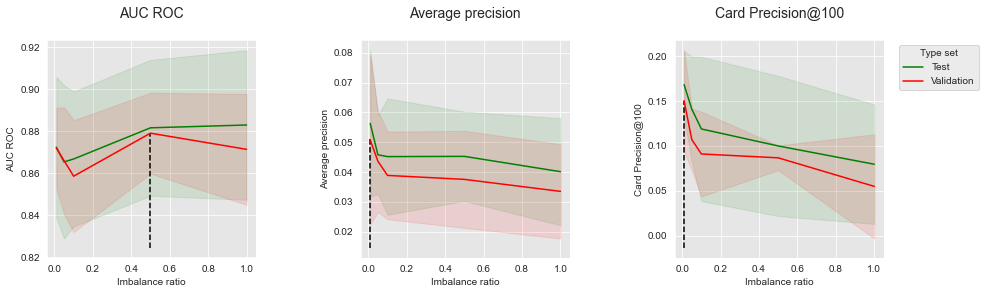

In [8]:
performances_df_SMOTE=performances_df_dictionary['SMOTE']
summary_performances_SMOTE=get_summary_performances(performances_df_SMOTE, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_SMOTE, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Imbalance ratio",
                       summary_performances=summary_performances_SMOTE)

In [9]:
summary_performances_SMOTE

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,0.5,0.01,0.01
Validation performance,0.879+/-0.01,0.051+/-0.01,0.15+/-0.03
Test performance,0.882+/-0.02,0.056+/-0.01,0.168+/-0.02
Optimal parameter(s),1.0,0.01,0.01
Optimal test performance,0.883+/-0.02,0.056+/-0.01,0.168+/-0.02


The results show that the benefits of SMOTE are mitigated. Creating new synthetic instances of the positive class tends to increase AUC ROC performances (left plot). It however comes with a decrease of performances for both Average Precision and CP@100 metrics. These results are in line with those observed on simulated data (Section 6.3, [](Resampling_Strategies_Transaction_Data_Oversampling)).

### Random undersampling

The results for random undersampling (RUS) are reported below. 

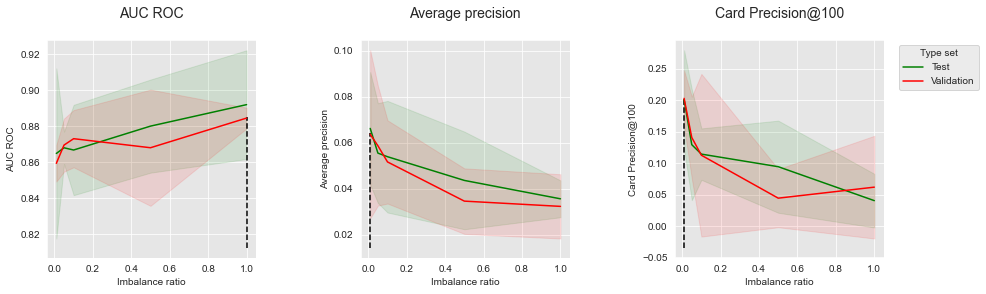

In [10]:
performances_df_RUS=performances_df_dictionary['RUS']
summary_performances_RUS=get_summary_performances(performances_df_RUS, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_RUS, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Imbalance ratio",
                       summary_performances=summary_performances_RUS)

In [11]:
summary_performances_RUS

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,1.0,0.01,0.01
Validation performance,0.885+/-0.0,0.064+/-0.02,0.203+/-0.02
Test performance,0.892+/-0.02,0.066+/-0.01,0.201+/-0.04
Optimal parameter(s),1.0,0.01,0.01
Optimal test performance,0.892+/-0.02,0.066+/-0.01,0.201+/-0.04


Similarly, RUS allows to improve performances in terms of AUC ROC, but comes with a noticeable decrease of performances in terms of AP and CP@100. These results are also in line with those observed on simulated data (Section 6.3, [](Resampling_Strategies_Transaction_Data_RUS)).

### Combining SMOTE with undersampling

We finally report the results for combined resampling (SMOTE followed by RUS). 

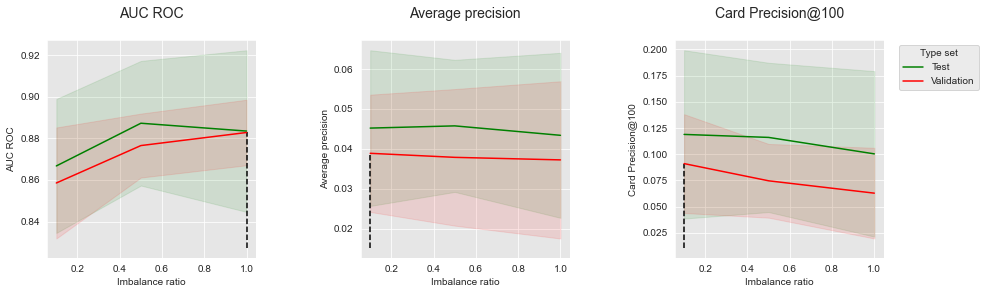

In [12]:
performances_df_combined=performances_df_dictionary['Combined']
summary_performances_combined=get_summary_performances(performances_df_combined, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_combined, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Imbalance ratio",
                       summary_performances=summary_performances_combined)

In [13]:
summary_performances_combined

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,1.0,0.1,0.1
Validation performance,0.883+/-0.01,0.039+/-0.01,0.091+/-0.02
Test performance,0.883+/-0.02,0.045+/-0.01,0.119+/-0.04
Optimal parameter(s),0.5,0.5,0.1
Optimal test performance,0.887+/-0.01,0.046+/-0.01,0.119+/-0.04


Again, we observe that resampling allows to improve performances in terms of AUC ROC, but decreases performances in terms of AP and CP@100. The results are in line with those observed on simulated data (Section 6.3, [](Resampling_Strategies_Transaction_Data_Combining)).

## Ensembling

We followed the methodology reported in Section 6.4 ([](Ensembling_Strategies_Transaction_Data)), saving the results in a `performances_resampling_real_world_data.pkl` pickle file. The performances and execution times can be retrieved by loading the pickle file.


In [14]:
filehandler = open('images/performances_ensembles_real_world_data.pkl', 'rb') 
(performances_df_dictionary, execution_times) = pickle.load(filehandler)

Performances were assessed for balanced bagging, balanced random forest, and weighted XGBoost.

### Baseline

For the [baseline](Ensembling_Strategies_Transaction_Data_Baseline), the hyperparameters were chosen as follows:

* Bagging and random forest: 100 trees, with a maximum depth of 10. These were shown to provide the best performances for random forests in [Chapter 5, Model Selection - Random forest](Model_Selection_RWD_RF).
* XGBoost: 100 trees, with a maximum depth of 6, and a learning rate of 0.1. These were shown to provide the best trade-off in terms of performances in [Chapter 5, Model Selection - XGBoost](Model_Selection_RWD_XGBoost). 

The baseline performances are reported in the table below. It is worth noting that the performances for random forest and XGBoost are the same as those reported in [Chapter 5, Model Selection - Random forest](Model_Selection_RWD_RF) and [Chapter 5, Model Selection - XGBoost](Model_Selection_RWD_XGBoost), respectively.


In [15]:
performances_df_baseline_bagging=performances_df_dictionary['Baseline Bagging']
summary_performances_baseline_bagging=get_summary_performances(performances_df_baseline_bagging, parameter_column_name="Parameters summary")

performances_df_baseline_rf=performances_df_dictionary['Baseline RF']
summary_performances_baseline_rf=get_summary_performances(performances_df_baseline_rf, parameter_column_name="Parameters summary")

performances_df_baseline_xgboost=performances_df_dictionary['Baseline XGBoost']
summary_performances_baseline_xgboost=get_summary_performances(performances_df_baseline_xgboost, parameter_column_name="Parameters summary")

summary_test_performances = pd.concat([summary_performances_baseline_bagging.iloc[2,:],
                                       summary_performances_baseline_rf.iloc[2,:],
                                       summary_performances_baseline_xgboost.iloc[2,:],
                                      ],axis=1)
summary_test_performances.columns=['Baseline Bagging', 'Baseline RF', 'Baseline XGBoost']


In [16]:
summary_test_performances

,Baseline Bagging,Baseline RF,Baseline XGBoost
AUC ROC,0.912+/-0.02,0.912+/-0.02,0.928+/-0.01
Average precision,0.072+/-0.03,0.08+/-0.03,0.095+/-0.03
Card Precision@100,0.209+/-0.07,0.227+/-0.05,0.235+/-0.07


XGBoost was observed to provide better performances than random forest across all performance metrics, as was already reported in [](Model_Selection_RWD_Comparison). The performances of bagging were on par with random forest in terms of AUC ROC, but lower in terms of Average Precision and CP@100. 

### Balanced bagging

Similar to [](Ensembling_Strategies_Transaction_Data_Bagging) with simulated data, the imbalance ratio (`sampling_strategy` parameter) was parametrized to take values in the set $[0.01, 0.05, 0.1, 0.5, 1]$ for the model selection procedure. The number of trees and maximum tree depth were set to 100 and 10 (as with baseline bagging).

In [17]:
performances_df_balanced_bagging=performances_df_dictionary['Balanced Bagging']
performances_df_balanced_bagging

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.917228,0.017889,0.086163,0.022412,0.247857,0.041656,{'clf__base_estimator': DecisionTreeClassifier...,260.625890,0.913089,0.006379,0.094850,0.017160,0.258929,0.025140,0.02
1,0.918801,0.015721,0.090421,0.017192,0.247500,0.037422,{'clf__base_estimator': DecisionTreeClassifier...,289.001823,0.914338,0.006752,0.089633,0.017394,0.255000,0.037095,0.05
2,0.919477,0.013627,0.087215,0.016194,0.240000,0.039448,{'clf__base_estimator': DecisionTreeClassifier...,251.555288,0.914954,0.008718,0.085063,0.017055,0.241071,0.034998,0.10
3,0.921931,0.012261,0.076810,0.015141,0.209643,0.035962,{'clf__base_estimator': DecisionTreeClassifier...,238.826444,0.913580,0.012917,0.069417,0.010087,0.195714,0.013209,0.50
4,0.921426,0.013367,0.069408,0.011683,0.189286,0.023332,{'clf__base_estimator': DecisionTreeClassifier...,197.796464,0.914754,0.011732,0.060259,0.008555,0.160357,0.021556,1.00


Let us summarize the performances to highlight the optimal imbalance ratio, and plot the performances as a function of the imbalance ratio for the three performance metrics.

In [18]:
summary_performances_balanced_bagging=get_summary_performances(performances_df_balanced_bagging, parameter_column_name="Parameters summary")
summary_performances_balanced_bagging

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,0.1,0.02,0.02
Validation performance,0.915+/-0.01,0.095+/-0.02,0.259+/-0.03
Test performance,0.919+/-0.01,0.086+/-0.02,0.248+/-0.04
Optimal parameter(s),0.5,0.05,0.02
Optimal test performance,0.922+/-0.01,0.09+/-0.02,0.248+/-0.04


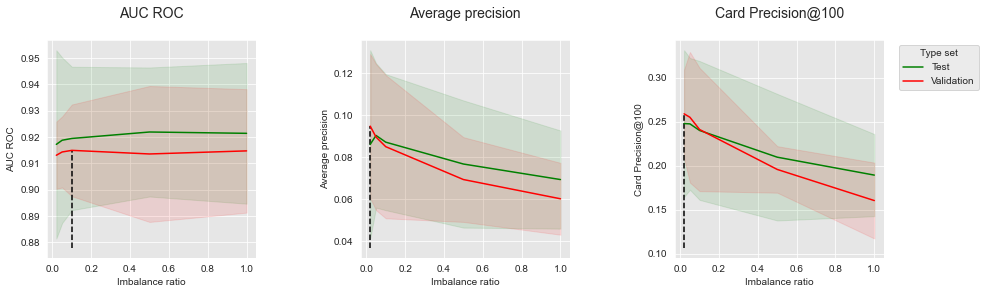

In [19]:
get_performances_plots(performances_df_balanced_bagging, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Imbalance ratio",
                       summary_performances=summary_performances_balanced_bagging)

The results show that increasing the imbalance ratio leads to a decrease of both Average Precision and CP@100. The trend is different with AUC ROC, where increasing the imbalance ratio first leads to a slight improvement of the metric, before reaching a plateau. It is worth noting that the results are qualitatively similar to [](Ensembling_Strategies_Transaction_Data_Bagging) with simulated data for AUC ROC and Average Precision. 

### Balanced random forest

Similar to [](Ensembling_Strategies_Transaction_Data_RF) with simulated data, the imbalance ratio (`sampling_strategy` parameter) was parametrized to take values in the set $[0.01, 0.05, 0.1, 0.5, 1]$ for the model selection procedure. The number of trees and maximum tree depth were set to 100 and 10 (as with baseline random forest).

In [20]:
performances_df_balanced_rf=performances_df_dictionary['Balanced RF']
performances_df_balanced_rf

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.918636,0.020386,0.093255,0.018644,0.253929,0.026733,"{'clf__max_depth': 10, 'clf__n_estimators': 10...",138.678571,0.918772,0.005630,0.099003,0.021238,0.263571,0.031274,0.01
1,0.922445,0.018733,0.092084,0.017847,0.245000,0.025425,"{'clf__max_depth': 10, 'clf__n_estimators': 10...",140.741641,0.920488,0.005681,0.094071,0.018980,0.255000,0.033480,0.05
2,0.925383,0.015810,0.088692,0.017844,0.238929,0.027244,"{'clf__max_depth': 10, 'clf__n_estimators': 10...",130.145606,0.921882,0.004630,0.091078,0.019971,0.247500,0.037490,0.10
3,0.926452,0.013919,0.075340,0.013228,0.200714,0.032490,"{'clf__max_depth': 10, 'clf__n_estimators': 10...",125.557530,0.921611,0.007349,0.074475,0.016815,0.202857,0.034949,0.50
4,0.924311,0.013693,0.069106,0.011243,0.176786,0.015498,"{'clf__max_depth': 10, 'clf__n_estimators': 10...",115.135572,0.919174,0.008283,0.066712,0.015405,0.180714,0.037109,1.00


Let us summarize the performances to highlight the optimal imbalance ratio, and plot the performances as a function of the imbalance ratio for the three performance metrics.

In [21]:
summary_performances_balanced_rf=get_summary_performances(performances_df_balanced_rf, parameter_column_name="Parameters summary")
summary_performances_balanced_rf


,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,0.1,0.01,0.01
Validation performance,0.922+/-0.0,0.099+/-0.02,0.264+/-0.03
Test performance,0.925+/-0.02,0.093+/-0.02,0.254+/-0.03
Optimal parameter(s),0.5,0.01,0.01
Optimal test performance,0.926+/-0.01,0.093+/-0.02,0.254+/-0.03


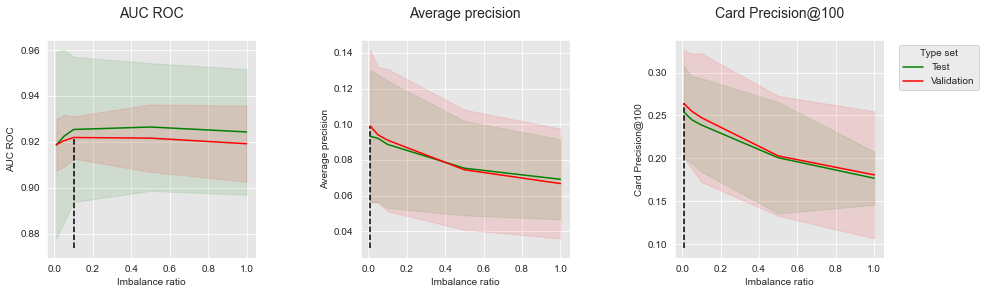

In [22]:
get_performances_plots(performances_df_balanced_rf, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Imbalance ratio",
                       summary_performances=summary_performances_balanced_rf)

The results follow the same trends as with balanced bagging: increasing the imbalance ratio is detrimental to Average Precision and CP@100, but can slightly increase AUC ROC. The results are qualitatively similar to [](Ensembling_Strategies_Transaction_Data_RF) with simulated data for AUC ROC and Average Precision.

### Weighted XGBoost

Finally, similar to [](Ensembling_Strategies_Transaction_Data_Weighted_XGBoost) with simulated data, we varied the `scale_pos_weight` parameter to take values in the set $[1,5,10,50,100]$. The same hyperparameters as the baseline XGBoost were otherwise kept (100 trees with a maximum depth of 6, and a learning rate of 0.1).


In [23]:
performances_df_weighted_xgboost=performances_df_dictionary['Weighted XGBoost']
performances_df_weighted_xgboost


,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.928408,0.014108,0.094781,0.030425,0.235357,0.068111,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",518.837213,0.924261,0.011350,0.102488,0.019552,0.260714,0.023765,1
1,0.927328,0.013481,0.096711,0.025309,0.248929,0.056887,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",626.773925,0.920673,0.016914,0.106036,0.021723,0.268571,0.021213,5
2,0.926817,0.013696,0.093330,0.026236,0.231071,0.057821,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",639.092060,0.920256,0.015958,0.098559,0.019405,0.262143,0.021888,10
3,0.925220,0.012177,0.095823,0.024201,0.240000,0.041367,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",627.310905,0.912374,0.027515,0.093519,0.014645,0.244643,0.032739,50
4,0.924530,0.012777,0.089102,0.030194,0.237857,0.043910,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",480.403027,0.912332,0.023152,0.086822,0.013398,0.238929,0.039453,100


Let us summarize the performances to highlight the optimal imbalance ratio, and plot the performances as a function of the class weight for the three performance metrics.

In [24]:
summary_performances_weighted_xgboost=get_summary_performances(performances_df_weighted_xgboost, parameter_column_name="Parameters summary")
summary_performances_weighted_xgboost


,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,1,5,5
Validation performance,0.924+/-0.01,0.106+/-0.02,0.269+/-0.02
Test performance,0.928+/-0.01,0.097+/-0.03,0.249+/-0.06
Optimal parameter(s),1,5,5
Optimal test performance,0.928+/-0.01,0.097+/-0.03,0.249+/-0.06


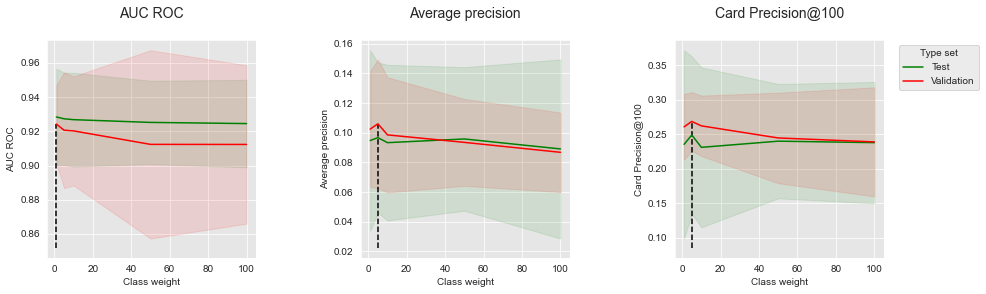

In [25]:
get_performances_plots(performances_df_weighted_xgboost, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Class weight",
                       summary_performances=summary_performances_weighted_xgboost)

Contrary to balanced bagging and balanced random forest, increasing the class weight of the minority class allows to slightly improve the performances in terms of Average Precision and CP@100. Improvements are only observed for a slight increase of the class weight (from 1 to 5). Higher values lead to slight decreases of performances. For AUC ROC, the optimal class weight is found to be 1 (equal cost for the minority and majority classes). 

### Summary

Let us finally summarize in a single table the results on the real-world dataset. Performance metrics are reported row-wise, while ensemble methods are reported column-wise. 

In [26]:
summary_test_performances = pd.concat([summary_performances_baseline_bagging.iloc[2,:],
                                       summary_performances_balanced_bagging.iloc[2,:],
                                       summary_performances_baseline_rf.iloc[2,:],
                                       summary_performances_balanced_rf.iloc[2,:],
                                       summary_performances_baseline_xgboost.iloc[2,:],
                                       summary_performances_weighted_xgboost.iloc[2,:],
                                      ],axis=1)
summary_test_performances.columns=['Baseline Bagging', 'Balanced Bagging', 
                                   'Baseline RF', 'Balanced RF', 
                                   'Baseline XGBoost', 'Weighted XGBoost']


In [27]:
summary_test_performances

,Baseline Bagging,Balanced Bagging,Baseline RF,Balanced RF,Baseline XGBoost,Weighted XGBoost
AUC ROC,0.912+/-0.02,0.919+/-0.01,0.912+/-0.02,0.925+/-0.02,0.928+/-0.01,0.928+/-0.01
Average precision,0.072+/-0.03,0.086+/-0.02,0.08+/-0.03,0.093+/-0.02,0.095+/-0.03,0.097+/-0.03
Card Precision@100,0.209+/-0.07,0.248+/-0.04,0.227+/-0.05,0.254+/-0.03,0.235+/-0.07,0.249+/-0.06


The best improvements were observed for balanced bagging and balanced random forest, for which better performances were obtained compared to baseline bagging and baseline random forest. However, as we noted for the [simulated data](Ensembling_Strategies_Transaction_Data), the benefits of resampling are most likely due to a higher diversity of the trees making up the ensembles, leading to a decrease of the overfitting phenomenon. In particular, the optimum imbalance ratio for Average Precision and CP@100 was found to be the lowest one (0.01), which shows that the best strategy for these metrics was to avoid rebalancing the training sets.

On the contrary, we observed that rebalancing the training sets could slightly improve the performances in terms of AUC ROC. The improvements were observed for imbalance ratios ranging from 0.1 to 0.5, leading to a slight increase of around 1% of the AUC ROC (from 0.91 to 0.92). Besides allowing a slight increase in performances, it is worth noting that rebalancing the dataset with undersampling techniques could speed up computation times by up to 20%.

As for the results obtained on [simulated data](Ensembling_Strategies_Transaction_Data_Summary), these experiments suggest that rebalancing can help improve performances in terms of AUC ROC or speed up the training time of an ensemble. It however appeared that keeping all of the training data was the best strategy if Average Precision and CP@100 are the performance metrics to optimize.

Overall, the best performances were obtained with XGBoost for the three metrics. As for the [simulated data](Ensembling_Strategies_Transaction_Data_Summary), modifying the class weight through weighted XGBoost did not allow to significantly improve performances, illustrating the robustness of XGBoost in class imbalance scenarios.